# COMPX593 Thesis Plot Notebook
This notebook is used to plot figures for COMPX593 Thesis - Fine-Tunning Oxford Nanopore Basecalling Model to Enable High-Fidelity Single-Read Variant Calling in Antibody Libraries

- Heavy BAM-backed analyses are cached under `src/ipynb/plot/cache/` so repeat notebook runs stay practical.
- Panels exports are written to `src/ipynb/plot/panels/` in SVG format for downstream editing.
- Thesis summary tables are read from and exported to `tables/`.


# Library Imports & Configuration

In [1]:
from __future__ import annotations
from collections import defaultdict
import sys
import gzip
import math
import re
import subprocess
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter

# Global style configuration
def configure_matplotlib() -> None:
    """matching matplotlib as in PlotSignal.py"""
    plt.rcParams.update(
        {
            "font.family": "DejaVu Serif",
            "font.size": 10,
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "axes.labelweight": "normal",
            "axes.titleweight": "normal",
            "axes.linewidth": 0.8,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "xtick.direction": "out",
            "ytick.direction": "out",
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "xtick.minor.width": 0.6,
            "ytick.minor.width": 0.6,
            "xtick.major.size": 4,
            "ytick.major.size": 4,
            "xtick.minor.size": 2.5,
            "ytick.minor.size": 2.5,
            "figure.facecolor": "white",
            "figure.dpi": 120,
            "axes.facecolor": "white",
            "axes.edgecolor": "#222222",
            "axes.grid": False,
            "grid.color": "#d9d9d9",
            "grid.linewidth": 0.6,
            "grid.alpha": 0.7,
            "legend.fontsize": 10,
            "savefig.facecolor": "white",
            "savefig.edgecolor": "white",
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.03,
            "pdf.fonttype": 42,
            "ps.fonttype": 42,
            "svg.fonttype": "none",
        }
    )


configure_matplotlib()

# Resolve the repository layout from the current working directory so the notebook
# can run from either the repo root or the src/ipynb notebook directory.
def resolve_repo_root(start: Path | None = None) -> Path:
    search_start = (start or Path.cwd()).resolve()
    for candidate in (search_start, *search_start.parents):
        if (candidate / "tables" / "model.csv").exists() and (candidate / "src" / "ipynb" / "plot.ipynb").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not locate the COMPX593-Thesis repository root from {search_start}. "
        "Expected to find tables/model.csv and src/ipynb/plot.ipynb."
    )


REPO_ROOT = resolve_repo_root()
ROOT = REPO_ROOT / "src" / "ipynb" / "plot"
TABLES_DIR = REPO_ROOT / "tables"
FIGURES_DIR = REPO_ROOT / "figures"
REFERENCE_DIR = REPO_ROOT / "reference"
DATA_DIR = ROOT / "data"
TEST_DIR = ROOT / "test"
CACHE_DIR = ROOT / "cache"
PANELS_DIR = FIGURES_DIR
REFERENCE_FASTA = REFERENCE_DIR / "fc_reference.fa"
DMS_ZONE_FILE = REFERENCE_DIR / "DMSZones.txt"
SEEDED_TABLES_DIR = TABLES_DIR / "seeded"
SEEDED_RUN_ROOT_CANDIDATES = [
    REPO_ROOT / "seeded_bonito_v1",
    REPO_ROOT.parent / "ont" / "seeded_bonito_v1",
    Path("/mnt/experimental/ont/seeded_bonito_v1"),
]

# Create cache, panel, and table directories if they do not already exist.
TABLES_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
PANELS_DIR.mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "fastq_samples").mkdir(parents=True, exist_ok=True)
(CACHE_DIR / "mutation_density").mkdir(parents=True, exist_ok=True)

# Create a fixed display order for all models/data in test.csv
DISPLAY_ORDER = [
    "Alpha",
    "AlphaQCH",
    "AlphaQCL",
    "Gamma",
    "GammaQCH",
    "GammaQCL",
    "Beta",
    "BetaQCH",
    "BetaQCL",
    "sup",
    "UDP0057",
]

# Create a fixed display order for only model in test.csv
MODEL_ONLY_ORDER = [name for name in DISPLAY_ORDER if name != "UDP0057"]

# Create a fixed display order for datasets in data.csv
DATASET_ORDER = [
    "A_full",
    "A_filtered",
    "AB_full",
    "AB_filtered",
    "B_full",
    "B_filtered",
    "2025_07_31",
    "UDP0057",
]

# Reuse the same subset for the dataset retention and mean-Q panels.
READ_RETENTION_DATASETS = ["A_full", "B_full", "AB_full", "2025_07_31", "UDP0057"]

# Create a fixed display order for dataset searching
DISPLAY_TO_RAW = {name: name for name in MODEL_ONLY_ORDER}
DISPLAY_TO_RAW["UDP0057"] = "UDP0057.fq"

# Create a sort order for sorting by name later (sort by custome order)
SORT_ORDER = {name: idx for idx, name in enumerate(DISPLAY_ORDER + DATASET_ORDER)}

# Pick only 1 color for each family (e.g., model and dataset)
FAMILY_COLORS = {
    "Alpha": "#1b9e77",
    "Gamma": "#d95f02",
    "Beta": "#4c78a8",
    "sup": "#7f7f7f",
    "UDP0057": "#111111",
    "A_full": "#4c78a8",
    "A_filtered": "#4c78a8",
    "AB_full": "#1b9e77",
    "AB_filtered": "#1b9e77",
    "B_full": "#d95f02",
    "B_filtered": "#d95f02",
    "2025_07_31": "#8c564b",
}

# For all scatter plot use a fix set of marker for consistancy
VARIANT_MARKERS = {
    # Alpha, Beta, Gamma
    "base": "o",
    # AlphaQCH, BetaQCH, GammaQCH
    "QCH": "s",
    # AlphaQCL, BetaQCL, GammaQCL
    "QCL": "D",
    # sup
    "sup": "X",
    # UDP0057
    "reference": "P",
}

# Define fixed region colour for DMS and Framework.
REGION_COLORS = {"DMS": "#c44e52", "Framework": "#4c72b0"}

# Configure table 
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:0.4f}")


# Utilities

In [2]:
def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        if out[col].dtype != object:
            continue
        try:
            out[col] = pd.to_numeric(out[col])
        except (TypeError, ValueError):
            pass
    return out

model_raw = coerce_numeric(pd.read_csv(TABLES_DIR / "model.csv"))
MODEL_FAMILY_LOOKUP = model_raw.set_index("name")["family"].to_dict()
MODEL_VARIANT_LOOKUP = model_raw.set_index("name")["variant"].to_dict()

# Remove file suffix from filenames
def normalize_display_name(name: str) -> str:
    stem = str(name)
    for suffix in (".fastq.gz", ".fq.gz", ".fastq", ".fq", ".pod5", ".bam", ".tsv"):
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
            break
    return stem

# this function standardise dataframes (data.csv, test.csv, model.csv, correlation.csv) with the same metadata columns, so the rest of the notebook can ssume these fields exist
# display_name (a clean label like UDP0057 without file extension)
# family (grouping for color, like Alpha, Beta, Gamma, sup)
# variant (grouping for marker shape, like base, QCH, QCL, sup, reference)
# sort_order (stable ordering for plots and tables)
def add_display_metadata(df: pd.DataFrame) -> pd.DataFrame:
    # make a deep of the data frame
    out = df.copy()
    # normalise the display name (trim of any file extension)
    out["display_name"] = out["name"].map(normalize_display_name)
    # if dataframe doesn't have family column, use MODEL_FAMILY_LOOKUP dictionary to append family column
    if "family" not in out.columns:
        out["family"] = out["name"].map(MODEL_FAMILY_LOOKUP)
    out["family"] = out["family"].fillna(out["display_name"])
    # special-case sup and UDP0057
    out.loc[out["display_name"] == "sup", "family"] = "sup"
    out.loc[out["display_name"] == "UDP0057", "family"] = "UDP0057"
    # if dataframe doesn't have variant column, use MODEL_VARIANT_LOOKUP dictionary to append variant column
    if "variant" not in out.columns:
        out["variant"] = out["name"].map(MODEL_VARIANT_LOOKUP)
    out["variant"] = out["variant"].fillna("base")
    # special-case sup and UDP0057
    out.loc[out["display_name"] == "sup", "variant"] = "sup"
    out.loc[out["display_name"] == "UDP0057", "variant"] = "reference"
    # compute sort_order column from predefined plotting order list
    out["sort_order"] = out["display_name"].map(SORT_ORDER).fillna(999).astype(int)
    # returns the dataframe sorted and reindexed
    return out.sort_values(["sort_order", "display_name"]).reset_index(drop=True)


SEEDED_NAME_PATTERN = re.compile(r"^(?P<base_model>.+)_s(?P<seed_index>\d{2})$")


def parse_seeded_name(name: str) -> dict[str, object]:
    stem = normalize_display_name(name)
    match = SEEDED_NAME_PATTERN.match(stem)
    if not match:
        return {"display_name": stem, "seed_index": np.nan, "seed_label": "baseline"}
    seed_index = int(match.group("seed_index"))
    return {
        "display_name": match.group("base_model"),
        "seed_index": seed_index,
        "seed_label": f"s{seed_index:02d}",
    }


def annotate_seed_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    parsed = out["name"].map(parse_seeded_name).apply(pd.Series)
    for column in ["display_name", "seed_index", "seed_label"]:
        out[column] = parsed[column]
    out["family"] = out["display_name"].map(MODEL_FAMILY_LOOKUP).fillna(out["display_name"])
    out["variant"] = out["display_name"].map(MODEL_VARIANT_LOOKUP).fillna("base")
    out.loc[out["display_name"] == "sup", "family"] = "sup"
    out.loc[out["display_name"] == "sup", "variant"] = "sup"
    out.loc[out["display_name"] == "UDP0057", "family"] = "UDP0057"
    out.loc[out["display_name"] == "UDP0057", "variant"] = "reference"
    out["sort_order"] = out["display_name"].map(SORT_ORDER).fillna(999).astype(int)
    return out


def load_reference_sequence(reference_path: Path = REFERENCE_FASTA) -> str:
    parts = []
    with reference_path.open() as handle:
        for line in handle:
            if line.startswith(">"):
                continue
            parts.append(line.strip())
    return "".join(parts)


def parse_dms_zones(zone_path: Path = DMS_ZONE_FILE) -> list[tuple[int, int]]:
    raw = zone_path.read_text().strip()
    zones = []
    for chunk in raw.split(","):
        start, end = chunk.split("-")
        zones.append((int(start), int(end)))
    return zones


REFERENCE_SEQUENCE = load_reference_sequence()
REFERENCE_LENGTH = len(REFERENCE_SEQUENCE)
DMS_ZONES = parse_dms_zones()
# Create a list represent joined DMS segments
JOINED_DMS_SEGMENTS = []
joined_dms_offset = 0
for start, end in DMS_ZONES:
    segment_length = end - start + 1
    JOINED_DMS_SEGMENTS.append(
        {
            "start": start,
            "end": end,
            "joined_start": joined_dms_offset + 1,
            "joined_end": joined_dms_offset + segment_length,
            "joined_mid": joined_dms_offset + (segment_length + 1) / 2.0,
        }
    )
    joined_dms_offset += segment_length
JOINED_DMS_LENGTH = joined_dms_offset

# determine whether a nucleotide position is within the DMS zone or not.
def position_region(position_1based: int) -> str:
    for start, end in DMS_ZONES:
        if start <= position_1based <= end:
            return "DMS"
    return "Framework"


def joined_dms_position(position_1based: int) -> float:
    for segment in JOINED_DMS_SEGMENTS:
        if segment["start"] <= position_1based <= segment["end"]:
            # convert the global base position to local base position in relation to joined DMS regions
            return float(segment["joined_start"] + (position_1based - segment["start"]))
    return np.nan

# iterates through all subdirectories in TEST_DIR
# filters to only directories that contan an underscore in their name
# for each matching directory, splits the name on the first underscore and use the second part as the key
TEST_ARTIFACTS = {
    path.name.split("_", 1)[1]: path
    for path in TEST_DIR.iterdir()
    if path.is_dir() and "_" in path.name
}

# iterate through all subdirectories in DATA_DIR
# simply use the directory name as both key and value.
DATA_ARTIFACTS = {path.name: path for path in DATA_DIR.iterdir() if path.is_dir()}

# resolve test directory for a internal display name
def resolve_test_dir(name: str) -> Path:
    raw_name = DISPLAY_TO_RAW.get(name, name)
    # return the correct directory for the given display name
    return TEST_ARTIFACTS[raw_name]

# resolve the bam file as either primary aligned or polished aligned
def resolve_bam_path(name: str, stage: str = "primary") -> Path:
    model_dir = resolve_test_dir(name)
    if stage == "primary":
        suffix = "*.aligned.bam"
    elif stage == "polished":
        suffix = "*.polished.sorted.bam"
    else:
        raise ValueError(f"Unsupported stage: {stage}")
    matches = sorted(model_dir.glob(suffix))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one {suffix} in {model_dir}, found {len(matches)}")
    # return the exact .bam file located
    return matches[0]

# find the return that path to corresponding variant key file for any given dataset/model
def resolve_variant_path(name: str) -> Path:
    model_dir = resolve_test_dir(name)
    matches = sorted(model_dir.glob("*.variants.tsv"))
    if len(matches) != 1:
        raise FileNotFoundError(f"Expected exactly one *.variants.tsv in {model_dir}, found {len(matches)}")
    return matches[0]

# define a function to return family color with a default alternative
def family_color(name_or_family: str) -> str:
    return FAMILY_COLORS.get(name_or_family, "#444444")


# use a lighter shade of the family colour for primary/baseline traces
def lighten_color(color: str, amount: float = 0.55) -> tuple[float, float, float]:
    base = np.asarray(mpl.colors.to_rgb(color))
    return tuple(base + (1.0 - base) * amount)

# shading the DMS regions with saved color
def add_dms_shading(ax: plt.Axes, *, alpha: float = 0.10) -> None:
    for start, end in DMS_ZONES:
        ax.axvspan(start, end, color=REGION_COLORS["DMS"], alpha=alpha, lw=0)

# this function calculates the maximumm size of nodes to accomodate both incoming and outgoing follows from that nodes
def _sankey_node_group_values(
    links: list[dict[str, object]],
    group_order: list[str],
) -> dict[str, dict[str, float]]:
    # total value flowing into a node from a specific dataset/group
    incoming: dict[str, dict[str, float]] = defaultdict(lambda: defaultdict(float))
    # total value flowing out of a node to a specific group
    outgoing: dict[str, dict[str, float]] = defaultdict(lambda: defaultdict(float))
    # process each link
    for link in links:
        # the source filter/node
        source = str(link["source"])
        # the target filter/node
        target = str(link["target"])
        # the dataset/group
        group = str(link["group"])
        # the number of reads flowing
        value = float(link["value"])
        # add to the source node outgoing dataset/group
        outgoing[source][group] += value
        # add to the target node incoming dataset/group
        incoming[target][group] += value

    node_values: dict[str, dict[str, float]] = {}
    # for each node (any node that appears as either source or target)
    for node in set(incoming) | set(outgoing):
        node_values[node] = {}
        # for each group in specific order
        for group in group_order:
            # take the maximum of incoming vs outgoing value for that group
            # this ensures the node segment is large enough to accommodate both incoming and outgoing flows
            node_values[node][group] = max(incoming[node][group], outgoing[node][group])
    return node_values



def _sankey_scale(
    columns: list[list[str]],
    node_group_values: dict[str, dict[str, float]],
    *,
    usable_height: float = 0.82,
    node_gap: float = 0.035,
) -> float:
    scales = []
    for column_nodes in columns:
        # calculating the height of the column to accomodate required nodes
        column_total = sum(sum(node_group_values[node].values()) for node in column_nodes)
        # calculating number of gaps required for the column
        gap_total = node_gap * max(0, len(column_nodes) - 1)
        # calculating vailable space then scale to make this column fit perfectly
        scales.append((usable_height - gap_total) / column_total)
    # return the most restrictive scale
    # the most constrained column (one with the largest total value) determines the overall scale
    return min(scales)



def _sankey_layouts(
    column_x: list[float],
    columns: list[list[str]],
    node_group_values: dict[str, dict[str, float]],
    group_order: list[str],
    *,
    scale: float,
    node_gap: float = 0.035,
) -> dict[str, dict[str, object]]:
    layouts: dict[str, dict[str, object]] = {}
    for x, column_nodes in zip(column_x, columns):
        # calculate the total height of that node with scale factor
        total_height = sum(sum(node_group_values[node].values()) * scale for node in column_nodes)
        # include the gap height too for each column
        total_height += node_gap * max(0, len(column_nodes) - 1)
        # center the column vertically
        y_cursor = 0.5 + total_height / 2.0
        # for each individual node in a column
        for node in column_nodes:
            # compute the individual node height with scale factor
            node_height = sum(node_group_values[node].values()) * scale
            # place the node at current cursor position
            y_top = y_cursor
            # updates cursor downward for next node
            y_bottom = y_top - node_height
            # create a segment cursor for each dataset/group/flow
            seg_cursor = y_top
            segments: dict[str, tuple[float, float]] = {}
            # within each node, stacks colored segments from top to bottom
            # following the group_order specified
            for group in group_order:
                # each segment's height is proportional to its value
                seg_height = node_group_values[node].get(group, 0.0) * scale
                # anchor the segment
                seg_top = seg_cursor
                # determine the buttom of the segement
                seg_bottom = seg_top - seg_height
                # add a segment to segments for drawing
                segments[group] = (seg_bottom, seg_top)
                # update the cursor location to the buttom of this segment (prepare to start next segment)
                seg_cursor = seg_bottom
            # save the nodes complete layout infor for drawing later
            layouts[node] = {"x": x, "y0": y_bottom, "y1": y_top, "segments": segments}
            # move the cursor down by node height + gap for next node
            y_cursor = y_bottom - node_gap
    # for the layouts for all columns (i.e., nodes)
    return layouts

# append the correct unit the scale bar depending on the scale bar size
def _format_sankey_read_count(value: float) -> str:
    count = int(round(value))
    if count >= 1_000_000:
        text = f"{count / 1_000_000:.1f}".rstrip("0").rstrip(".") + "M"
    elif count >= 1_000:
        text = f"{count / 1_000:.1f}".rstrip("0").rstrip(".") + "k"
    else:
        text = f"{count:,}"
    return f"{text} reads"

# this function add a scale bar any sankey plot
def _add_sankey_scale_bar(
    ax: plt.Axes,
    *,
    scale: float,
    value: float,
    x: float = 0.96,
    y0: float = 0.03,
    tick_width: float = 0.018,
) -> None:
    height = value * scale;
    y1 = y0 + height
    transform = ax.transAxes
    line_kwargs = {"transform": transform, "clip_on": False, "color": "#4f4f4f", "lw": 1.0, "zorder": 9}
    ax.plot([x, x], [y0, y1], **line_kwargs)
    ax.plot([x - tick_width, x], [y0, y0], **line_kwargs)
    ax.plot([x - tick_width, x], [y1, y1], **line_kwargs)
    ax.text(
        x - tick_width - 0.006,
        (y0 + y1) / 2.0,
        _format_sankey_read_count(value),
        transform=transform,
        ha="right",
        va="center",
        color="#444444",
        fontsize=8,
        clip_on=False,
        zorder=9,
        weight='bold'
    )


# define ribbon function that return a mpl PathPatch for drawing
def _sankey_ribbon_patch(
    x0: float,
    x1: float,
    y0_bottom: float,
    y0_top: float,
    y1_bottom: float,
    y1_top: float,
    *,
    color: str,
    alpha: float,
) -> mpl.patches.PathPatch:
    # distance between columns/filters
    dx = x1 - x0
    # move the control point 38% in the horizontal distance from each edge (smooth, flowing ribbon shape)
    curvature = dx * 0.38
    # allocate some vertices 
    vertices = [
        # top left corner
        (x0, y0_top),
        # curve start
        (x0 + curvature, y0_top),
        # curve end
        (x1 - curvature, y1_top),
        # top right corner
        (x1, y1_top),
        # buttom right corner
        (x1, y1_bottom),
        # curve start
        (x1 - curvature, y1_bottom),
        # curve end
        (x0 + curvature, y0_bottom),
        # buttom left cornor
        (x0, y0_bottom),
        # back to start
        (x0, y0_top),
    ]
    # define path code
    codes = [
        # linear
        mpl.path.Path.MOVETO,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # linear
        mpl.path.Path.LINETO,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # cubic Bezier curve (3 control point, current vertex + 3 more)
        mpl.path.Path.CURVE4,
        # connects back to the start automatically
        mpl.path.Path.CLOSEPOLY,
    ]
    # create and return the patch
    return mpl.patches.PathPatch(
        mpl.path.Path(vertices, codes),
        facecolor=color,
        edgecolor="none",
        alpha=alpha,
    )


# allocate each links to corresponding segment in layouts
def _sankey_allocate_links(
    links: list[dict[str, object]],
    layouts: dict[str, dict[str, object]],
    group_order: list[str],
    *,
    scale: float,
) -> list[dict[str, object]]:
    outgoing: dict[tuple[str, str], list[dict[str, object]]] = defaultdict(list)
    incoming: dict[tuple[str, str], list[dict[str, object]]] = defaultdict(list)
    # we only need to know the source filter, target filter and dataset/group of each link (value is not necessary here, as segment height has been pre-computed)
    for link in links:
        source = str(link["source"])
        target = str(link["target"])
        group = str(link["group"])
        outgoing[(source, group)].append(link)
        incoming[(target, group)].append(link)

    # process outgoing links
    for (source, group), subset in outgoing.items():
        # sort links so those going to targets with higher y1 (top) come first
        subset.sort(key=lambda item: layouts[str(item["target"])]["y1"], reverse=True)
        # retrieves the vertical range of the colored segment for this group in the source node
        seg_bottom, seg_top = layouts[source]["segments"][group]
        # anchor the cursor to the top of this segment
        cursor = seg_top
        # for each link (in sorted order)
        for item in subset:
            # calculate ribbon height proportion to its value
            height = float(item["value"]) * scale
            # determine top of the ribbon (current cursor position)
            item["source_y1"] = cursor
            # determine buttom of the ribbon
            item["source_y0"] = cursor - height
            # update the cursor location
            cursor -= height
        # validate allocation
        # after all ribbons are placed, cursor should equal seg_buttom
        # a tiny tolerance accounts for floating-point rounding.
        if abs(cursor - seg_bottom) > 1e-7:
            raise ValueError(f"Outgoing Sankey allocation mismatch for {source} / {group}")

    # process incoming links
    for (target, group), subset in incoming.items():
        subset.sort(key=lambda item: layouts[str(item["source"])]["y1"], reverse=True)
        seg_bottom, seg_top = layouts[target]["segments"][group]
        cursor = seg_top
        for item in subset:
            height = float(item["value"]) * scale
            item["target_y1"] = cursor
            item["target_y0"] = cursor - height
            cursor -= height
        if abs(cursor - seg_bottom) > 1e-7:
            raise ValueError(f"Incoming Sankey allocation mismatch for {target} / {group}")
    # return the processed links
    return links


# add patches to sankey nodes and segments
def _add_sankey_nodes(
    ax: plt.Axes,
    layouts: dict[str, dict[str, object]],
    node_group_values: dict[str, dict[str, float]],
    group_order: list[str],
    group_colors: dict[str, str],
    *,
    node_width: float = 0.028,
) -> None:
    for node, layout in layouts.items():
        x = float(layout["x"])
        y0 = float(layout["y0"])
        y1 = float(layout["y1"])
        # each node will be draw as white rectangle
        ax.add_patch(
            mpl.patches.Rectangle(
                (x - node_width / 2.0, y0),
                node_width,
                y1 - y0,
                facecolor="white",
                edgecolor="#4f4f4f",
                linewidth=0.8,
                zorder=5,
            )
        )
        # for each segment inside the nodes
        for group in group_order:
            value = node_group_values[node].get(group, 0.0)
            if value <= 0:
                continue
            seg_bottom, seg_top = layout["segments"][group]
            # each segment will be draw using the dataset color
            ax.add_patch(
                mpl.patches.Rectangle(
                    (x - node_width / 2.0, seg_bottom),
                    node_width,
                    seg_top - seg_bottom,
                    facecolor=group_colors[group],
                    edgecolor="white",
                    linewidth=0.35,
                    alpha=0.28,
                    zorder=6,
                )
            )


# Function use to draw a sankey graph
def draw_segmented_sankey(
    # the axes object to plot the sankey graph in
    ax: plt.Axes,
    # everything after this must be passed as keyword argument
    *,
    # a list of note columns
    columns: list[list[str]],
    # the x-position of each column (between 0 and 1)
    column_x: list[float],
    # the flow record between note
    links: list[dict[str, object]],
    # the order in which dataset groups are stacked and drawn
    group_order: list[str],
    # a dictionary mapping each group name to a color
    group_colors: dict[str, str],
    # a dictionary mapping internal nodes name to display labels
    node_labels: dict[str, str],
    # optional manual label placement override
    label_positions: dict[str, dict[str, object]] | None = None,
    # optional preset label placement relative to a node
    label_placements: dict[str, str] | None = None,
    # option width of each sankey node rectange.
    node_width: float = 0.028,
    # gap used when moving labels above or below a node
    label_offset: float = 0.016,
    # optionally add a read-count scale bar on the right side
    show_scale_bar: bool = False,
    # optional fixed read-count for the scale bar
    scale_bar_value: float,
) -> None:
    # calculate accomodating node size for each node
    node_group_values = _sankey_node_group_values(links, group_order)
    # minimum scale across all columns 
    scale = _sankey_scale(columns, node_group_values)
    # calculating layout for each column (x position, y bottom and y top, segments within each node)
    layouts = _sankey_layouts(column_x, columns, node_group_values, group_order, scale=scale)
    # process each link to map to location in the drawed segment
    allocated_links = _sankey_allocate_links(links, layouts, group_order, scale=scale)

    # for each link create a path patch for drawing
    for link in allocated_links:
        source = str(link["source"])
        target = str(link["target"])
        group = str(link["group"])
        ax.add_patch(
            _sankey_ribbon_patch(
                float(layouts[source]["x"]),
                float(layouts[target]["x"]),
                float(link["source_y0"]),
                float(link["source_y1"]),
                float(link["target_y0"]),
                float(link["target_y1"]),
                color=group_colors[group],
                alpha=0.86,
            )
        )

    # create patches for nodes and segment inside the nodes
    _add_sankey_nodes(ax, layouts, node_group_values, group_order, group_colors, node_width=node_width)

    # for each node to label mapping in node_labels
    for node, label in node_labels.items():
        # find the node location using layouts
        layout = layouts[node]
        x = float(layout["x"])
        y0 = float(layout["y0"])
        y1 = float(layout["y1"])
        # first check if there is position override for label
        override = (label_positions or {}).get(node, {})
        if override:
            ax.text(
                float(override["x"]),
                float(override["y"]),
                label,
                ha=str(override.get("ha", "left")),
                va=str(override.get("va", "center")),
                color="#222222",
            )
            continue
        placement = (label_placements or {}).get(node, "side")
        if placement == "above":
            ax.text(x, y1 + label_offset, label, ha="center", va="bottom", color="#222222")
            continue
        if placement == "below":
            ax.text(x, y0 - label_offset, label, ha="center", va="top", color="#222222")
            continue
        # anchor the lable around middle of the node
        y = (y0 + y1) / 2.0
        # if the node is to the right edge of the drawing area, draw the label to the left of the node
        if x > 0.78:
            ax.text(x - 0.026, y, label, ha="right", va="center", color="#222222")
        # if the node is to the left/middle of the drawing area, draw the label to the right of the node
        else:
            ax.text(x + 0.026, y, label, ha="left", va="center", color="#222222")

    if show_scale_bar:
        _add_sankey_scale_bar(
            ax,
            scale=scale,
            value=scale_bar_value
        )

    # normalise coordinate system
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.axis("off")


DISPLAY_LABEL_OVERRIDES = {
    "A_full": "Restriction Digest",
    "A_filtered": "A filtered",
    "AB_full": "Mixed",
    "AB_filtered": "AB filtered",
    "B_full": "PCR",
    "B_filtered": "B filtered",
    "2025_07_31": "Test",
    "UDP0057": "Ground truth",
}
MULTILINE_DISPLAY_LABEL_OVERRIDES = {
    "A_full": "Restriction\nDigest",
    "A_filtered": "A\nfiltered",
    "AB_full": "Mixed",
    "AB_filtered": "AB\nfiltered",
    "B_full": "PCR",
    "B_filtered": "B\nfiltered",
    "2025_07_31": "Test",
    "UDP0057": "Ground\ntruth",
}
DISPLAY_LABEL_TO_NAME: dict[str, str] = {}
for name in DISPLAY_ORDER + DATASET_ORDER:
    labels = {
        name,
        DISPLAY_LABEL_OVERRIDES.get(name, name),
        MULTILINE_DISPLAY_LABEL_OVERRIDES.get(name, DISPLAY_LABEL_OVERRIDES.get(name, name)),
    }
    for label in labels:
        DISPLAY_LABEL_TO_NAME[label] = name

def canonical_display_name(label: str) -> str:
    text = str(label).strip()
    if not text:
        return text
    return (
        DISPLAY_LABEL_TO_NAME.get(text)
        or DISPLAY_LABEL_TO_NAME.get(text.replace("\n", " "))
        or DISPLAY_LABEL_TO_NAME.get(text.replace("\n", ""))
        or text.replace("\n", "")
    )

def display_label(display_name: str, *, multiline: bool = False) -> str:
    raw_name = canonical_display_name(display_name)
    if multiline:
        if raw_name in MULTILINE_DISPLAY_LABEL_OVERRIDES:
            return MULTILINE_DISPLAY_LABEL_OVERRIDES[raw_name]
        return raw_name.replace("QCH", "\nQCH").replace("QCL", "\nQCL")
    return DISPLAY_LABEL_OVERRIDES.get(raw_name, raw_name)

# just a place holder legend handle to balance family handle and variant handle
def _blank_legend_handle() -> Line2D:
    return Line2D([], [], linestyle="", marker="", color="none", label="")


def display_name_family(display_name: str) -> str:
    raw_name = canonical_display_name(display_name)
    if raw_name == "sup":
        return "sup"
    if raw_name == "UDP0057":
        return "UDP0057"
    return MODEL_FAMILY_LOOKUP.get(raw_name, raw_name)


def display_name_variant(display_name: str) -> str:
    raw_name = canonical_display_name(display_name)
    if raw_name == "sup":
        return "sup"
    if raw_name == "UDP0057":
        return "reference"
    return MODEL_VARIANT_LOOKUP.get(raw_name, "base")


def build_display_legend_handle(
    display_name: str,
    *,
    color: str | None = None,
    lw: float = 3.0,
    linestyle: str = "-",
    keep_line_for_special: bool = False,
    marker_size: float = 8.0,
    label: str | None = None,
    show_special_marker: bool = True,
) -> Line2D:
    raw_name = canonical_display_name(display_name)
    variant = display_name_variant(raw_name)
    legend_color = color or family_color(display_name_family(raw_name))
    handle_kwargs = {
        "color": legend_color,
        "lw": lw,
        "linestyle": linestyle,
        "label": display_label(raw_name) if label is None else label,
    }
    if show_special_marker and variant in {"sup", "reference"}:
        handle_kwargs.update(
            {
                "marker": VARIANT_MARKERS[variant],
                "ms": marker_size,
                "markerfacecolor": legend_color,
                "markeredgecolor": legend_color,
                "markeredgewidth": 1.0,
            }
        )
        if not keep_line_for_special:
            handle_kwargs["lw"] = 0
            handle_kwargs["linestyle"] = "-"
    return Line2D([0], [0], **handle_kwargs)


def build_legend_handles(include_sup: bool = True, include_ground_truth: bool = True, balance: bool = True) -> tuple[list[Line2D], list[Line2D]]:
    families = ["Alpha", "Beta", "Gamma"] + (["sup"] if include_sup else []) + (["UDP0057"] if include_ground_truth else [])
    family_handles = [build_display_legend_handle(fam) for fam in families]
    variant_handles = [
        Line2D(
            [0],
            [0],
            color="#333333",
            marker=marker,
            lw=0,
            ms=8,
            label=label,
        )
        for label, marker in [("base", "o"), ("QCL", "D"), ("QCH", "s")]
    ]
    # balance the family handle and variant handles; so they display in two separate column
    if len(family_handles) > len(variant_handles) and balance:
        variant_handles.extend(_blank_legend_handle() for _ in range(len(family_handles) - len(variant_handles)))
    elif len(variant_handles) > len(family_handles) and balance:
        family_handles.extend(_blank_legend_handle() for _ in range(len(variant_handles) - len(family_handles)))
    return family_handles, variant_handles

# format the model/dataset label to add space for axis-label
def format_model_label(display_name: str) -> str:
    return display_label(display_name, multiline=True)

# this link the label name for the model to the actual display_name (metadata) of the model
MODEL_LABEL_FAMILY_LOOKUP: dict[str, str] = {}
for name in DISPLAY_ORDER:
    family = MODEL_FAMILY_LOOKUP.get(name, name)
    labels = {
        name,
        display_label(name),
        format_model_label(name),
        display_label(name).replace("\n", " "),
        format_model_label(name).replace("\n", " "),
        format_model_label(name).replace("\n", ""),
    }
    for label in labels:
        MODEL_LABEL_FAMILY_LOOKUP[label] = family

# return the model family given the model label
def model_family_from_label(label: str) -> str | None:
    text = str(label).strip()
    if not text:
        return None
    return (
        MODEL_LABEL_FAMILY_LOOKUP.get(text)
        or MODEL_LABEL_FAMILY_LOOKUP.get(text.replace("\n", " "))
        or MODEL_LABEL_FAMILY_LOOKUP.get(text.replace("\n", ""))
    )

def _format_axis_ticklabels(ax: plt.Axes, *, axis: str) -> None:
    if axis == "x":
        old_labels = ax.get_xticklabels()
        if not old_labels:
            return
        new_labels = [format_model_label(tick.get_text()) for tick in old_labels]
        rotations = [tick.get_rotation() for tick in old_labels]
        has = [tick.get_ha() for tick in old_labels]
        vas = [tick.get_va() for tick in old_labels]
        ax.set_xticks(ax.get_xticks())
        ax.set_xticklabels(new_labels)
        for tick, rotation, ha, va in zip(ax.get_xticklabels(), rotations, has, vas):
            tick.set_rotation(rotation)
            tick.set_ha(ha)
            tick.set_va(va)
        return

    old_labels = ax.get_yticklabels()
    if not old_labels:
        return
    new_labels = [format_model_label(tick.get_text()) for tick in old_labels]
    rotations = [tick.get_rotation() for tick in old_labels]
    has = [tick.get_ha() for tick in old_labels]
    vas = [tick.get_va() for tick in old_labels]
    ax.set_yticks(ax.get_yticks())
    ax.set_yticklabels(new_labels)
    for tick, rotation, ha, va in zip(ax.get_yticklabels(), rotations, has, vas):
        tick.set_rotation(rotation)
        tick.set_ha(ha)
        tick.set_va(va)

# set the color the model label in x and y axis to use the model family color
def color_model_ticklabels(ax: plt.Axes, axis: str = "both") -> None:
    if axis in {"x", "both"}:
        _format_axis_ticklabels(ax, axis="x")
        for tick in ax.get_xticklabels():
            family = model_family_from_label(tick.get_text())
            if family is not None:
                tick.set_color(family_color(family))
    if axis in {"y", "both"}:
        _format_axis_ticklabels(ax, axis="y")
        for tick in ax.get_yticklabels():
            family = model_family_from_label(tick.get_text())
            if family is not None:
                tick.set_color(family_color(family))

# set the color the plot title using model family color (i.e., panel B, plot 3.8)
def color_model_title(ax: plt.Axes) -> None:
    ax.title.set_text(format_model_label(ax.get_title()))
    family = model_family_from_label(ax.get_title())
    if family is not None:
        ax.title.set_color(family_color(family))

# use fixed marker sizes for model-level scatter plots now that unique-variant-driven sizing is retired
MODEL_MARKER_SIZE = 180
RANK_MARKER_SIZE = 120


# computing z-score for z-score based heatmap
def zscore_metrics(df: pd.DataFrame, metric_specs: list[tuple[str, str, bool]]) -> pd.DataFrame:
    zscores = {}

    for column, label, higher_is_better in metric_specs:    
        # extract the column from dataframe and convert it to a float series
        series = df[column].astype(float)
        # if lower is better (e.g., error_rate) than negate the series (so the largest positive number become smallest negative number)
        oriented = series if higher_is_better else -series
        # calculating standard deviation
        std = oriented.std(ddof=0)
        # if standard deviation is close to 0 (all values identical), assigns z-score of 0 to all
        if math.isclose(std, 0.0):
            zscores[label] = pd.Series(np.zeros(len(oriented)), index=df.index)
        else:
            # otherwise compute the z-score (how many standard deviation away)
            zscores[label] = (oriented - oriented.mean()) / std
    # return a dataframe of zscores with the same df index as the input dataframe)
    return pd.DataFrame(zscores, index=df.index)

# return a input stream from given fastq file, compressed fastq supported.
def open_fastq(path: Path):
    if str(path).endswith(".gz"):
        return gzip.open(path, "rt")
    return path.open()

# used by load_fastq_distribution() to locate the correct .fq or .fastq file for a particular fitler.
def resolve_data_fastq(name: str, filter: str) -> Path:
    # remove file extension
    stem = normalize_display_name(name)
    # Chooses candidate file path (data/<stem>.fastq or data/<stem>.fq or data/<stem>/<stem>.basecalled.fq)
    if filter == "pre_length_filter":
        candidates = [DATA_DIR / f"{stem}.fastq", DATA_DIR / f"{stem}.fq", DATA_ARTIFACTS.get(stem, Path()) / f"{stem}.basecalled.fq"]
    # post_length_filter, post_quality_filter, and post_alignment filter data has only be found in data/<stem>/
    elif filter == "post_length_filter":
        candidates = [DATA_ARTIFACTS[stem] / f"{stem}.len600_800.fq"]
    elif filter == "post_quality_filter":
        candidates = [DATA_ARTIFACTS[stem] / f"{stem}.q15.fq"]
    elif filter == "post_alignment_filter":
        candidates = [DATA_ARTIFACTS[stem] / f"{stem}.aligned.fq"]
    # if no candiate file found, then the filter is not supported.
    else:
        raise ValueError(f"Unsupported stage: {filter}")

    # If there are multiple candidate, choose the one that exist
    for candidate in candidates:
        if candidate and candidate.exists():
            return candidate
    raise FileNotFoundError(f"No FASTQ found for {name} at stage {filter}")

# used by build_model_mean_q_summary() to locate model FASTQ artifacts in plot/test/.
def resolve_test_fastq(name: str, filter: str) -> Path:
    # locate the correct test directory for the given model/dataset.
    model_dir = resolve_test_dir(name)
    # use the directory name as the root file name (each test file start with the directory name as prefix)
    stem = model_dir.name
    if filter == "pre_length_filter":
        candidates = [model_dir / f"{stem}.basecalled.fq"]
    elif filter == "post_length_filter":
        candidates = [model_dir / f"{stem}.len600_800.fq"]
    elif filter == "post_alignment_filter":
        candidates = [model_dir / f"{stem}.aligned.fq"]
    elif filter == "post_dms_filter":
        candidates = [model_dir / f"{stem}.polished.fq"]
    else:
        raise ValueError(f"Unsupported stage: {filter}")

    # make sure the file actually exist before return it.
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No model FASTQ found for {name} at stage {filter}")

# UDP0057 are 2x300 paired-end MGI read that joined together using WT nucleotide with # score.
# these low quality WT nucleotide need to be trim to prevent impact on quality calculation
def trim_long_q2_runs(q_array: np.ndarray, *, min_run_length: int = 20) -> np.ndarray:
    if len(q_array) == 0:
        return q_array

    keep_mask = np.ones(len(q_array), dtype=bool)
    run_start = None
    for idx, score in enumerate(q_array):
        # if the current nucleotide has a score of 2 and the run haven't start; start counting/run
        if score == 2 and run_start is None:
            run_start = idx
        # if the current nucleotide has a score that's not 2 and the run has started; check to see if the len(run) >= min_run_length
        elif score != 2 and run_start is not None:
            if idx - run_start >= min_run_length:
                keep_mask[run_start:idx] = False
            run_start = None

    if run_start is not None and len(q_array) - run_start >= min_run_length:
        keep_mask[run_start:] = False

    return q_array[keep_mask]

# This function loads a read-level q-score from a FASTQ file.
def load_mean_q(path: Path, sample_size: int) -> pd.DataFrame:
    mean_q = []
    trim_q2_bridge = "UDP0057" in path.name or "UDP0057" in str(path.parent)
    with open_fastq(path) as handle:
        while len(mean_q) < sample_size:
            # read the fastq header
            header = handle.readline()
            # if header doesn't exist break (EOF)
            if not header:
                break
            # read the sequence
            handle.readline()
            # read the + sign, ignore the results
            handle.readline()
            # read the quality score, strip the spaces at both ends
            quality = handle.readline().strip()
            # convert ASCII qualities to Phred scores.
            q_array = (np.frombuffer(quality.encode("ascii"), dtype=np.uint8) - 33).astype(np.float64)
            # UDP0057 includes an intentionally injected WT bridge marked as a long Q2 run.
            # Remove that synthetic segment so the read-level score reflects sequenced bases only.
            if trim_q2_bridge:
                q_array = trim_long_q2_runs(q_array)
            # read-level Q-score must be computed from the mean error probability,
            # not from the arithmetic mean of Phred scores.
            if len(q_array):
                mean_error_probability = np.power(10.0, -q_array / 10.0).mean()
                mean_q.append(float(-10.0 * np.log10(mean_error_probability)))
            else:
                mean_q.append(np.nan)
    # return a disctionary with read_length mapped to lengths list and mean_q mapped to mean_q list.
    # Pandas uses that dict to create columns in the DataFrame. So the results is a table with two columns.
    return pd.DataFrame({"mean_q": mean_q})

# This function loads length and mean q-score for each reads in fastq/fq files found in source_df
def load_fastq_distribution(
    source_df: pd.DataFrame,
    sample_size: int
) -> pd.DataFrame:
    if sample_size == sys.maxsize:
        cache_path = CACHE_DIR / "fastq_samples" / "dataset_all_read_level_mean_q.csv"
    else:
        cache_path = CACHE_DIR / "fastq_samples" / f"dataset_head_{sample_size}_read_level_mean_q.csv"

    dataset_order = [name for name in DATASET_ORDER if name in source_df["display_name"].tolist()]

    cached_pairs: set[tuple[str, str]] = set()
    if cache_path.exists():
        cached = pd.read_csv(cache_path)
        cached_pairs = set(zip(cached["dataset"], cached["filter"]))

    for _, row in source_df.sort_values("sort_order").iterrows():
        stem = row["display_name"]
        if stem not in DATASET_ORDER:
            continue
        for filter_name in ["pre_length_filter", "post_alignment_filter"]:
            filter_label = FASTQ_STAGE_LABELS[filter_name]
            if (stem, filter_label) in cached_pairs:
                continue
            stage_path = resolve_data_fastq(row["name"], filter_name)
            sampled = load_mean_q(stage_path, sample_size)
            sampled["dataset"] = stem
            sampled["filter"] = filter_label
            sampled.to_csv(cache_path, mode="a", header=not cache_path.exists(), index=False)
            cached_pairs.add((stem, filter_label))

    fastq_df = pd.read_csv(cache_path)
    fastq_df = fastq_df[
        fastq_df["dataset"].isin(dataset_order)
        & fastq_df["filter"].isin(FASTQ_STAGE_LABELS.values())
    ].copy()
    fastq_df["dataset"] = pd.Categorical(fastq_df["dataset"], categories=dataset_order, ordered=True)
    return fastq_df.sort_values(["dataset", "filter"]).reset_index(drop=True)

# This function computes a single mean per-read Q-score summary for each plotted test entry.
def build_model_mean_q_summary(
    source_df: pd.DataFrame,
    filter: str,
    sample_size: int,
) -> pd.DataFrame:
    cache_path = CACHE_DIR / "fastq_samples" / f"model_mean_q_{filter}.csv"
    requested_names = [name for name in source_df["display_name"].tolist() if name in DISPLAY_ORDER]
    cached_lookup: dict[str, dict[str, object]] = {}

    if sample_size == sys.maxsize and cache_path.exists():
        cached_df = coerce_numeric(pd.read_csv(cache_path))
        cached_lookup = {
            str(row["display_name"]): row.to_dict()
            for _, row in cached_df.iterrows()
        }
        if set(requested_names).issubset(cached_lookup):
            return (
                pd.DataFrame([cached_lookup[name] for name in requested_names])
                .sort_values("sort_order")
                .reset_index(drop=True)
            )

    rows = []
    for _, row in source_df.sort_values("sort_order").iterrows():
        stem = row["display_name"]
        if stem not in DISPLAY_ORDER:
            continue
        if sample_size == sys.maxsize and stem in cached_lookup:
            rows.append(cached_lookup[stem])
            continue

        stage_path = resolve_test_fastq(row["name"], filter)
        sampled = load_mean_q(stage_path, sample_size)
        record = {
            "display_name": stem,
            "family": row["family"],
            "variant": row["variant"],
            "sort_order": row["sort_order"],
            "mean_per_read_q": float(-10.0 * np.log10(np.power(10.0, -sampled["mean_q"] / 10.0).mean())),
            "reads_sampled": len(sampled),
        }
        rows.append(record)

        if sample_size == sys.maxsize:
            cached_lookup[stem] = record
            (
                pd.DataFrame(cached_lookup.values())
                .sort_values("sort_order")
                .to_csv(cache_path, index=False)
            )

    return pd.DataFrame(rows).sort_values("sort_order").reset_index(drop=True)

# this function load the abundance (count or count/total count) for each variant across a variant key tsv file
def load_variant_abundance_from_path(
    path: Path,
    *,
    display_name: str,
    threshold: int,
    exclude_wt: bool,
    normalize: bool,
) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df["count"] = df["count"].astype(int)
    df = df[df["count"] >= threshold].copy()
    if exclude_wt:
        df = df[df["variant_key"] != "WT"].copy()
    total = df["count"].sum()
    if normalize and total > 0:
        df["abundance"] = df["count"] / total
    else:
        df["abundance"] = df["count"].astype(float)
    df["display_name"] = display_name
    return df.sort_values("count", ascending=False).reset_index(drop=True)


def load_variant_abundance(
    name: str,
    threshold: int,
    exclude_wt: bool,
    normalize: bool,
) -> pd.DataFrame:
    path = resolve_variant_path(name)
    return load_variant_abundance_from_path(
        path,
        display_name=normalize_display_name(name),
        threshold=threshold,
        exclude_wt=exclude_wt,
        normalize=normalize,
    )


def build_shared_variant_scatter(
    model_names: list[str],
    threshold: int,
    exclude_wt: bool,
) -> pd.DataFrame:
    # load the abundance for each variant in ground truth file
    truth = load_variant_abundance("UDP0057", threshold=threshold, exclude_wt=exclude_wt, normalize=True)
    # rename the column to make sure no misuse of the groun truth dataset
    truth = truth.rename(columns={"count": "ground_truth_count", "abundance": "ground_truth_abundance"})
    frames = []
    # for each model to be compared against
    for model_name in model_names:
        # load the abundance for each variant in the model variant key output
        source = load_variant_abundance(model_name, threshold=threshold, exclude_wt=exclude_wt, normalize=True)
        # rename the column
        source = source.rename(columns={"count": "source_count", "abundance": "source_abundance"})
        # inner join of source and truth dataframe using variant_key as identifier
        shared = source.merge(truth, on="variant_key", how="inner")
        # ensure the display_name is normalised
        shared["display_name"] = normalize_display_name(model_name)
        # append the shared dataframe to frames
        frames.append(shared)
    # return a concatenated dataframe containing intersecting variant across all models against MGI dataset
    # this is fine as the source the variant can be differentiated using display_name
    return pd.concat(frames, ignore_index=True)


# this function extracts mutation positions from a variant string and keeps
# the original mutation token attached
def parse_variant_key_events(variant_key: str) -> list[tuple[int, str]]:
    if variant_key == "WT":
        return []

    events = []
    for token in variant_key.split(";"):
        token = token.strip()
        match = re.match(r"^(\d+).+$", token)
        if not match:
            continue
        position = int(match.group(1))
        events.append((position, token))
    return events

# aggregate mutation-token counts and frequencies across all variants
# for one Nanopore model and the MGI reference.
def build_mutation_event_count_data(
    name: str,
    threshold: int,
    exclude_wt: bool,
) -> pd.DataFrame:
    source = load_variant_abundance(name, threshold=threshold, exclude_wt=exclude_wt, normalize=False)
    truth = load_variant_abundance("UDP0057", threshold=threshold, exclude_wt=exclude_wt, normalize=False)

    rows = []
    total_reads_lookup = {}
    dataset_frames = [
        ("Nanopore", source),
        ("MGI", truth),
    ]
    for dataset_label, variant_df in dataset_frames:
        total_reads_lookup[dataset_label] = int(variant_df["count"].sum())
        for _, row in variant_df.iterrows():
            events = parse_variant_key_events(row["variant_key"])
            if not events:
                continue
            for position, mutation_token in events:
                rows.append(
                    {
                        "display_name": normalize_display_name(name),
                        "position": position,
                        "mutation_token": mutation_token,
                        "dataset": dataset_label,
                        "count": int(row["count"]),
                    }
                )

    if not rows:
        return pd.DataFrame(
            columns=[
                "display_name",
                "position",
                "mutation_token",
                "dataset",
                "count",
                "total_reads",
                "frequency",
            ]
        )

    event_df = (
        pd.DataFrame(rows)
        .groupby(["display_name", "position", "mutation_token", "dataset"], as_index=False)["count"]
        .sum()
        .sort_values(["position", "mutation_token", "dataset"])
        .reset_index(drop=True)
    )
    event_df["total_reads"] = event_df["dataset"].map(total_reads_lookup).astype(int)
    event_df["frequency"] = event_df["count"] / event_df["total_reads"]
    return event_df

# this function returns a tidy table where each mutation entry is aggregated
# across all variants within the selected model and the MGI ground truth.
def build_shared_mutation_frequency_data(
    name: str,
    threshold: int,
    exclude_wt: bool,
) -> pd.DataFrame:
    frequency_df = build_mutation_event_count_data(name, threshold=threshold, exclude_wt=exclude_wt).copy()
    return frequency_df[["display_name", "position", "mutation_token", "dataset", "frequency"]]

DEPTH_MATCH_REPLICATES = 256
DEPTH_MATCH_RANDOM_SEED = 593


def stable_depth_match_seed(name: str, dataset_label: str) -> int:
    token = f"{normalize_display_name(name)}::{dataset_label}"
    return DEPTH_MATCH_RANDOM_SEED + sum((idx + 1) * ord(char) for idx, char in enumerate(token))


def simulate_depth_matched_frequencies(
    counts: np.ndarray,
    *,
    total_reads: int,
    target_reads: int,
    replicates: int,
    seed: int,
) -> np.ndarray:
    if counts.size == 0:
        return np.array([], dtype=float)
    if total_reads <= 0 or target_reads <= 0:
        return np.zeros(counts.shape[0], dtype=float)
    if target_reads >= total_reads:
        return counts.astype(float) / total_reads

    probabilities = counts.astype(float) / total_reads
    rng = np.random.default_rng(seed)
    sampled_counts = rng.binomial(target_reads, probabilities, size=(replicates, counts.shape[0]))
    median_counts = np.median(sampled_counts, axis=0)
    return median_counts / target_reads

# this function returns a depth-matched mutation spectrum in which the
# MGI ground truth is downsampled to the Nanopore model depth.
def build_depth_matched_mutation_frequency_data(
    name: str,
    threshold: int,
    exclude_wt: bool,
    replicates: int = DEPTH_MATCH_REPLICATES,
) -> pd.DataFrame:
    frequency_df = build_mutation_event_count_data(name, threshold=threshold, exclude_wt=exclude_wt).copy()
    output_columns = [
        "display_name",
        "position",
        "mutation_token",
        "dataset",
        "count",
        "total_reads",
        "depth_matched_reads",
        "frequency",
    ]
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    source_mask = frequency_df["dataset"] == "Nanopore"
    truth_mask = frequency_df["dataset"] == "MGI"
    source_total = int(frequency_df.loc[source_mask, "total_reads"].iloc[0]) if source_mask.any() else 0
    truth_total = int(frequency_df.loc[truth_mask, "total_reads"].iloc[0]) if truth_mask.any() else 0
    target_reads = min(source_total, truth_total)

    frequency_df["depth_matched_reads"] = (
        frequency_df["dataset"].map({"Nanopore": source_total, "MGI": target_reads}).fillna(0).astype(int)
    )

    if truth_mask.any() and target_reads > 0:
        truth_counts = frequency_df.loc[truth_mask, "count"].to_numpy(dtype=int)
        frequency_df.loc[truth_mask, "frequency"] = simulate_depth_matched_frequencies(
            truth_counts,
            total_reads=truth_total,
            target_reads=target_reads,
            replicates=replicates,
            seed=stable_depth_match_seed(name, "MGI"),
        )

    return frequency_df[output_columns].sort_values(["position", "mutation_token", "dataset"]).reset_index(drop=True)

# this function returns per-position frequency differences for any given model
# against the full MGI ground truth mutation spectrum.
def build_shared_mutation_difference_data(
    name: str,
    threshold: int,
    dms_only: bool,
    exclude_wt: bool,
) -> pd.DataFrame:
    # a table recording the mutation event frequency per position per mutation per dataset
    frequency_df = build_shared_mutation_frequency_data(name, threshold=threshold, exclude_wt=exclude_wt).copy()
    # define a list of output columns needed for plotting.
    output_columns = [
        "display_name",
        "position",
        "mutation_token",
        "Nanopore",
        "MGI",
        "frequency_difference",
        "abs_difference",
        "joined_position",
    ]
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    # trim of the framework region if required
    if dms_only:
        frequency_df = frequency_df[frequency_df["position"].map(position_region) == "DMS"].copy()
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    wide = (
        # create a pivot_table using multiple columns as indices
        # use the dataset (MGI vs nanopore) as two new columns
        # if multiple rows map to the same cell, combine them using sum
        frequency_df.pivot_table(
            index=["display_name", "position", "mutation_token"],
            columns="dataset",
            values="frequency",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reset_index()
    )
    wide.columns.name = None
    if "Nanopore" not in wide.columns:
        wide["Nanopore"] = 0.0
    if "MGI" not in wide.columns:
        wide["MGI"] = 0.0

    # compute the different in mutational frequency for any given mutation event
    wide["frequency_difference"] = wide["Nanopore"] - wide["MGI"]
    # the absolute difference between nanopore and MGI for the sample mutation event
    wide["abs_difference"] = wide["frequency_difference"].abs()
    # create another column for relative dms position ()
    wide["joined_position"] = wide["position"].map(joined_dms_position)
    # return the dataframe with columns required for ploting sorted by joined_position and mutation_token.
    return wide[output_columns].sort_values(["joined_position", "mutation_token"]).reset_index(drop=True)

# this function returns per-position frequency differences after
# downsampling the MGI spectrum to the corresponding model depth.
def build_depth_matched_mutation_difference_data(
    name: str,
    threshold: int,
    dms_only: bool,
    exclude_wt: bool,
    replicates: int = DEPTH_MATCH_REPLICATES,
) -> pd.DataFrame:
    frequency_df = build_depth_matched_mutation_frequency_data(
        name,
        threshold=threshold,
        exclude_wt=exclude_wt,
        replicates=replicates,
    ).copy()
    output_columns = [
        "display_name",
        "position",
        "mutation_token",
        "Nanopore",
        "MGI",
        "frequency_difference",
        "abs_difference",
        "joined_position",
    ]
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    if dms_only:
        frequency_df = frequency_df[frequency_df["position"].map(position_region) == "DMS"].copy()
    if frequency_df.empty:
        return pd.DataFrame(columns=output_columns)

    wide = (
        frequency_df.pivot_table(
            index=["display_name", "position", "mutation_token"],
            columns="dataset",
            values="frequency",
            aggfunc="sum",
            fill_value=0.0,
        )
        .reset_index()
    )
    wide.columns.name = None
    if "Nanopore" not in wide.columns:
        wide["Nanopore"] = 0.0
    if "MGI" not in wide.columns:
        wide["MGI"] = 0.0

    wide["frequency_difference"] = wide["Nanopore"] - wide["MGI"]
    wide["abs_difference"] = wide["frequency_difference"].abs()
    wide["joined_position"] = wide["position"].map(joined_dms_position)
    return wide[output_columns].sort_values(["joined_position", "mutation_token"]).reset_index(drop=True)


# creates one output row per model per threshold
# so instead of 1 row per model with 10 versions of every metric in separate columns
# 10 rows per model
# mietrics such as precision, recall and f1 are also computed here. 
def melt_threshold_metrics(correlation_df: pd.DataFrame) -> pd.DataFrame:
    records = []
    thresholds = range(1, 11)
    for _, row in correlation_df.iterrows():
        for threshold in thresholds:
            source_variants = float(row[f"source_variants_{threshold}"])
            groundtruth_variants = float(row[f"groundtruth_variants_{threshold}"])
            intersection = float(row[f"intersection_variants_{threshold}"])
            precision = intersection / source_variants if source_variants else np.nan
            recall = intersection / groundtruth_variants if groundtruth_variants else np.nan
            if precision + recall:
                f1 = 2 * precision * recall / (precision + recall)
            else:
                f1 = np.nan
            records.append(
                {
                    "name": row["name"],
                    "display_name": row["display_name"],
                    "family": row["family"],
                    "variant": row["variant"],
                    "sort_order": row["sort_order"],
                    "threshold": threshold,
                    "weighted_jaccard": row[f"weighted_jaccard_{threshold}"],
                    "jensen_shannon_similarity": row[f"jensen_shannon_similarity_{threshold}"],
                    "exact_overlap_mass": row[f"exact_overlap_mass_{threshold}"],
                    "intersection_variants": intersection,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                }
            )
    return pd.DataFrame.from_records(records)

# this function parses the mpileup read-bases string and counts mismatches only
def count_mpileup_mismatches(read_bases: str) -> int:
    mismatches = 0
    index = 0

    while index < len(read_bases):
        char = read_bases[index]
        # start of read segment, skip 2 chars (^ + quality)
        if char == "^":
            index += 2
        # end of read, skip 1 char
        elif char == "$":
            index += 1
        # match to reference, count as 0, skip 1 char
        elif char in ".,<>":
            index += 1
        # mismatch to reference, increment mismatches by 1, skip 1
        elif char in "ACGTNacgtn":
            mismatches += 1
            index += 1
        # deletion against reference, skip 1 character
        elif char == "*":
            index += 1
        # insertion or deletion event, skip the length marker and event bases
        elif char in "+-":
            index += 1
            # a digit string indicating event length
            number_start = index
            # skip that many additional characters (the actual bases)
            while index < len(read_bases) and read_bases[index].isdigit():
                index += 1
            length = int(read_bases[number_start:index])
            index += length
        else:
            index += 1
    return mismatches

# this function is used to compute mutation density of any given model at any stage (primary aligned or polished reads)
def compute_mutation_density(
    name: str,
    *,
    stage: str,
    force: bool = False,
    threads: int,
) -> pd.DataFrame:
    # if cache exist and no recomputation forced, then return the stored .csv as dataframe.
    cache_path = CACHE_DIR / "mutation_density" / f"{normalize_display_name(name)}_{stage}_mismatch_only.csv"
    if cache_path.exists() and not force:
        return pd.read_csv(cache_path)

    # locate the BAM source for processing
    bam_path = resolve_bam_path(name, stage=stage)
    view_proc = None
    if stage == "primary":
        # rebuild the primary-alignment stream from aligned.bam so plot 3.6 does not depend on
        # the intermediate name-sorted primary BAM, which may be missing or corrupt
        view_cmd = ["samtools", "view", "-@", str(threads), "-F", "0x904", "-u", str(bam_path)]
        sort_cmd = ["samtools", "sort", "-@", str(threads), "-O", "BAM", "-o", "-", "-"]
        view_proc = subprocess.Popen(view_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
        sort_proc = subprocess.Popen(
            sort_cmd,
            stdin=view_proc.stdout,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
        )
        view_proc.stdout.close()
    else:
        # polished BAMs still need coordinate sorting before mpileup
        sort_cmd = ["samtools", "sort", "-@", str(threads), "-O", "BAM", "-o", "-", str(bam_path)]
        sort_proc = subprocess.Popen(sort_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
    # create a command for samtools mpileup which generate pre-position base information
    pileup_cmd = [
        "samtools",
        "mpileup",
        # output all reference positions, event those with zero coverage
        "-aa",
        # no maximum depth limit
        "-d",
        "0",
        # include all reads regardsless of mapping quality
        "-Q",
        "0",
        # Skip base alignment quality adjustment (acceptable for variant calling profile)
        "-B",
        # reference FASTA file to know the expected bases
        "-f",
        str(REFERENCE_FASTA),
        # read BAM from stdin (piped from sort)
        "-",
    ]
    # samtools mpileup reads from stdin (the sorted BAM) and outputs pileup format
    pileup_proc = subprocess.Popen(
        pileup_cmd,
        stdin=sort_proc.stdout,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        # so stdout/stderr return strings instead of bytes
        text=True,
    )
    # close the parent's copy of the write end so samtool sort receives SIGPIPE if mpileup exits early
    sort_proc.stdout.close()

    rows = []
    # iteratre line by line through mpileup output
    for line in pileup_proc.stdout:
        # line format: chromosome position reference_base depth read_bases quality
        _, pos, _, depth, read_bases, _ = line.rstrip().split("\t")[:6]
        # count mismatches at this reference position
        mismatches = count_mpileup_mismatches(read_bases)
        depth = int(depth)
        position = int(pos)
        # compute the fraction of reads at that position that are mismatches
        mismatch_rate = mismatches / depth if depth else 0.0
        # keep only the columns used by the downstream density plot
        rows.append(
            {
                "position": position,
                "mismatch_rate": mismatch_rate,
            }
        )

    pileup_stderr = pileup_proc.stderr.read()
    sort_stderr = sort_proc.stderr.read()
    pileup_returncode = pileup_proc.wait()
    sort_returncode = sort_proc.wait()
    if view_proc is not None:
        view_stderr = view_proc.stderr.read()
        view_returncode = view_proc.wait()
        if view_returncode != 0:
            raise RuntimeError(f"samtools view failed for {bam_path}:\n{view_stderr}")

    if sort_returncode != 0:
        raise RuntimeError(f"samtools sort failed for {bam_path}:\n{sort_stderr}")
    if pileup_returncode != 0:
        raise RuntimeError(f"samtools mpileup failed for {bam_path}:\n{pileup_stderr}")

    # compile the rows of mismatch rate per position into a dataframe
    density_df = pd.DataFrame(rows)
    # save the dataframe to cache path
    density_df.to_csv(cache_path, index=False)
    # return density dataframe.
    return density_df


data_df = add_display_metadata(coerce_numeric(pd.read_csv(TABLES_DIR / "data.csv")))
model_df = add_display_metadata(model_raw)
test_df = add_display_metadata(coerce_numeric(pd.read_csv(TABLES_DIR / "test.csv")))
correlation_df = add_display_metadata(coerce_numeric(pd.read_csv(TABLES_DIR / "correlation.csv")))

# merge of test_df, correlation_df, and model_df into summary
summary_df = (
    test_df.merge(
        correlation_df.drop(columns=["display_name", "family", "variant", "sort_order", "ground_truth", "variant_threshold"]),
        on="name",
        how="left",
    )
    .merge(
        model_df[["name", "validation_loss", "training_loss", "validation_mean", "validation_median"]],
        on="name",
        how="left",
    )
)

summary_df = add_display_metadata(summary_df)
# compute additional column needed for ploting
summary_df["error_reduction"] = summary_df["primary_overall_error_rate"] - summary_df["polished_overall_error_rate"]
summary_df["length_retention"] = summary_df["post_length_filter_reads"] / summary_df["pre_length_filter_reads"]
summary_df["alignment_retention"] = summary_df["post_alignment_filter_reads"] / summary_df["post_length_filter_reads"]
summary_df["dms_retention"] = summary_df["post_dms_filter_reads"] / summary_df["post_alignment_filter_reads"]


model_summary_df = summary_df[summary_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
threshold_long_df = melt_threshold_metrics(correlation_df)

# Panel export helpers
PANEL_MANIFEST_PATH = PANELS_DIR / "panel_manifest.csv"
PANEL_EXPORTS: list[dict[str, str]] = []
if PANEL_MANIFEST_PATH.exists():
    PANEL_MANIFEST_PATH.unlink()

def relative_to_repo(path: Path) -> Path:
    return path.relative_to(REPO_ROOT)


def save_panel_figure(
    fig: plt.Figure,
    output_filename: str,
    dpi: int = 300,
) -> Path:
    output_path = PANELS_DIR / f"{output_filename}.svg"
    fig.savefig(output_path, dpi=dpi, format="svg")
    relative_output_path = relative_to_repo(output_path)
    existing_exports: list[dict[str, str]] = []
    if PANEL_MANIFEST_PATH.exists() and PANEL_MANIFEST_PATH.stat().st_size > 0:
        try:
            existing_exports = pd.read_csv(PANEL_MANIFEST_PATH).to_dict(orient="records")
        except pd.errors.EmptyDataError:
            existing_exports = []
    PANEL_EXPORTS[:] = [export for export in existing_exports if export.get("filename") != output_path.name]
    PANEL_EXPORTS.append(
        {
            "filename": output_path.name,
            "path": str(relative_output_path),
        }
    )
    pd.DataFrame(PANEL_EXPORTS).to_csv(PANEL_MANIFEST_PATH, index=False)
    return relative_output_path


def finalize_panel(
    fig: plt.Figure,
    output_filename: str,
    dpi: int = 300,
) -> Path:
    output_path = save_panel_figure(fig, output_filename=output_filename, dpi=dpi)
    plt.show()
    plt.close(fig)
    return output_path


# Shared panel-level configuration
FASTQ_STAGE_LABELS = {
    "pre_length_filter": "Raw Data",
    "post_alignment_filter": "Filtered Data",
}


# derive one shared log axis from the positive abundances across all compared models
def compute_shared_variant_scatter_axis(shared_variant_df: pd.DataFrame) -> tuple[float, float, list[float]]:
    scatter_positive = pd.concat(
        [
            shared_variant_df.loc[shared_variant_df["ground_truth_abundance"] > 0, "ground_truth_abundance"],
            shared_variant_df.loc[shared_variant_df["source_abundance"] > 0, "source_abundance"],
        ],
        ignore_index=True,
    )
    scatter_lower = 10 ** math.floor(math.log10(scatter_positive.min()))
    scatter_upper = 2 * 10 ** math.ceil(math.log10(scatter_positive.max()))
    scatter_ticks = [tick for tick in [1e-6, 1e-5, 1e-4, 1e-3] if scatter_lower <= tick <= scatter_upper]
    return scatter_lower, scatter_upper, scatter_ticks


# fit a straight line in log10 space so the abundance-concordance slope is easy to report
def fit_log_linear_relation(log_x: np.ndarray, log_y: np.ndarray) -> dict[str, float]:
    if log_x.size < 2 or log_y.size < 2:
        return {"intercept": float("nan"), "slope": float("nan"), "r_squared": float("nan")}
    design = np.column_stack([np.ones_like(log_x), log_x])
    intercept, slope = np.linalg.lstsq(design, log_y, rcond=None)[0]
    fitted = design @ np.array([intercept, slope])
    tss = ((log_y - log_y.mean()) ** 2).sum()
    sse = ((log_y - fitted) ** 2).sum()
    r_squared = 1.0 - sse / tss if tss > 0 else float("nan")
    return {"intercept": float(intercept), "slope": float(slope), "r_squared": float(r_squared)}


# fit a straight line for model-summary panels, excluding non-finite observations
def fit_linear_relation(x: np.ndarray, y: np.ndarray) -> dict[str, float]:
    finite_mask = np.isfinite(x) & np.isfinite(y)
    x = x[finite_mask]
    y = y[finite_mask]
    if x.size < 2 or y.size < 2:
        return {"intercept": float("nan"), "slope": float("nan"), "r_squared": float("nan")}
    design = np.column_stack([np.ones_like(x), x])
    intercept, slope = np.linalg.lstsq(design, y, rcond=None)[0]
    fitted = design @ np.array([intercept, slope])
    tss = ((y - y.mean()) ** 2).sum()
    sse = ((y - fitted) ** 2).sum()
    r_squared = 1.0 - sse / tss if tss > 0 else float("nan")
    return {"intercept": float(intercept), "slope": float(slope), "r_squared": float(r_squared)}


def add_model_ols_fit(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    transform_x: str | None = None,
    fit_color: str = "#111111",
    text_xy: tuple[float, float] = (0.03, 0.95),
    text_va: str = "top",
) -> dict[str, float]:
    fit_df = plot_df.copy()
    if "display_name" in fit_df:
        fit_df = fit_df[fit_df["display_name"] != "UDP0057"].copy()
    fit_df = (
        fit_df[[x_col, y_col]]
        .apply(pd.to_numeric, errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )
    if transform_x == "log10":
        fit_df = fit_df[fit_df[x_col] > 0].copy()
    elif transform_x is not None:
        raise ValueError(f"Unsupported transform_x: {transform_x}")
    if len(fit_df) < 2:
        return {"intercept": float("nan"), "slope": float("nan"), "r_squared": float("nan")}

    raw_x = fit_df[x_col].to_numpy(dtype=float)
    fit_x = np.log10(raw_x) if transform_x == "log10" else raw_x
    fit_y = fit_df[y_col].to_numpy(dtype=float)
    fit = fit_linear_relation(fit_x, fit_y)
    if not (math.isfinite(fit["intercept"]) and math.isfinite(fit["slope"])):
        return fit

    if transform_x == "log10":
        x_grid = np.geomspace(raw_x.min(), raw_x.max(), 256)
        pred_x = np.log10(x_grid)
        fit_label = "Log-x OLS (solid)"
        slope_sign = "+" if fit["slope"] >= 0 else "-"
        equation = rf"$y={fit['intercept']:.2f}{slope_sign}{abs(fit['slope']):.2f}\log_{{10}}(x)$"
    else:
        x_grid = np.linspace(raw_x.min(), raw_x.max(), 256)
        pred_x = x_grid
        fit_label = "OLS (solid)"
        slope_sign = "+" if fit["slope"] >= 0 else "-"
        equation = rf"$y={fit['intercept']:.2f}{slope_sign}{abs(fit['slope']):.2f}x$"
    ax.plot(x_grid, fit["intercept"] + fit["slope"] * pred_x, color=fit_color, lw=1.5, alpha=0.95, zorder=4)
    ols_text = fit_label + "\n" + equation + "\n" + rf"$R^2={fit['r_squared']:.3f}$"
    ax.text(
        text_xy[0],
        text_xy[1],
        ols_text,
        transform=ax.transAxes,
        ha="left",
        va=text_va,
        fontsize=6.7,
        color=fit_color,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.84, "boxstyle": "round,pad=0.25"},
    )
    return fit


def compute_shared_variant_log_fit(subset: pd.DataFrame) -> dict[str, float]:
    positive = subset[
        (subset["ground_truth_abundance"] > 0) &
        (subset["source_abundance"] > 0)
    ].copy()
    if len(positive) < 2:
        return {"intercept": float("nan"), "slope": float("nan"), "r_squared": float("nan")}
    log_x = np.log10(positive["ground_truth_abundance"].to_numpy(dtype=float))
    log_y = np.log10(positive["source_abundance"].to_numpy(dtype=float))
    return fit_log_linear_relation(log_x, log_y)


def compute_shared_variant_binned_median_fit(
    subset: pd.DataFrame,
    *,
    bins: int = 24,
    min_bin_count: int = 10,
) -> tuple[pd.DataFrame, dict[str, float]]:
    positive = subset[
        (subset["ground_truth_abundance"] > 0) &
        (subset["source_abundance"] > 0)
    ].copy()
    output_columns = [
        "ground_truth_abundance",
        "source_abundance",
        "log_ground_truth_abundance",
        "log_source_abundance",
        "bin_count",
    ]
    if len(positive) < 2:
        return pd.DataFrame(columns=output_columns), {"intercept": float("nan"), "slope": float("nan"), "r_squared": float("nan")}

    positive["log_ground_truth_abundance"] = np.log10(positive["ground_truth_abundance"].to_numpy(dtype=float))
    positive["log_source_abundance"] = np.log10(positive["source_abundance"].to_numpy(dtype=float))
    log_x_min = positive["log_ground_truth_abundance"].min()
    log_x_max = positive["log_ground_truth_abundance"].max()

    if math.isclose(log_x_min, log_x_max):
        median_df = positive.assign(bin_count=1)[output_columns].copy()
        fit = fit_log_linear_relation(
            median_df["log_ground_truth_abundance"].to_numpy(dtype=float),
            median_df["log_source_abundance"].to_numpy(dtype=float),
        )
        return median_df, fit

    bin_edges = np.linspace(log_x_min, log_x_max, bins + 1)
    positive["log_x_bin"] = pd.cut(
        positive["log_ground_truth_abundance"],
        bins=bin_edges,
        include_lowest=True,
        duplicates="drop",
    )
    median_df = (
        positive.groupby("log_x_bin", observed=False)
        .agg(
            ground_truth_abundance=("ground_truth_abundance", "median"),
            source_abundance=("source_abundance", "median"),
            log_ground_truth_abundance=("log_ground_truth_abundance", "median"),
            log_source_abundance=("log_source_abundance", "median"),
            bin_count=("log_x_bin", "size"),
        )
        .reset_index(drop=True)
    )
    median_df = median_df[median_df["bin_count"] >= min_bin_count].copy()
    if len(median_df) < 2:
        return median_df, {"intercept": float("nan"), "slope": float("nan"), "r_squared": float("nan")}

    fit = fit_log_linear_relation(
        median_df["log_ground_truth_abundance"].to_numpy(dtype=float),
        median_df["log_source_abundance"].to_numpy(dtype=float),
    )
    return median_df, fit


def draw_shared_variant_scatter_panel(
    ax: plt.Axes,
    subset: pd.DataFrame,
    *,
    model_name: str,
    lower: float,
    upper: float,
    ticks: list[float],
    title: str,
    x_label: str,
    y_label: str,
) -> None:
    model_lookup = summary_df.set_index("display_name")
    model_color = family_color(model_lookup.loc[model_name, "family"])
    fit_color = "#111111"
    positive_x = subset.loc[subset["ground_truth_abundance"] > 0, "ground_truth_abundance"]
    ols_fit = compute_shared_variant_log_fit(subset)
    median_df, median_fit = compute_shared_variant_binned_median_fit(subset)
    ax.scatter(
        subset["ground_truth_abundance"],
        subset["source_abundance"],
        s=12,
        alpha=0.35,
        color=model_color,
        edgecolors="none",
        rasterized=True,
    )
    if math.isfinite(ols_fit["intercept"]) and math.isfinite(ols_fit["slope"]):
        ols_x = np.geomspace(positive_x.min(), positive_x.max(), 256)
        ols_y = (10 ** ols_fit["intercept"]) * np.power(ols_x, ols_fit["slope"])
        ax.plot(ols_x, ols_y, color=fit_color, lw=1.5, alpha=0.95, zorder=4)
        ols_text = (
            "Log-OLS (solid)\n"
            + rf"$\log_{{10}}(y)={ols_fit['intercept']:.2f}+{ols_fit['slope']:.2f}\log_{{10}}(x)$"
            + "\n"
            + rf"$R^2={ols_fit['r_squared']:.3f}$"
        )
        ax.text(
            0.03,
            0.93,
            ols_text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=6.7,
            color=fit_color,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.84, "boxstyle": "round,pad=0.25"},
        )
    if not median_df.empty:
        ax.scatter(
            median_df["ground_truth_abundance"],
            median_df["source_abundance"],
            s=14,
            facecolors="white",
            edgecolors=fit_color,
            linewidth=0.8,
            zorder=5,
        )
    if math.isfinite(median_fit["intercept"]) and math.isfinite(median_fit["slope"]) and not median_df.empty:
        median_x = np.geomspace(median_df["ground_truth_abundance"].min(), median_df["ground_truth_abundance"].max(), 256)
        median_y = (10 ** median_fit["intercept"]) * np.power(median_x, median_fit["slope"])
        ax.plot(median_x, median_y, color=fit_color, lw=1.35, ls="--", alpha=0.95, zorder=6)
        median_text = (
            "Log-binned median fit (dashed)\n"
            + rf"$\log_{{10}}(y)={median_fit['intercept']:.2f}+{median_fit['slope']:.2f}\log_{{10}}(x)$"
            + "\n"
            + rf"$R^2={median_fit['r_squared']:.3f}$"
        )
        ax.text(
            0.97,
            0.05,
            median_text,
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=6.7,
            color=fit_color,
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.84, "boxstyle": "round,pad=0.25"},
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lower, upper)
    ax.set_ylim(lower, upper)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.set_title(format_model_label(title), y=0.95)
    color_model_title(ax)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)


def build_threshold_robustness_legend_handles(model_lookup: pd.DataFrame) -> list[Line2D]:
    return [
        Line2D(
            [0],
            [0],
            color=family_color(model_lookup.loc[name, "family"]),
            marker=VARIANT_MARKERS[model_lookup.loc[name, "variant"]],
            lw=2,
            label=display_label(name),
        )
        for name in MODEL_ONLY_ORDER
    ]


def draw_threshold_robustness_panel(
    ax: plt.Axes,
    robustness_df: pd.DataFrame,
    model_lookup: pd.DataFrame,
    *,
    metric: str,
    label: str,
) -> None:
    for model_name in MODEL_ONLY_ORDER:
        subset = robustness_df[robustness_df["display_name"] == model_name]
        row = model_lookup.loc[model_name]
        ax.plot(
            subset["threshold"],
            subset[metric],
            color=family_color(row["family"]),
            marker=VARIANT_MARKERS[row["variant"]],
            lw=2.0 if model_name == "Alpha" else 1.5,
            alpha=0.95 if model_name == "Alpha" else 0.65,
            label=model_name,
        )
    ax.set_ylabel(label)
    ax.set_xlim(1, 10)
    ax.set_xticks([1, 3, 5, 7, 10])
    ax.set_xlabel("Variant threshold")
    if metric == "intersection_variants":
        ax.set_yscale("log")
        ax.yaxis.set_major_locator(mpl.ticker.LogLocator(base=10, subs=(1.0,)))
        ax.yaxis.set_major_formatter(mpl.ticker.StrMethodFormatter("{x:,.0f}"))
        ax.yaxis.set_minor_locator(mpl.ticker.NullLocator())
    elif metric == "precision":
        ax.set_yticks([0.70, 0.80, 0.90])
        ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
    else:
        ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(4))
    ax.tick_params(pad=4)

# Assign different weight for metrics used to compute geometric mean of AUC (metric over thresholds curve)
# exact overlap mass is the strongest metrics here because it reflects whether the model recovers the true
# abundance mass in the correct variants
# f1 balances precision and recall, so it is very sensible 'end task' metrics for variant calling performance
# if a model invents junk variant or misses real ones, f1 punishes it.
# weighted jaccard is useful because it captures abundance-aware overlap, but it overlap conceptually with
# exactly overlap mass, so it takes smaller weight
# jenshen-shanno similarity is also valuable, it tells whether the overall abundance distribution is similar,
# but again it is partly a distribution level metric rather than a fully independent truth.
PLOT_3_10_AUC_METRIC_SPECS = [
    ("weighted_jaccard", 0.20),
    ("jensen_shannon_similarity", 0.20),
    ("exact_overlap_mass", 0.30),
    ("f1", 0.30),
]
# For each columns in the heatmap plot out the normalised AUC value
PLOT_3_10_HEATMAP_COLUMNS = [
    ("norm_weighted_jaccard_auc", "Weighted Jaccard\nSimilarity"),
    ("norm_jensen_shannon_similarity_auc", "Jensen-Shannon\nSimilarity"),
    ("norm_exact_overlap_mass_auc", "Exact overlap\nmass"),
    ("norm_f1_auc", "Variant F1\nscore"),
]

# Threshold sweeps run from 1 to 10. For bounded [0, 1] metrics, the theoretical maximum
# trapezoid AUC is the width of that interval: 10 - 1 = 9.
PLOT_3_10_THEORETICAL_MAX_AUC = 9.0

# This range is sufficient to log x-axis abundance across a range of values
PLOT_3_10_LOG_TICKS = [1e-6, 1e-5, 1e-4, 1e-3]


SEEDED_T_CRITICAL_975 = {
    2: 12.706,
    3: 4.303,
    4: 3.182,
    5: 2.776,
    6: 2.571,
    7: 2.447,
    8: 2.365,
    9: 2.306,
    10: 2.262,
    11: 2.228,
    12: 2.201,
    13: 2.179,
    14: 2.160,
    15: 2.145,
    16: 2.131,
    17: 2.120,
    18: 2.110,
    19: 2.101,
    20: 2.093,
    21: 2.086,
    22: 2.080,
    23: 2.074,
    24: 2.069,
    25: 2.064,
    26: 2.060,
    27: 2.056,
    28: 2.052,
    29: 2.048,
    30: 2.045,
}
SEEDED_VARIANT_COUNTS_CACHE: dict[str, pd.Series] = {}
SEEDED_THRESHOLD_LONG_CACHE: pd.DataFrame | None = None
SEEDED_RUN_MANIFEST_CACHE: pd.DataFrame | None = None
SEEDED_ECDF_CACHE: dict[tuple[str, str], pd.DataFrame] = {}


def t_critical_975(n: int) -> float:
    if n <= 1:
        return 0.0
    return SEEDED_T_CRITICAL_975.get(n, 1.96)


def mean_std_ci_summary(values: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(values, errors="coerce").dropna().astype(float)
    n = int(numeric.size)
    mean = float(numeric.mean()) if n else np.nan
    std = float(numeric.std(ddof=1)) if n > 1 else 0.0
    half_width = t_critical_975(n) * std / math.sqrt(n) if n > 1 else 0.0
    return pd.Series(
        {
            "mean": mean,
            "std": std,
            "ci95_low": mean - half_width,
            "ci95_high": mean + half_width,
            "seed_count": n,
        }
    )


def resolve_seeded_run_root() -> Path:
    for candidate in SEEDED_RUN_ROOT_CANDIDATES:
        if (candidate / "manifests" / "run_manifest.csv").exists() and (candidate / "test.work").exists():
            return candidate
    tried = "\n".join(str(candidate) for candidate in SEEDED_RUN_ROOT_CANDIDATES)
    raise FileNotFoundError(f"Could not locate seeded Bonito run root. Tried:\n{tried}")


def load_seeded_run_manifest() -> pd.DataFrame:
    global SEEDED_RUN_MANIFEST_CACHE
    if SEEDED_RUN_MANIFEST_CACHE is not None:
        return SEEDED_RUN_MANIFEST_CACHE.copy()
    manifest_path = resolve_seeded_run_root() / "manifests" / "run_manifest.csv"
    manifest = coerce_numeric(pd.read_csv(manifest_path))
    manifest["display_name"] = manifest["base_model"].map(normalize_display_name)
    manifest["sort_order"] = manifest["display_name"].map(SORT_ORDER).fillna(999).astype(int)
    SEEDED_RUN_MANIFEST_CACHE = manifest.sort_values(["sort_order", "seed_index"]).reset_index(drop=True)
    return SEEDED_RUN_MANIFEST_CACHE.copy()


def seeded_run_names_for_model(display_name: str) -> list[str]:
    manifest = load_seeded_run_manifest()
    return manifest.loc[manifest["display_name"] == display_name, "name"].tolist()


def resolve_seeded_variant_path(name: str) -> Path:
    run_root = resolve_seeded_run_root()
    test_work = run_root / "test.work"
    raw_name = DISPLAY_TO_RAW.get(name, name)
    search_names = [raw_name]
    if raw_name != name:
        search_names.append(name)
    for search_name in search_names:
        direct_path = test_work / search_name / "rows" / f"001_{search_name}" / f"001_{search_name}.variants.tsv"
        if direct_path.exists():
            return direct_path
        row_dir = test_work / search_name / "rows"
        if row_dir.exists():
            matches = sorted(row_dir.glob("*/*.variants.tsv"))
            if matches:
                return matches[0]
    raise FileNotFoundError(f"Could not locate seeded variant TSV for {name} under {test_work}")


def load_seeded_variant_counts(name: str) -> pd.Series:
    if name in SEEDED_VARIANT_COUNTS_CACHE:
        return SEEDED_VARIANT_COUNTS_CACHE[name].copy()
    path = resolve_seeded_variant_path(name)
    df = pd.read_csv(path, sep="\t")
    counts = df.set_index("variant_key")["count"].astype(float).sort_values(ascending=False)
    SEEDED_VARIANT_COUNTS_CACHE[name] = counts
    return counts.copy()


def load_seeded_variant_abundance(
    name: str,
    threshold: int,
    exclude_wt: bool,
    normalize: bool,
    display_name: str | None = None,
) -> pd.DataFrame:
    path = resolve_seeded_variant_path(name)
    return load_variant_abundance_from_path(
        path,
        display_name=display_name or parse_seeded_name(name)["display_name"],
        threshold=threshold,
        exclude_wt=exclude_wt,
        normalize=normalize,
    )


def compute_variant_concordance_from_counts(
    source_counts: pd.Series,
    truth_counts: pd.Series,
    *,
    threshold: int,
) -> dict[str, float]:
    source_high = source_counts[source_counts >= threshold]
    truth_high = truth_counts[truth_counts >= threshold]
    union_index = source_high.index.union(truth_high.index)
    merged = pd.DataFrame(
        {
            "source_count": source_counts.reindex(union_index).fillna(0.0).astype(float),
            "truth_count": truth_counts.reindex(union_index).fillna(0.0).astype(float),
        }
    )
    source_total = float(merged["source_count"].sum())
    truth_total = float(merged["truth_count"].sum())
    source_variants = int(source_high.size)
    groundtruth_variants = int(truth_high.size)
    intersection_variants = int(source_high.index.intersection(truth_high.index).size)
    union_variants = int(union_index.size)

    if source_total <= 0 or truth_total <= 0:
        return {
            "source_variants": source_variants,
            "groundtruth_variants": groundtruth_variants,
            "intersection_variants": intersection_variants,
            "union_variants": union_variants,
            "exact_overlap_mass": np.nan,
            "weighted_jaccard": np.nan,
            "jensen_shannon_similarity": np.nan,
        }

    source_values = merged["source_count"].to_numpy(dtype=float)
    truth_values = merged["truth_count"].to_numpy(dtype=float)
    raw_union_mass = np.maximum(source_values, truth_values).sum()
    weighted_jaccard = np.minimum(source_values, truth_values).sum() / raw_union_mass if raw_union_mass else np.nan

    source_prob = source_values / source_total
    truth_prob = truth_values / truth_total
    exact_overlap_mass = np.minimum(source_prob, truth_prob).sum()
    midpoint = 0.5 * (source_prob + truth_prob)

    def kl_divergence(probabilities: np.ndarray, reference: np.ndarray) -> float:
        mask = probabilities > 0
        return float(np.sum(probabilities[mask] * np.log2(probabilities[mask] / reference[mask])))

    js_divergence = 0.5 * kl_divergence(source_prob, midpoint) + 0.5 * kl_divergence(truth_prob, midpoint)
    return {
        "source_variants": source_variants,
        "groundtruth_variants": groundtruth_variants,
        "intersection_variants": intersection_variants,
        "union_variants": union_variants,
        "exact_overlap_mass": exact_overlap_mass,
        "weighted_jaccard": weighted_jaccard,
        "jensen_shannon_similarity": 1.0 - js_divergence,
    }


def compute_seeded_threshold_long_df() -> pd.DataFrame:
    manifest = load_seeded_run_manifest()
    truth_counts = load_seeded_variant_counts("UDP0057")
    records = []
    for _, run in manifest.iterrows():
        source_counts = load_seeded_variant_counts(run["name"])
        for threshold in range(1, 11):
            metrics = compute_variant_concordance_from_counts(source_counts, truth_counts, threshold=threshold)
            source_variants = float(metrics["source_variants"])
            groundtruth_variants = float(metrics["groundtruth_variants"])
            intersection = float(metrics["intersection_variants"])
            precision = intersection / source_variants if source_variants else np.nan
            recall = intersection / groundtruth_variants if groundtruth_variants else np.nan
            f1 = 2 * precision * recall / (precision + recall) if precision + recall else np.nan
            records.append(
                {
                    "name": run["name"],
                    "display_name": run["display_name"],
                    "family": run["family"],
                    "variant": run["variant"],
                    "sort_order": run["sort_order"],
                    "seed_index": int(run["seed_index"]),
                    "seed_label": run["seed_label"],
                    "seed": int(run["seed"]),
                    "threshold": threshold,
                    "weighted_jaccard": metrics["weighted_jaccard"],
                    "jensen_shannon_similarity": metrics["jensen_shannon_similarity"],
                    "exact_overlap_mass": metrics["exact_overlap_mass"],
                    "intersection_variants": intersection,
                    "source_variants": source_variants,
                    "groundtruth_variants": groundtruth_variants,
                    "precision": precision,
                    "recall": recall,
                    "f1": f1,
                }
            )
    return pd.DataFrame.from_records(records)


def load_seeded_threshold_long_df() -> pd.DataFrame:
    global SEEDED_THRESHOLD_LONG_CACHE
    if SEEDED_THRESHOLD_LONG_CACHE is not None:
        return SEEDED_THRESHOLD_LONG_CACHE.copy()
    threshold_long_path = SEEDED_TABLES_DIR / "threshold_long.csv"
    if threshold_long_path.exists():
        seeded_df = coerce_numeric(pd.read_csv(threshold_long_path))
    else:
        seeded_df = compute_seeded_threshold_long_df()
        SEEDED_TABLES_DIR.mkdir(parents=True, exist_ok=True)
        seeded_df.to_csv(threshold_long_path, index=False)
    SEEDED_THRESHOLD_LONG_CACHE = seeded_df
    return seeded_df.copy()


def build_plot_3_10_seeded_threshold_long_df(*, include_ground_truth: bool = True) -> pd.DataFrame:
    seeded_df = load_seeded_threshold_long_df()
    baseline_names = ["sup"] + (["UDP0057"] if include_ground_truth else [])
    baseline_df = threshold_long_df[threshold_long_df["display_name"].isin(baseline_names)].copy()
    if not baseline_df.empty:
        baseline_df["seed_index"] = 0
        baseline_df["seed_label"] = "baseline"
        baseline_df["seed"] = np.nan
    return pd.concat([seeded_df, baseline_df], ignore_index=True)


def compute_plot_3_10_auc_scores_by_seed(threshold_long_df: pd.DataFrame) -> pd.DataFrame:
    plot_3_10_rows = []
    grouped_threshold_df = threshold_long_df.sort_values(["display_name", "seed_index", "threshold"]).groupby(
        ["display_name", "seed_label"],
        dropna=False,
    )

    for (display_name, seed_label), group in grouped_threshold_df:
        record = {
            "display_name": display_name,
            "family": group["family"].iloc[0],
            "variant": group["variant"].iloc[0],
            "sort_order": group["sort_order"].iloc[0],
            "seed_index": group["seed_index"].iloc[0],
            "seed_label": seed_label,
        }
        for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS:
            record[f"{metric_name}_auc"] = np.trapezoid(group[metric_name].astype(float), group["threshold"].astype(float))
        plot_3_10_rows.append(record)

    plot_3_10_auc_scores = pd.DataFrame.from_records(plot_3_10_rows)
    norm_auc_columns = []
    for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS:
        auc_column = f"{metric_name}_auc"
        norm_auc_column = f"norm_{metric_name}_auc"
        plot_3_10_auc_scores[norm_auc_column] = (
            plot_3_10_auc_scores[auc_column] / PLOT_3_10_THEORETICAL_MAX_AUC
        ).clip(lower=0.0, upper=1.0)
        norm_auc_columns.append(norm_auc_column)

    def compute_weighted_geometric_mean(row: pd.Series) -> float:
        norm_values = row[norm_auc_columns].astype(float)
        if (norm_values <= 0).any():
            return 0.0
        return float(
            np.exp(sum(weight * np.log(row[f"norm_{metric_name}_auc"]) for metric_name, weight in PLOT_3_10_AUC_METRIC_SPECS))
        )

    plot_3_10_auc_scores["composite_score"] = plot_3_10_auc_scores.apply(compute_weighted_geometric_mean, axis=1)
    return plot_3_10_auc_scores


def aggregate_plot_3_10_seeded_auc_scores(plot_3_10_auc_scores_by_seed: pd.DataFrame) -> pd.DataFrame:
    value_columns = [
        *(f"{metric_name}_auc" for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS),
        *(f"norm_{metric_name}_auc" for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS),
        "composite_score",
    ]
    records = []
    for display_name, group in plot_3_10_auc_scores_by_seed.groupby("display_name", sort=False):
        record = {
            "display_name": display_name,
            "family": group["family"].iloc[0],
            "variant": group["variant"].iloc[0],
            "sort_order": int(group["sort_order"].iloc[0]),
        }
        for column in value_columns:
            summary = mean_std_ci_summary(group[column])
            record[column] = summary["mean"]
            record[f"{column}_std"] = summary["std"]
            record[f"{column}_ci95_low"] = summary["ci95_low"]
            record[f"{column}_ci95_high"] = summary["ci95_high"]
        record["seed_count"] = int(group["seed_label"].nunique())
        records.append(record)

    aggregated = pd.DataFrame.from_records(records)
    aggregated = aggregated.sort_values("composite_score", ascending=False).reset_index(drop=True)
    aggregated["overall_rank"] = np.arange(1, len(aggregated) + 1)
    return aggregated


def compute_plot_3_10_seeded_auc_scores(*, include_ground_truth: bool = True) -> pd.DataFrame:
    seeded_threshold_df = build_plot_3_10_seeded_threshold_long_df(include_ground_truth=include_ground_truth)
    if not include_ground_truth:
        seeded_threshold_df = seeded_threshold_df[seeded_threshold_df["display_name"] != "UDP0057"].copy()
    scores_by_seed = compute_plot_3_10_auc_scores_by_seed(seeded_threshold_df)
    return aggregate_plot_3_10_seeded_auc_scores(scores_by_seed)


def compute_plot_3_10_auc_scores(threshold_long_df: pd.DataFrame, *, include_ground_truth: bool = True) -> pd.DataFrame:
    plot_3_10_rows = []
    grouped_threshold_df = threshold_long_df.sort_values(["display_name", "threshold"]).groupby("display_name")

    for display_name, group in grouped_threshold_df:
        record = {
            "display_name": display_name,
            "family": group["family"].iloc[0],
            "variant": group["variant"].iloc[0],
        }
        for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS:
            record[f"{metric_name}_auc"] = np.trapezoid(group[metric_name].astype(float), group["threshold"].astype(float))
        plot_3_10_rows.append(record)

    plot_3_10_auc_scores = pd.DataFrame.from_records(plot_3_10_rows)
    if not include_ground_truth:
        plot_3_10_auc_scores = plot_3_10_auc_scores[plot_3_10_auc_scores["display_name"] != "UDP0057"].copy()
    norm_auc_columns = []

    for metric_name, _ in PLOT_3_10_AUC_METRIC_SPECS:
        auc_column = f"{metric_name}_auc"
        norm_auc_column = f"norm_{metric_name}_auc"
        plot_3_10_auc_scores[norm_auc_column] = (
            plot_3_10_auc_scores[auc_column] / PLOT_3_10_THEORETICAL_MAX_AUC
        ).clip(lower=0.0, upper=1.0)
        norm_auc_columns.append(norm_auc_column)

    def compute_weighted_geometric_mean(row: pd.Series) -> float:
        norm_values = row[norm_auc_columns].astype(float)
        if (norm_values <= 0).any():
            return 0.0
        return float(
            np.exp(sum(weight * np.log(row[f"norm_{metric_name}_auc"]) for metric_name, weight in PLOT_3_10_AUC_METRIC_SPECS))
        )

    plot_3_10_auc_scores["composite_score"] = plot_3_10_auc_scores.apply(compute_weighted_geometric_mean, axis=1)
    plot_3_10_auc_scores = plot_3_10_auc_scores.sort_values("composite_score", ascending=False).reset_index(drop=True)
    plot_3_10_auc_scores["overall_rank"] = np.arange(1, len(plot_3_10_auc_scores) + 1)
    return plot_3_10_auc_scores


def order_plot_3_10_scores(plot_3_10_scores: pd.DataFrame) -> pd.DataFrame:
    ordered_scores = pd.concat(
        [
            plot_3_10_scores[plot_3_10_scores["display_name"] != "UDP0057"].sort_values("composite_score", ascending=False),
            plot_3_10_scores[plot_3_10_scores["display_name"] == "UDP0057"],
        ],
        ignore_index=True,
    )
    ordered_scores["plot_label"] = ordered_scores["display_name"].map(format_model_label)
    return ordered_scores


def select_plot_3_10_models(plot_3_10_auc_scores: pd.DataFrame, *, include_ground_truth: bool = True) -> pd.DataFrame:
    family_winners = (
        plot_3_10_auc_scores[plot_3_10_auc_scores["family"].isin(["Alpha", "Beta", "Gamma"])]
        .sort_values(["family", "composite_score"], ascending=[True, False])
        .groupby("family", sort=False)
        .head(1)
    )
    selected_model_names = family_winners["display_name"].tolist() + ["sup"]
    if include_ground_truth:
        selected_model_names.append("UDP0057")
    plot_3_10_scores = plot_3_10_auc_scores[plot_3_10_auc_scores["display_name"].isin(selected_model_names)].copy()
    return order_plot_3_10_scores(plot_3_10_scores)


def select_plot_3_10_all_models(plot_3_10_auc_scores: pd.DataFrame, *, include_ground_truth: bool = True) -> pd.DataFrame:
    ordered_names = DISPLAY_ORDER if include_ground_truth else MODEL_ONLY_ORDER
    plot_3_10_all_scores = plot_3_10_auc_scores[plot_3_10_auc_scores["display_name"].isin(ordered_names)].copy()
    return order_plot_3_10_scores(plot_3_10_all_scores)


def build_plot_3_10_heatmap_df(plot_3_10_scores: pd.DataFrame) -> pd.DataFrame:
    heatmap_columns = [column for column, _ in PLOT_3_10_HEATMAP_COLUMNS]
    heatmap_labels = {column: label for column, label in PLOT_3_10_HEATMAP_COLUMNS}
    return plot_3_10_scores.set_index("plot_label")[heatmap_columns].rename(columns=heatmap_labels)


def build_plot_3_10_seeded_heatmap_annotation_df(plot_3_10_scores: pd.DataFrame) -> pd.DataFrame:
    heatmap_columns = [column for column, _ in PLOT_3_10_HEATMAP_COLUMNS]
    heatmap_labels = {column: label for column, label in PLOT_3_10_HEATMAP_COLUMNS}
    annotation = pd.DataFrame(index=plot_3_10_scores["plot_label"])
    for column in heatmap_columns:
        std_column = f"{column}_std"
        annotation[heatmap_labels[column]] = [
            f"{mean_value:.3f}\n+-{std_value:.4f}"
            for mean_value, std_value in zip(
                plot_3_10_scores[column].astype(float),
                plot_3_10_scores.get(std_column, pd.Series(0.0, index=plot_3_10_scores.index)).astype(float),
            )
        ]
    return annotation


def build_plot_3_10_abundance_ecdf_df(plot_3_10_scores: pd.DataFrame, abundance_source: str) -> pd.DataFrame:
    if abundance_source not in {"model", "ground_truth"}:
        raise ValueError(f"Unsupported abundance source: {abundance_source}")

    abundance_frames = []
    for _, row in plot_3_10_scores.iterrows():
        model_name = row["display_name"]
        if model_name == "UDP0057":
            variant_df = load_variant_abundance(model_name, threshold=1, exclude_wt=True, normalize=True)[["abundance"]].copy()
        else:
            shared_variant_df = build_shared_variant_scatter([model_name], threshold=1, exclude_wt=True).copy()
            abundance_column = "source_abundance" if abundance_source == "model" else "ground_truth_abundance"
            variant_df = shared_variant_df[[abundance_column]].rename(columns={abundance_column: "abundance"})
        variant_df["display_name"] = model_name
        variant_df["family"] = row["family"]
        variant_df["variant"] = row["variant"]
        abundance_frames.append(variant_df)

    return pd.concat(abundance_frames, ignore_index=True)


def compute_plot_3_10_ecdf_curve(values: pd.Series | np.ndarray) -> pd.DataFrame:
    abundance = pd.to_numeric(pd.Series(values), errors="coerce")
    abundance = np.sort(abundance[abundance > 0].to_numpy(dtype=float))
    if abundance.size == 0:
        return pd.DataFrame(columns=["abundance", "cumulative_probability"])

    abundance_grid = np.unique(abundance)
    return pd.DataFrame(
        {
            "abundance": abundance_grid,
            "cumulative_probability": np.searchsorted(abundance, abundance_grid, side="right") / abundance.size,
        }
    )


def build_plot_3_10_seed_shared_abundance_df(seed_name: str, display_name: str, abundance_source: str) -> pd.DataFrame:
    if abundance_source not in {"model", "ground_truth"}:
        raise ValueError(f"Unsupported abundance source: {abundance_source}")

    truth = load_seeded_variant_abundance(
        "UDP0057",
        threshold=1,
        exclude_wt=True,
        normalize=True,
        display_name="UDP0057",
    ).rename(columns={"count": "ground_truth_count", "abundance": "ground_truth_abundance"})
    truth = truth[["variant_key", "ground_truth_count", "ground_truth_abundance"]]

    source = load_seeded_variant_abundance(
        seed_name,
        threshold=1,
        exclude_wt=True,
        normalize=True,
        display_name=display_name,
    ).rename(columns={"count": "source_count", "abundance": "source_abundance"})
    source = source[["variant_key", "source_count", "source_abundance"]]

    shared = source.merge(truth, on="variant_key", how="inner")
    abundance_column = "source_abundance" if abundance_source == "model" else "ground_truth_abundance"
    return shared[["variant_key", abundance_column]].rename(columns={abundance_column: "abundance"})


def build_plot_3_10_seeded_pooled_abundance_df(display_name: str, abundance_source: str) -> pd.DataFrame:
    cache_key = (display_name, abundance_source)
    if cache_key in SEEDED_ECDF_CACHE:
        return SEEDED_ECDF_CACHE[cache_key].copy()

    if abundance_source not in {"model", "ground_truth"}:
        raise ValueError(f"Unsupported abundance source: {abundance_source}")

    seed_names = seeded_run_names_for_model(display_name)
    if not seed_names:
        if display_name == "UDP0057":
            variant_df = load_seeded_variant_abundance(
                "UDP0057",
                threshold=1,
                exclude_wt=True,
                normalize=True,
                display_name=display_name,
            )[["variant_key", "abundance"]].copy()
        else:
            shared_variant_df = build_shared_variant_scatter([display_name], threshold=1, exclude_wt=True).copy()
            abundance_column = "source_abundance" if abundance_source == "model" else "ground_truth_abundance"
            variant_df = shared_variant_df[["variant_key", abundance_column]].rename(columns={abundance_column: "abundance"})
        variant_df = variant_df[pd.to_numeric(variant_df["abundance"], errors="coerce") > 0].copy()
        variant_df["seed_label"] = "baseline"
        SEEDED_ECDF_CACHE[cache_key] = variant_df
        return variant_df.copy()

    seed_abundance_frames = []
    for seed_name in seed_names:
        shared_variant_df = build_plot_3_10_seed_shared_abundance_df(seed_name, display_name, abundance_source)
        shared_variant_df = shared_variant_df[pd.to_numeric(shared_variant_df["abundance"], errors="coerce") > 0].copy()
        if not shared_variant_df.empty:
            shared_variant_df["seed_label"] = parse_seeded_name(seed_name)["seed_label"]
            seed_abundance_frames.append(shared_variant_df)

    if not seed_abundance_frames:
        pooled_df = pd.DataFrame(columns=["variant_key", "abundance", "seed_label"])
    else:
        pooled_df = pd.concat(seed_abundance_frames, ignore_index=True)

    SEEDED_ECDF_CACHE[cache_key] = pooled_df
    return pooled_df.copy()


def build_plot_3_10_seeded_abundance_ecdf_df(plot_3_10_scores: pd.DataFrame, abundance_source: str) -> pd.DataFrame:
    abundance_frames = []
    for _, row in plot_3_10_scores.iterrows():
        model_name = row["display_name"]
        variant_df = build_plot_3_10_seeded_pooled_abundance_df(model_name, abundance_source).copy()
        variant_df["display_name"] = model_name
        variant_df["family"] = row["family"]
        variant_df["variant"] = row["variant"]
        abundance_frames.append(variant_df)
    return pd.concat(abundance_frames, ignore_index=True)


def compute_plot_3_10_log_axis(abundance_df: pd.DataFrame) -> tuple[float, float, list[float]]:
    positive_abundance = abundance_df.loc[abundance_df["abundance"] > 0, "abundance"]
    axis_min = 10 ** math.floor(math.log10(positive_abundance.min()))
    axis_max = positive_abundance.max()
    axis_ticks = [tick for tick in PLOT_3_10_LOG_TICKS if axis_min <= tick <= axis_max]
    return axis_min, axis_max, axis_ticks


def build_plot_3_10_model_style(row: pd.Series, distinguish_variants: bool = False) -> dict:
    color = family_color(row["family"])
    linestyle = "-"
    linewidth = 2.2

    if row["display_name"] == "UDP0057":
        return {"color": color, "linestyle": "--", "lw": 2.6}

    if distinguish_variants:
        if row["variant"] == "QCH":
            color = mpl.colors.to_hex(lighten_color(color, 0.30))
            linestyle = "--"
        elif row["variant"] == "QCL":
            color = mpl.colors.to_hex(lighten_color(color, 0.55))
            linestyle = ":"
        elif row["family"] == "sup":
            linestyle = "-."

    return {"color": color, "linestyle": linestyle, "lw": linewidth}


def draw_plot_3_10_lollipop(
    ax: plt.Axes,
    plot_3_10_scores: pd.DataFrame,
) -> None:
    plot_scores = plot_3_10_scores.reset_index(drop=True)
    has_ci = {"composite_score_ci95_low", "composite_score_ci95_high"}.issubset(plot_scores.columns)
    ci_low_values = []
    ci_high_values = []
    for idx, row in plot_scores.iterrows():
        score = float(row["composite_score"])
        color = family_color(row["family"])
        ax.vlines(idx, 0, score, color=color, lw=2.0, alpha=0.68, zorder=2.5)
        if has_ci:
            ci_low = float(row["composite_score_ci95_low"])
            ci_high = float(row["composite_score_ci95_high"])
        else:
            ci_low = score
            ci_high = score
        ci_low_values.append(ci_low)
        ci_high_values.append(ci_high)
        ax.scatter(
            idx,
            score,
            s=92,
            color=color,
            marker=VARIANT_MARKERS[row["variant"]],
            edgecolor="white",
            linewidth=0.9,
            zorder=3,
        )
        ax.errorbar(
            idx,
            score,
            yerr=[[max(score - ci_low, 0.0)], [max(ci_high - score, 0.0)]],
            fmt="none",
            ecolor="#222222",
            elinewidth=1.45,
            capsize=5,
            capthick=1.35,
            zorder=4,
        )
        ci_half_width = 0.5 * (ci_high - ci_low)
        ax.annotate(
            f"{score:.4f}\n±{ci_half_width:.4f}",
            xy=(idx, ci_high),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.0,
            linespacing=0.9,
            color="#222222",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.78, "boxstyle": "round,pad=0.12"},
            zorder=5,
        )
        ax.annotate(
            f"#{int(row['overall_rank'])}",
            xy=(idx, ci_high),
            xytext=(0, 29),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="#333333",
            zorder=6,
        )

    ax.set_xticks(range(len(plot_scores)))
    ax.set_xticklabels(plot_scores["plot_label"], rotation=0)
    color_model_ticklabels(ax, axis="x")
    score_min = min(ci_low_values) if ci_low_values else 0.0
    score_max = max(ci_high_values) if ci_high_values else 1.0
    score_range = max(score_max - score_min, 0.02)
    lower_limit = max(0.0, score_min - 0.06 * score_range)
    upper_limit = min(1.0, score_max + 0.22 * score_range)
    ax.set_ylim(lower_limit, upper_limit)
    ax.set_ylabel("Composite concordance score")
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(6))
    ax.set_axisbelow(True)
    ax.grid(axis="y", color="#e4e4e4", linewidth=0.8, zorder=0)
    ax.margins(x=0.08)
    sns.despine(ax=ax)


def draw_plot_3_10_heatmap(
    ax: plt.Axes,
    plot_3_10_heatmap_df: pd.DataFrame,
    annotation_df: pd.DataFrame | None = None,
) -> None:
    sns.heatmap(
        plot_3_10_heatmap_df,
        cmap="YlGnBu",
        annot=annotation_df if annotation_df is not None else True,
        fmt="" if annotation_df is not None else ".2f",
        annot_kws={"fontsize": 7.5} if annotation_df is not None else None,
        linewidths=0.6,
        vmin=0,
        vmax=1,
        ax=ax,
        cbar_kws={"label": "Normalised AUC"},
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=0)
    color_model_ticklabels(ax, axis="y")


def draw_plot_3_10_ecdf(
    ax: plt.Axes,
    plot_3_10_scores: pd.DataFrame,
    ecdf_df: pd.DataFrame,
    x_label: str,
    axis_min: float,
    axis_max: float,
    axis_ticks: list[float],
    show_legend: bool = False,
    distinguish_variants: bool = False,
    legend_kwargs: dict | None = None,
    use_display_labels: bool = True,
    legend_show_special_markers: bool = True,
) -> None:
    legend_handles = []
    for _, row in plot_3_10_scores.iterrows():
        subset = ecdf_df[ecdf_df["display_name"] == row["display_name"]]
        line_style = build_plot_3_10_model_style(row, distinguish_variants=distinguish_variants)
        legend_label = display_label(row["display_name"]) if use_display_labels else row["display_name"]
        if "cumulative_probability" in subset.columns:
            curve = subset[["abundance", "cumulative_probability"]].dropna().sort_values("abundance")
            if not curve.empty:
                curve = pd.concat(
                    [
                        pd.DataFrame({"abundance": [min(axis_min, curve["abundance"].iloc[0])], "cumulative_probability": [0.0]}),
                        curve,
                    ],
                    ignore_index=True,
                )
            ax.step(
                curve["abundance"],
                curve["cumulative_probability"],
                where="post",
                label=legend_label,
                **line_style,
            )
        else:
            sns.ecdfplot(
                data=subset,
                x="abundance",
                ax=ax,
                label=legend_label,
                **line_style,
            )
        legend_handles.append(
            build_display_legend_handle(
                row["display_name"],
                color=line_style["color"],
                lw=line_style["lw"],
                linestyle=line_style["linestyle"],
                keep_line_for_special=True,
                label=legend_label,
                show_special_marker=legend_show_special_markers,
            )
        )

    ax.set_xscale("log")
    ax.set_xlim(axis_min, axis_max)
    ax.set_xticks(axis_ticks)
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    ax.set_ylim(0, 1.02)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(5))
    ax.set_xlabel(x_label)
    ax.set_ylabel("Cumulative Probability")
    ax.grid(axis="y", color="#ededed", linewidth=0.8)
    if show_legend:
        ecdf_legend_kwargs = {"frameon": False, "title": "", "loc": "lower right"}
        if legend_kwargs is not None:
            ecdf_legend_kwargs.update(legend_kwargs)
        ax.legend(handles=legend_handles, **ecdf_legend_kwargs)
    sns.despine(ax=ax)

TABLES_DIR.mkdir(parents=True, exist_ok=True)

# export each thesis table to tables/ so the CSV stays in sync with the notebook output
def export_dataframe(df: pd.DataFrame, title: str):
    output_csv_path = TABLES_DIR / title
    df.to_csv(output_csv_path, index=False)
    print(f"\nTable exported to: {relative_to_repo(output_csv_path)}")


# Figures

## Figure 7 - ELISA binding curves for selected IgA Fc phage variant & WT against FcαRI

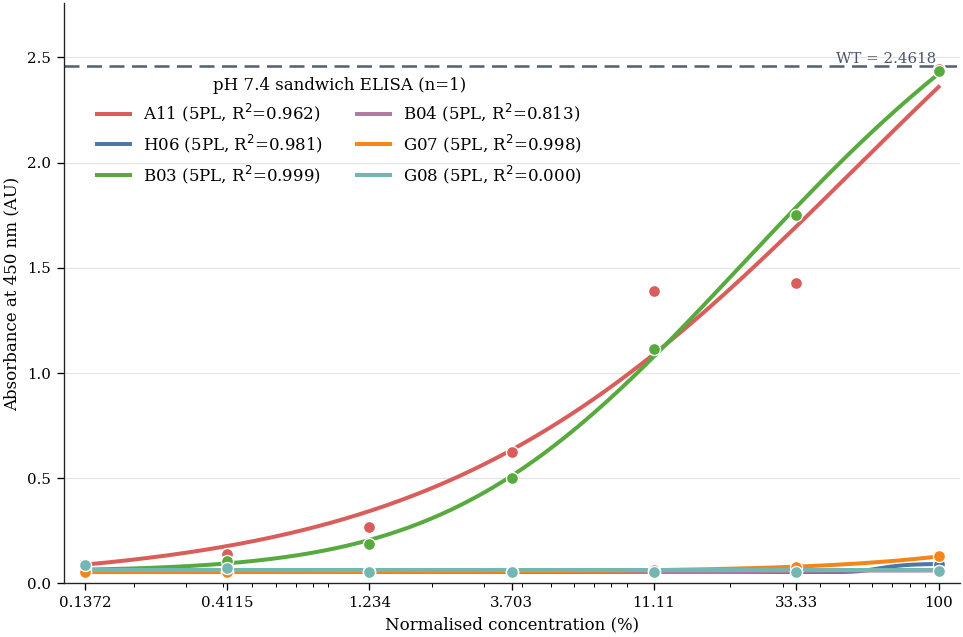

In [3]:
def resolve_existing_file(*candidates: Path) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate the requested ELISA plate export. Tried:\n"
        + "\n".join(str(candidate) for candidate in candidates)
    )


# Prefer repo-local ELISA plate exports when available, then fall back to the
# existing user backup location used during analysis development.
PLATE_1_PATH = resolve_existing_file(
    ROOT / "lab" / "PLA00000.TXT",
    Path.home() / "backup" / Path.home().name / "ELISA" / "PLA00000.TXT",
)
PLATE_2_PATH = resolve_existing_file(
    ROOT / "lab" / "PLA00001.TXT",
    Path.home() / "backup" / Path.home().name / "ELISA" / "PLA00001.TXT",
)
ELISA_DIR = PLATE_1_PATH.parent
# Noramlised 3-fold dilution series
SANDWICH_DILUTION_SERIES = np.array([100.0, 33.33, 11.11, 3.703, 1.234, 0.4115, 0.1372], dtype=float)
# Only the first 7 rows are part of dilution series
SANDWICH_ROWS = tuple("ABCDEFG")
# pH 7.4 sandwich ELISA layout from the Benchling plate map.
# Columns 1-6 hold the FcaRI-binding dilution curves; columns 7-12 are the direct ELISA normalisation wells.
ELISA_N_INDEPENDENT_ASSAYS = 1
SELECTED_VARIANTS = {
    "A11": {"plate_path": PLATE_1_PATH, "columns": (1, 2), "color": "#D95E5B"},
    "H06": {"plate_path": PLATE_1_PATH, "columns": (3, 4), "color": "#4C78A8"},
    "B03": {"plate_path": PLATE_2_PATH, "columns": (3, 4), "color": "#57AA3E"},
    "B04": {"plate_path": PLATE_2_PATH, "columns": (5, 6), "color": "#B279A2"},
    "G07": {"plate_path": PLATE_1_PATH, "columns": (5, 6), "color": "#F58518"},
    "G08": {"plate_path": PLATE_2_PATH, "columns": (1, 2), "color": "#72B7B2"},
}
# Use the average of 2 WT well
WT_WELLS = [
    {"plate_path": PLATE_1_PATH, "well": ("H", 1)},
    {"plate_path": PLATE_2_PATH, "well": ("H", 1)},
]

# function to read ELISA plate data
def read_elisa_plate(plate_file: str | Path) -> pd.DataFrame:
    path = Path(plate_file)
    # read the text file as lines
    lines = path.read_text(encoding="utf-8", errors="replace").splitlines()
    header = None
    rows: dict[str, list[float]] = {}
    idx = 0

    while idx < len(lines):
        line = lines[idx]
        # Keep iterating until the data block is found.
        if not line.lstrip().startswith("Data:"):
            idx += 1
            continue

        # skip the line starts with Data: 
        scan = idx + 1
        while scan < len(lines):
            # Parse either tab-delimited exports or legacy fixed-width spacing.
            stripped_line = lines[scan].strip()
            parts = [part.strip() for part in re.split(r"\t+|\s{2,}", stripped_line) if part.strip()]
            # tokeniser (only take part that's not empty)
            tokens = [part for part in parts if part]
            # if no tokens extracted
            if not tokens:
                scan += 1
                continue
            # if header is not populated and all token are numbers
            if header is None and all(token.isdigit() for token in tokens):
                # set the header to the integer column name
                header = [int(token) for token in tokens]
                scan += 1
                continue
            # if header already populated, this must be a data row
            if header is not None:
                # the first column is always the row name (e.g., A, B, C, D)
                if tokens[0].lower() == "checksum":
                    break
                row_name = tokens[0]
                # confirm the row_name is in the right structure
                if row_name and row_name[0].isalpha() and len(row_name) == 1:
                    # extract the values for the row (except row name)
                    values = tokens[1:]
                    # number of value per row must equal to the number of columns in the header.
                    if len(values) != len(header):
                        raise ValueError(f"Value count does not match the header width in {path}")
                    # add a item to the dictionary
                    rows[row_name.upper()] = [float(value) for value in values]
                    # jump to next line
                    scan += 1
                    continue
                break
            scan += 1
        break

    # if either header or rows not populated
    if header is None or not rows:
        raise ValueError(f"No ELISA data block found in {path}.")

    # create dataframe use header as column and rows as data entry
    plate_df = pd.DataFrame.from_dict(rows, orient="index", columns=header, dtype=float)
    # append the file path as the source_name
    plate_df.attrs["source_name"] = path.name
    return plate_df

# extract the dilution-series wells for one named variant from a plate layout
def extract_variant_measurements(
    plate_df: pd.DataFrame,
    *,
    variant: str,
    columns: tuple[int, int],
    dilution_series: np.ndarray = SANDWICH_DILUTION_SERIES,
    rows: tuple[str, ...] = SANDWICH_ROWS,
) -> pd.DataFrame:
    records = []
    # each row corresponding to 1 dilution
    for dilution_index, (row_label, dilution_value) in enumerate(zip(rows, dilution_series), start=1):
        # for the two replicate
        for replicate_index, column_label in enumerate(columns, start=1):
            # add a record with the name of the variant, the row label,
            # the column label, and the well id, dilution_step, normalised dilution value
            # replicate index, and the absorbance (value from the well).
            records.append(
                {
                    "variant": variant,
                    "row": row_label,
                    "column": column_label,
                    "well": f"{row_label}{column_label}",
                    "dilution_step": dilution_index,
                    "x_norm": dilution_value,
                    "replicate": replicate_index,
                    "absorbance": float(plate_df.loc[row_label, column_label]),
                }
            )
    # return a dataframe representing the wells extracted for a particular variant.
    return pd.DataFrame.from_records(records)

# this function computes the mean absorbance for each variant from duplicate wells
def average_duplicate_wells(variant_measurements: pd.DataFrame) -> pd.DataFrame:
    return (
        variant_measurements.groupby(["variant", "x_norm"], as_index=False)
        .agg(mean_absorbance=("absorbance", "mean"))
        .sort_values(["variant", "x_norm"])
        .reset_index(drop=True)
    )


# keep the constrained logistic parameters strictly positive during optimisation
def _softplus(z: float | np.ndarray) -> float | np.ndarray:
    return np.log1p(np.exp(-np.abs(z))) + np.maximum(z, 0)


# map a positive constrained parameter back into the unconstrained search space
def _inv_softplus(y: float) -> float:
    if y <= 1e-9:
        return -20.0
    if y > 50:
        return float(y)
    return float(np.log(np.expm1(y)))

# compute the corresponding absorbance (y) for normalised dilutions (x) using fitted 4PL model
def four_pl(x: np.ndarray, bottom: float, top: float, slope: float, inflection: float) -> np.ndarray:
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        return bottom + (top - bottom) / (1.0 + (inflection / x) ** slope)

# compute the corresponding absorbance (y) for normalised dilution (x) using fitted 5PL model
def five_pl(x: np.ndarray, bottom: float, top: float, slope: float, inflection: float, asymmetry: float) -> np.ndarray:
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        return bottom + (top - bottom) / ((1.0 + (2 ** (1.0 / asymmetry) - 1.0) * (inflection / x) ** slope) ** asymmetry)

# this convert the paramter array into a python dictionary for compute
def _theta_to_params(theta: np.ndarray, model_name: str) -> dict[str, float]:
    params = {
        "bottom": float(_softplus(theta[0])),
        "top": float(_softplus(theta[0]) + _softplus(theta[1])),
        "slope": float(_softplus(theta[2]) + 1e-6),
        "inflection": float(np.exp(theta[3])),
    }
    if model_name == "5PL":
        params["asymmetry"] = float(_softplus(theta[4]) + 0.05)
    return params

# encapsulate the model paramters into a single ndarray for paramter optimsation.
def _params_to_theta(top: float, slope: float, inflection: float, bottom: float, asymmetry: float | None = None) -> np.ndarray:
    theta = [
        _inv_softplus(max(bottom, 1e-9)),
        _inv_softplus(max(top - bottom, 1e-9)),
        _inv_softplus(max(slope, 1e-9)),
        math.log(max(inflection, 1e-12)),
    ]
    if asymmetry is not None:
        theta.append(_inv_softplus(max(asymmetry - 0.05, 1e-9)))
    return np.array(theta, dtype=float)

# predict the y values (absorbance) given x values (normalised dilution) using model theta (4PL or 5PL depend on model_name)
def _predict_from_theta(x: np.ndarray, theta: np.ndarray, model_name: str) -> np.ndarray:
    params = _theta_to_params(theta, model_name)
    if model_name == "4PL":
        # return the absorbance computed by 4PL
        return four_pl(x, params["bottom"], params["top"], params["slope"], params["inflection"])
    # return the absorbance computed by 5PL
    return five_pl(
        x,
        params["bottom"],
        params["top"],
        params["slope"],
        params["inflection"],
        params["asymmetry"],
    )

# move the parameters ()
def _pattern_search(
    objective,
    theta0: np.ndarray,
    step0: np.ndarray,
    max_iter: int = 160,
    tol: float = 1e-3,
) -> tuple[np.ndarray, float]:
    # retrieve the start value as float array
    theta = theta0.astype(float).copy()
    # retrieve the steps as float array
    steps = np.array(step0, dtype=float)
    # compute the current mean sqaure error
    best = float(objective(theta))

    # iterature over 160 time (by default)
    for _ in range(max_iter):
        improved = False
        # for each parameter
        for idx in range(theta.size):
            for direction in (1.0, -1.0):
                candidate = theta.copy()
                # move the paramter up and down
                candidate[idx] += direction * steps[idx]
                # compute the mean sequared error again with the new value
                score = float(objective(candidate))
                # if the score is better than current best value
                if score < best:
                    # update the 4PL/5PL parameters
                    theta = candidate
                    # update the loss
                    best = score
                    # set improved to True
                    improved = True
                    # break the inner most for loop to attempt next paramter (i.e., +1 and -1 cancels each other)
                    break
        # if no improved observed despite attempt to change all parameters
        if not improved:
            # cut the step size by half
            steps *= 0.5
            # ensure the step size is still above minimum step size (if not break the loop)
            if float(steps.max()) < tol:
                break
    # return the computed best paramter and lowest mean sqaured error computed
    return theta, best

# this function fit a logistic curve over data points using 4PL or 5PL model
def fit_logistic_curve(
    x: np.ndarray,
    y: np.ndarray,
    model_name: str,
    random_starts: int = 64,
    seed: int = 13,
) -> dict[str, object]:
    # create a random seed
    rng = np.random.default_rng(seed)
    # y is absorbance
    y_min = float(y.min())
    y_max = float(y.max())
    # calculate the range of absorbance, define a minimum span to avoid divide by zero issues
    y_span = max(y_max - y_min, 1e-3)
    # x is normalised dilution series
    x_min = float(x.min())
    x_max = float(x.max())
    # computes logarithmic bounds that extend 3-fold below the minimum and 3-fold above the maximum of the x values.
    log_low = math.log(x_min / 3.0)
    log_high = math.log(x_max * 3.0)


    if model_name == "4PL":
        # create initial parameter guess from data extremes
        base_theta = _params_to_theta(y_max, 1.0, np.median(x), max(y_min * 0.8, 1e-6))
        # defines initial step sizez for pattern search
        step0 = np.array([0.4, 0.5, 0.5, 0.9])
    else:
        # 5PL add asymmetry parameter
        base_theta = _params_to_theta(y_max, 1.0, np.median(x), max(y_min * 0.8, 1e-6), 1.0)
        # add the step by the fifth parameter
        step0 = np.array([0.4, 0.5, 0.5, 0.9, 0.4])

    # a internal function that computes mean squared between predicted and actual y values
    def objective(theta: np.ndarray) -> float:
        prediction = _predict_from_theta(x, theta, model_name)
        # return infinity if predictions contain non-finite values (invalid parameters)
        if not np.all(np.isfinite(prediction)):
            return np.inf
        return float(np.mean((prediction - y) ** 2))

    # compute the best paramters and lowest mean squared error
    best_theta, best_score = _pattern_search(objective, base_theta, step0)

    # repeat the same optimisation process from different random starting points to improve chances of finding global optimum
    for _ in range(random_starts):
        # random starting paramters generation withtin biological plausible ranges
        # buttom and top: response asymtotes near the data extremes
        bottom = rng.uniform(max(1e-6, y_min - 0.25 * y_span), y_min + 0.35 * y_span)
        top = rng.uniform(y_max - 0.2 * y_span, y_max + 0.5 * y_span)
        if top <= bottom:
            top = bottom + 0.2 * y_span
        # slop in log space to allow wide range (0.16, to ~7.9)
        slope = 10 ** rng.uniform(-0.8, 0.9)
        # inflection: EC50/IC50 value in concentration space
        inflection = math.exp(rng.uniform(log_low, log_high))
        # use 4PL formula here
        if model_name == "4PL":
            theta0 = _params_to_theta(top, slope, inflection, max(bottom, 1e-6))
        else:
            # user 5PL formula here, random asymmetry paramter (range: ~0.45 to 2.2)
            asymmetry = 10 ** rng.uniform(-0.35, 0.35)
            theta0 = _params_to_theta(top, slope, inflection, max(bottom, 1e-6), asymmetry)
        # evaluate and udpate Best
        theta, score = _pattern_search(objective, theta0, step0)
        # updates best solution if this run yield lower mean sqaured error
        if score < best_score:
            best_theta, best_score = theta, score

    # retrieve the predicted absorbance value
    fitted = _predict_from_theta(x, best_theta, model_name)
    # compute sum of sqaured errors
    sse = float(np.sum((fitted - y) ** 2))
    # compute root mean sqaured errors
    rmse = float(np.sqrt(np.mean((fitted - y) ** 2)))
    # compute total sum of sqaures
    tss = float(np.sum((y - y.mean()) ** 2))
    # compute R-sqaured
    r_squared = 1.0 - sse / tss if tss > 0 else float("nan")
    # akaike information criterion, where n = len(y) and k = len(best_theta)
    # it balances fit quality against model complexity
    # lower is better, but only for comparing models fit to the same dataset
    aic = len(y) * math.log(sse / len(y) if sse > 0 else 1e-12) + 2 * len(best_theta)
    return {
        "model": model_name,
        "theta": best_theta,
        "params": _theta_to_params(best_theta, model_name),
        "predict": lambda x_new: _predict_from_theta(np.asarray(x_new, dtype=float), best_theta, model_name),
        "rmse": rmse,
        "r_squared": r_squared,
        "aic": aic,
    }




# create lookup dataframe for the plates
plate_lookup = {
    PLATE_1_PATH: read_elisa_plate(PLATE_1_PATH),
    PLATE_2_PATH: read_elisa_plate(PLATE_2_PATH),
}

# combine all the well measurement into a single dtaframe
variant_measurements = pd.concat(
    [
        # for each variant call extract_variant_measurements() to extract data from a plate, passing:
        extract_variant_measurements(
            plate_lookup[config["plate_path"]],
            variant=variant,
            columns=config["columns"],
        ).assign(plate_name=config["plate_path"].name)
        # iterate over SELECTED_VARIANT dictionary (variant name -> config)
        for variant, config in SELECTED_VARIANTS.items()
    ],
    ignore_index=True,
)

# compute the mean absorbance for each variant and store the result in a dataframe
variant_curve_summary = average_duplicate_wells(variant_measurements)

fit_results = {}
# fit a 5PL curve to each averaged dilution series and keep the fitted model for plotting
for variant in SELECTED_VARIANTS:
    # take the dataframe corresponding to that variant
    subset = variant_curve_summary[variant_curve_summary["variant"] == variant].copy()
    # fit the 5PL logistic curve for this variant
    fit_results[variant] = fit_logistic_curve(
        subset["x_norm"].to_numpy(dtype=float),
        subset["mean_absorbance"].to_numpy(dtype=float),
        model_name="5PL",
    )
# compute the wt_absorbance for plotting
wt_absorbance = float(
    np.mean([
        plate_lookup[item["plate_path"]].loc[item["well"][0], item["well"][1]]
        for item in WT_WELLS
    ])
)
# define the ymax for the plot(either the highest mean_absorbance across duplicate in variant or wt) with a bit extra over head.
plot_ymax = max(float(variant_curve_summary["mean_absorbance"].max()), wt_absorbance) * 1.12

# a good fig size for A4 paged thesis
fig, ax = plt.subplots(figsize=(8.27, 5.55))
# use 500 points
xs = np.geomspace(SANDWICH_DILUTION_SERIES.min(), SANDWICH_DILUTION_SERIES.max(), 500)

for variant, config in SELECTED_VARIANTS.items():
    color = config["color"]
    # retrieve the dataframe for the particular variant of interest
    summary = variant_curve_summary[variant_curve_summary["variant"] == variant].copy().sort_values("x_norm")
    # plot the dots for the variant (i.e., 7 data points)
    ax.scatter(
        summary["x_norm"],
        summary["mean_absorbance"],
        color=color,
        s=52,
        edgecolors="white",
        linewidths=0.8,
        zorder=3,
    )

    fit = fit_results[variant]
    r_squared = float(fit["r_squared"])
    if np.isfinite(r_squared) and abs(r_squared) < 5e-4:
        r_squared = 0.0
    # plot the curve using the 
    ax.plot(
        xs,
        # use the fitted model to predict the points
        fit["predict"](xs),
        color=color,
        lw=2.4,
        label=f"{variant} ({fit['model']}, R$^2$={r_squared:.3f})",
    )

# draw a horizontal line at with wt is
ax.axhline(wt_absorbance, color="#4a5568", lw=1.5, ls=(0, (6, 3)), alpha=0.95)
ax.text(
    xs.max() * 0.985,
    wt_absorbance,
    f"WT = {wt_absorbance:.4f}",
    ha="right",
    va="bottom",
    fontsize=9,
    color="#4a5568",
)

ax.set_xscale("log")
ax.set_xlim(SANDWICH_DILUTION_SERIES.min() * 0.85, SANDWICH_DILUTION_SERIES.max() * 1.18)
ax.set_ylim(0.0, plot_ymax)
ax.set_xticks(SANDWICH_DILUTION_SERIES)
ax.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda value, pos: f"{value:g}"))
ax.grid(axis="y", color="#d9d9d9", linewidth=0.7, alpha=0.7)
ax.set_xlabel("Normalised concentration (%)")
ax.set_ylabel("Absorbance at 450 nm (AU)")
ax.legend(
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0.02, 0.90),
    ncol=2,
    title=f"pH 7.4 sandwich ELISA (n={ELISA_N_INDEPENDENT_ASSAYS})",
    title_fontsize=10,
)
fig.tight_layout()
plt.show()
# save the ELISA figure beside the other lab-specific outputs
elisa_output_dir = FIGURES_DIR
elisa_output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(elisa_output_dir / "figure_7_ELISA_binding_curves.svg", dpi=300, format="svg")

## Figure 10 - Read retention evaluation across QC stages for all datasets

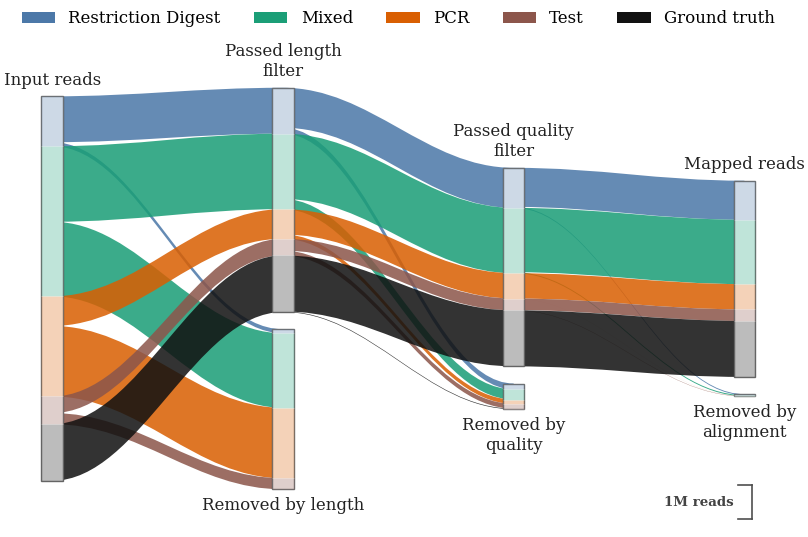

PosixPath('figures/figure_10_read_retention_by_dataset.svg')

In [4]:
# keep only the datasets included in the thesis retention comparison
plot_3_1_df = data_df[data_df["display_name"].isin(READ_RETENTION_DATASETS)].copy()
dataset_sankey_colors = {name: family_color(name) for name in READ_RETENTION_DATASETS}
dataset_group_order = [name for name in DATASET_ORDER if name in plot_3_1_df["display_name"].tolist()]
dataset_links = []

for _, row in plot_3_1_df.sort_values("sort_order").iterrows():
    name = row["display_name"]
    pre = int(row["pre_length_filter_reads"])
    post_length = int(row["post_length_filter_reads"])
    post_quality = int(row["post_quality_filter_reads"])
    post_alignment = int(row["post_alignment_filter_reads"])
    dataset_links.extend(
        [
            {"source": "Input", "target": "Length pass", "group": name, "value": post_length},
            {"source": "Input", "target": "Removed at length", "group": name, "value": pre - post_length},
            {"source": "Length pass", "target": "Quality pass", "group": name, "value": post_quality},
            {"source": "Length pass", "target": "Removed at quality", "group": name, "value": post_length - post_quality},
            {"source": "Quality pass", "target": "Alignment pass", "group": name, "value": post_alignment},
            {"source": "Quality pass", "target": "Removed at alignment", "group": name, "value": post_quality - post_alignment},
        ]
    )

# draw the dataset-level flow through the length, quality, and alignment filters
fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_segmented_sankey(
    ax,
    columns=[
        ["Input"],
        ["Length pass", "Removed at length"],
        ["Quality pass", "Removed at quality"],
        ["Alignment pass", "Removed at alignment"],
    ],
    column_x=[0.05, 0.35, 0.65, 0.95],
    links=dataset_links,
    group_order=dataset_group_order,
    group_colors=dataset_sankey_colors,
    node_labels={
        "Input": "Input reads",
        "Length pass": "Passed length\nfilter",
        "Removed at length": "Removed by length",
        "Quality pass": "Passed quality\nfilter",
        "Removed at quality": "Removed by\nquality",
        "Alignment pass": "Mapped reads",
        "Removed at alignment": "Removed by\nalignment",
    },
    label_placements={
        "Input": "above",
        "Length pass": "above",
        "Removed at length": "below",
        "Quality pass": "above",
        "Removed at quality": "below",
        "Alignment pass": "above",
        "Removed at alignment": "below",
    },
    show_scale_bar=True,
    scale_bar_value=1000000,
)
dataset_handles = [
    mpl.patches.Patch(facecolor=dataset_sankey_colors[name], edgecolor="none", label=display_label(name))
    for name in dataset_group_order
]
ax.legend(
    dataset_handles,
    [handle.get_label() for handle in dataset_handles],
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    loc="lower center",
    borderaxespad=0.0,
    ncol=5,
)
finalize_panel(fig, "figure_10_read_retention_by_dataset")


## Figure 11. Violin plots comparing the distribution of per-read Q-scores before and after quality control by dataset

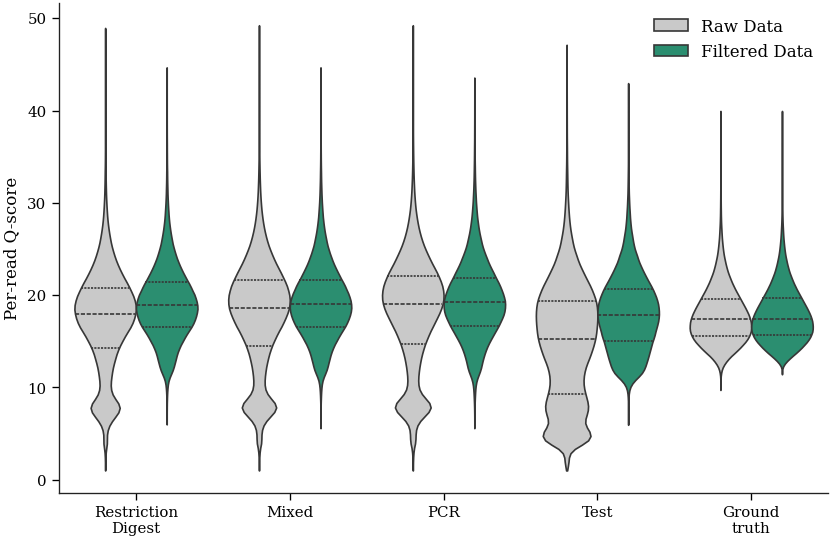

PosixPath('figures/figure_11_per_read_q_score_distribution.svg')

In [5]:
# reuse the same dataset subset as panel 1 so the retention and Q-score views stay aligned
plot_3_1_df = data_df[data_df["display_name"].isin(READ_RETENTION_DATASETS)].copy()
fastq_df = load_fastq_distribution(plot_3_1_df, sys.maxsize)
violin_order = [name for name in DATASET_ORDER if name in fastq_df["dataset"].unique()]

# compare the raw and filtered per-read mean-Q distributions for each dataset
fig, ax = plt.subplots(figsize=(8.27, 5.3))
sns.violinplot(
    data=fastq_df,
    x="dataset",
    y="mean_q",
    hue="filter",
    hue_order=["Raw Data", "Filtered Data"],
    order=violin_order,
    split=False,
    dodge=True,
    inner="quart",
    linewidth=1.0,
    palette=["#c9c9c9", "#1b9e77"],
    ax=ax,
    density_norm="width",
    cut=0,
)
ax.set_xlabel("")
ax.set_ylabel("Per-read Q-score")
ax.set_xticks(np.arange(len(violin_order)))
ax.set_xticklabels([format_model_label(name) for name in violin_order], rotation=0, ha="center")
stage_handles, stage_labels = ax.get_legend_handles_labels()
if ax.legend_ is not None:
    ax.legend_.remove()
ax.legend(stage_handles, stage_labels, frameon=False, loc="upper right", title="", ncol=1)
finalize_panel(fig, "figure_11_per_read_q_score_distribution")


## Figure 12. Read retention evaluation across filtering stages for different basecalling models and ground truth. 


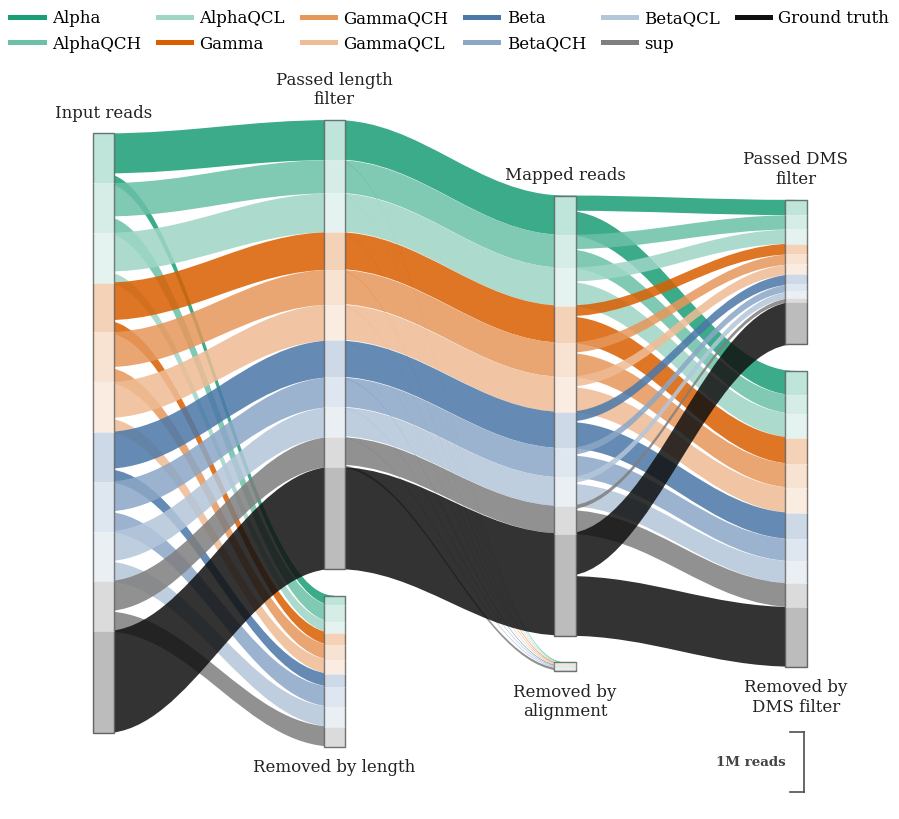

PosixPath('figures/figure_12_read_retention_by_model.svg')

In [6]:
# prepare the model-level retention flows and colour them by family/variant
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
plot_3_2_order = [name for name in DISPLAY_ORDER if name in plot_3_2_df["display_name"].tolist()]
plot_3_2_colors = {}
for _, row in plot_3_2_df.iterrows():
    color = family_color(row["family"])
    if row["variant"] == "QCH":
        color = mpl.colors.to_hex(lighten_color(color, 0.35))
    elif row["variant"] == "QCL":
        color = mpl.colors.to_hex(lighten_color(color, 0.58))
    plot_3_2_colors[row["display_name"]] = color

model_links = []
for _, row in plot_3_2_df.sort_values("sort_order").iterrows():
    name = row["display_name"]
    pre = int(row["pre_length_filter_reads"])
    post_length = int(row["post_length_filter_reads"])
    post_alignment = int(row["post_alignment_filter_reads"])
    post_dms = int(row["post_dms_filter_reads"])
    model_links.extend(
        [
            {"source": "Input", "target": "Length pass", "group": name, "value": post_length},
            {"source": "Input", "target": "Removed at length", "group": name, "value": pre - post_length},
            {"source": "Length pass", "target": "Alignment pass", "group": name, "value": post_alignment},
            {"source": "Length pass", "target": "Removed at alignment", "group": name, "value": post_length - post_alignment},
            {"source": "Alignment pass", "target": "DMS pass", "group": name, "value": post_dms},
            {"source": "Alignment pass", "target": "Removed at DMS", "group": name, "value": post_alignment - post_dms},
        ]
    )

fig, ax = plt.subplots(figsize=(8.27, 8.27))
draw_segmented_sankey(
    ax,
    columns=[
        ["Input"],
        ["Length pass", "Removed at length"],
        ["Alignment pass", "Removed at alignment"],
        ["DMS pass", "Removed at DMS"],
    ],
    column_x=[0.05, 0.35, 0.65, 0.95],
    links=model_links,
    group_order=plot_3_2_order,
    group_colors=plot_3_2_colors,
    node_labels={
        "Input": "Input reads",
        "Length pass": "Passed length\nfilter",
        "Removed at length": "Removed by length",
        "Alignment pass": "Mapped reads",
        "Removed at alignment": "Removed by\nalignment",
        "DMS pass": "Passed DMS\nfilter",
        "Removed at DMS": "Removed by\nDMS filter",
    },
    label_placements={
        "Input": "above",
        "Length pass": "above",
        "Removed at length": "below",
        "Alignment pass": "above",
        "Removed at alignment": "below",
        "DMS pass": "above",
        "Removed at DMS": "below",
    },
    show_scale_bar=True,
    scale_bar_value=1000000,
)
panel_a_handles = [build_display_legend_handle(name, color=plot_3_2_colors[name], show_special_marker=False) for name in plot_3_2_order]
ax.legend(
    handles=panel_a_handles,
    frameon=False,
    ncol=6,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.99),
    borderaxespad=0.0,
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "figure_12_read_retention_by_model")


## Figure 13. Comparison of post-alignment metrics of model basecalls on the held-out test dataset. 

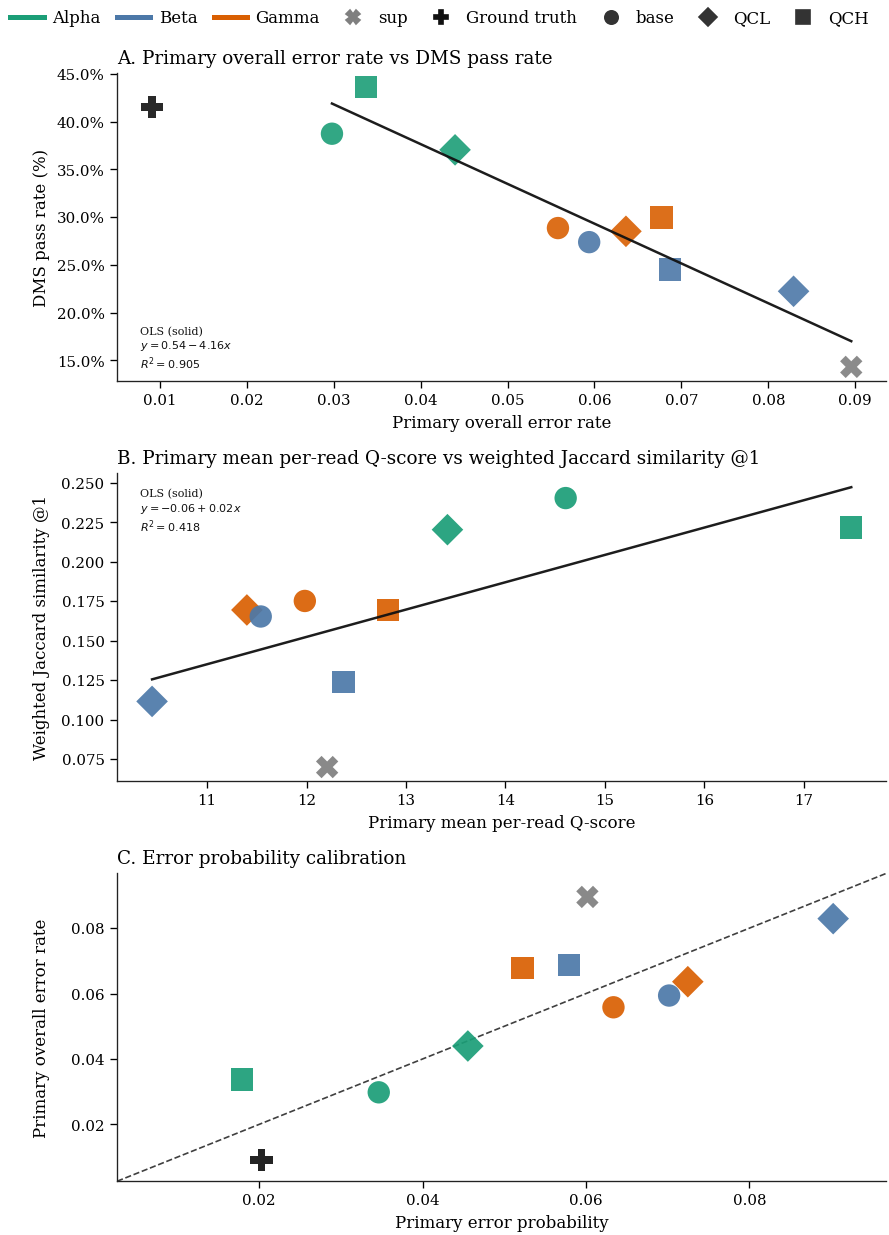

PosixPath('figures/figure_13_post_alignment_metrics_scatter.svg')

In [7]:
# combine the model-level error, read-quality, and calibration scatter panels into one A4 figure
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
model_qscore_df = build_model_mean_q_summary(plot_3_2_df, filter="post_alignment_filter", sample_size=sys.maxsize)
qscore_scatter_df = model_qscore_df.merge(
    plot_3_2_df[["display_name", "weighted_jaccard_1", "primary_overall_error_rate"]],
    on="display_name",
    how="left",
)
qscore_no_ground_truth_df = qscore_scatter_df[qscore_scatter_df["display_name"] != "UDP0057"].copy()
qscore_scatter_df["mean_per_read_q_error_probability"] = np.power(
    10.0,
    -qscore_scatter_df["mean_per_read_q"] / 10.0,
)
family_handles, variant_handles = build_legend_handles(balance=False)

fig, axes = plt.subplots(3, 1, figsize=(8.27, 11.69))

# A. Primary alignment error rate against DMS pass rate.
ax = axes[0]
for _, row in plot_3_2_df.iterrows():
    ax.scatter(
        row["primary_overall_error_rate"],
        row["pass_rate"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        alpha=0.90,
        edgecolors="none",
    )
add_model_ols_fit(
    ax,
    plot_3_2_df,
    x_col="primary_overall_error_rate",
    y_col="pass_rate",
    text_xy=(0.03, 0.03),
    text_va="bottom"
)
ax.set_title("A. Primary overall error rate vs DMS pass rate", loc="left")
ax.set_xlabel("Primary overall error rate")
ax.set_ylabel("DMS pass rate (%)")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.margins(x=0.05)

# B. Post-alignment mean Q-score against abundance concordance, excluding the ground truth datapoint.
ax = axes[1]
for _, row in qscore_no_ground_truth_df.iterrows():
    ax.scatter(
        row["mean_per_read_q"],
        row["weighted_jaccard_1"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        alpha=0.92,
        edgecolors="none",
    )
add_model_ols_fit(
    ax,
    qscore_no_ground_truth_df,
    x_col="mean_per_read_q",
    y_col="weighted_jaccard_1",
)
ax.set_title("B. Primary mean per-read Q-score vs weighted Jaccard similarity @1", loc="left")
ax.set_xlabel("Primary mean per-read Q-score")
ax.set_ylabel("Weighted Jaccard similarity @1")
ax.margins(x=0.05)

# C. Transform post-alignment mean Q-score back to error-probability scale before comparing with observed primary error rate.
ax = axes[2]
for _, row in qscore_scatter_df.iterrows():
    ax.scatter(
        row["mean_per_read_q_error_probability"],
        row["primary_overall_error_rate"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        alpha=0.92,
        edgecolors="none",
    )
calibration_min = min(
    qscore_scatter_df["mean_per_read_q_error_probability"].min(),
    qscore_scatter_df["primary_overall_error_rate"].min(),
)
calibration_max = max(
    qscore_scatter_df["mean_per_read_q_error_probability"].max(),
    qscore_scatter_df["primary_overall_error_rate"].max(),
)
calibration_padding = (calibration_max - calibration_min) * 0.08
calibration_lower = max(0.0, calibration_min - calibration_padding)
calibration_upper = calibration_max + calibration_padding
ax.plot(
    [calibration_lower, calibration_upper],
    [calibration_lower, calibration_upper],
    color="black",
    linestyle="--",
    linewidth=1.0,
    alpha=0.75,
    zorder=0,
)
ax.set_xlim(calibration_lower, calibration_upper)
ax.set_ylim(calibration_lower, calibration_upper)
ax.set_title("C. Error probability calibration", loc="left")
ax.set_xlabel("Primary error probability")
ax.set_ylabel("Primary overall error rate")

fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=8,
    loc="upper center",
    bbox_to_anchor=(0.45, 0.95),
    borderaxespad=0.0,
    columnspacing=1,
    handletextpad=0.5,
)
fig.align_ylabels(axes)
fig.subplots_adjust(top=0.90, hspace=0.30)
finalize_panel(fig, "figure_13_post_alignment_metrics_scatter")


## Figure 14. Multi-metric basecalling/variant-calling performance comparison. 

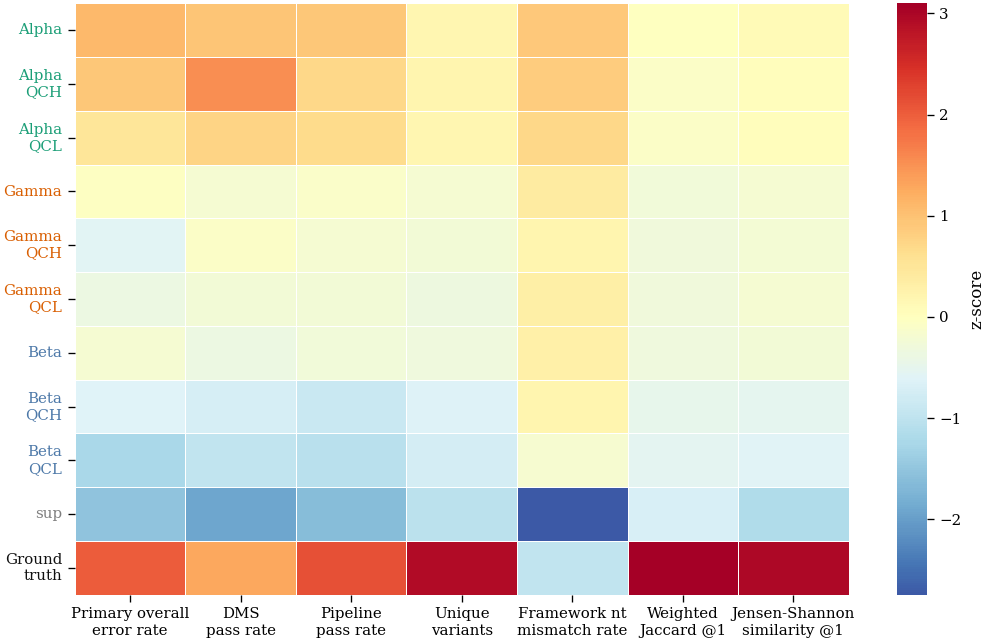

PosixPath('figures/figure_14_multi_metric_performance_comparison.svg')

In [8]:
# z-score the main performance metrics so the model rows can be compared on one shared scale
plot_3_2_metrics = [
    ("primary_overall_error_rate", "Primary overall error rate", False),
    ("pass_rate", "DMS pass rate", True),
    ("pipeline_pass_rate", "Pipeline pass rate", True),
    ("unique_variants", "Unique variants", True),
    ("avg_framework_nucleotide_mismatches_per_read", "Framework nt mismatch", False),
    ("weighted_jaccard_1", "Weighted Jaccard @1", True),
    ("jensen_shannon_similarity_1", "Jensen-Shannon similarity @1", True),
]
plot_3_2_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy()
plot_3_2_order = [name for name in DISPLAY_ORDER if name in plot_3_2_df["display_name"].tolist()]
heatmap_df = (
    zscore_metrics(plot_3_2_df.set_index("display_name").loc[plot_3_2_order], plot_3_2_metrics)
    .loc[plot_3_2_order]
)

fig, ax = plt.subplots(figsize=(10.4, 6.4))
sns.heatmap(
    heatmap_df,
    cmap="RdYlBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "z-score"},
    ax=ax,
)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticklabels(
    [
        "Primary overall\nerror rate",
        "DMS\npass rate",
        "Pipeline\npass rate",
        "Unique\nvariants",
        "Framework nt\nmismatch rate",
        "Weighted\nJaccard @1",
        "Jensen-Shannon\nsimilarity @1",
    ],
    rotation=0,
    ha="center",
)
color_model_ticklabels(ax, axis="y")
finalize_panel(fig, "figure_14_multi_metric_performance_comparison")


## Figure 15. Correlation between model validation loss against downstream metrics on the held-out test dataset by model. 

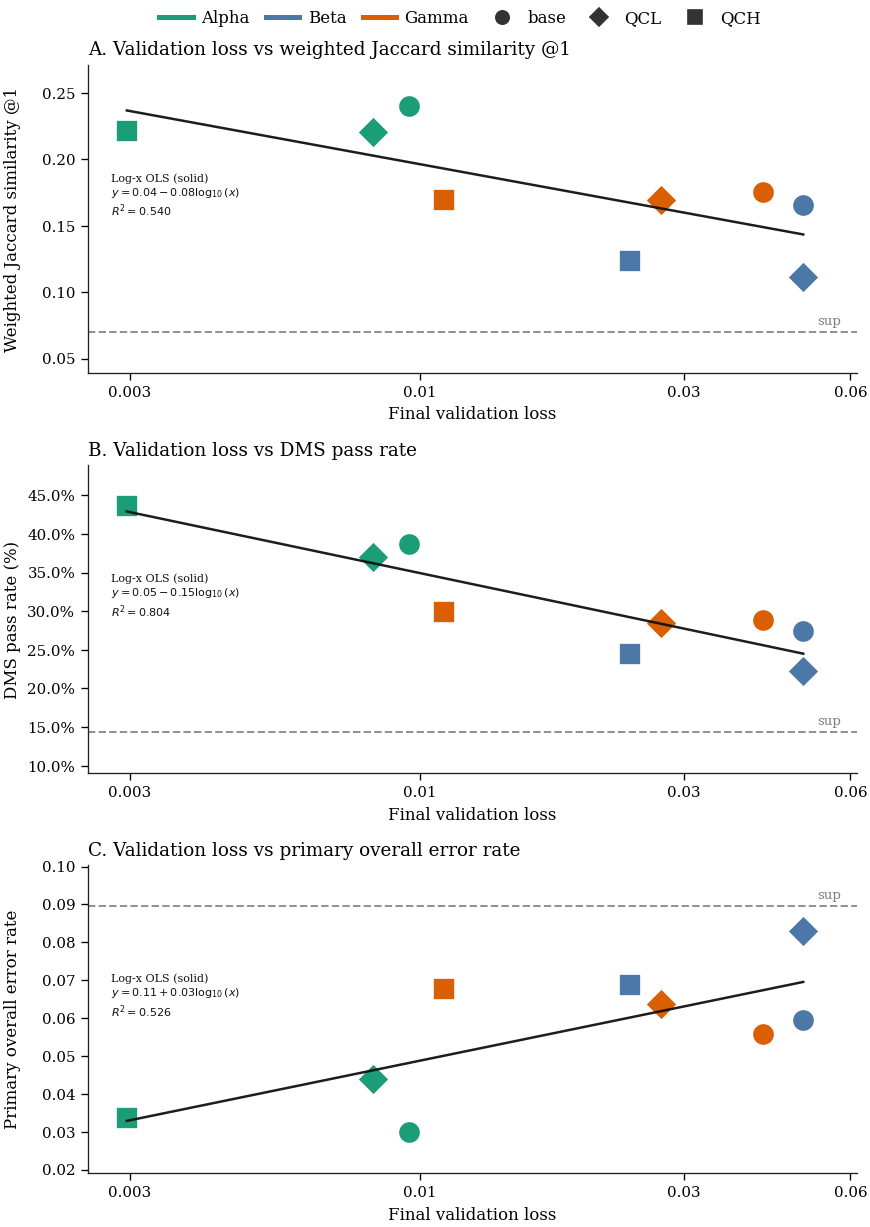

PosixPath('figures/figure_15_validation_loss_vs_downstream_metrics.svg')

In [9]:
# combine validation-loss scatter panels into one A4 figure
plot_3_3_df = model_summary_df[model_summary_df["display_name"] != "sup"].copy()
sup_summary_row = model_summary_df[model_summary_df["display_name"] == "sup"].iloc[0]
x_min = plot_3_3_df["validation_loss"].min()
x_max = plot_3_3_df["validation_loss"].max()
validation_ticks = [0.003, 0.01, 0.03, 0.06]
family_handles, variant_handles = build_legend_handles(include_sup=False, include_ground_truth=False, balance=False)
validation_panel_specs = [
    ("A. Validation loss vs weighted Jaccard similarity @1", "weighted_jaccard_1", "Weighted Jaccard similarity @1", None),
    ("B. Validation loss vs DMS pass rate", "pass_rate", "DMS pass rate (%)", PercentFormatter(xmax=1.0)),
    ("C. Validation loss vs primary overall error rate", "primary_overall_error_rate", "Primary overall error rate", None),
]

fig, axes = plt.subplots(3, 1, figsize=(8.27, 11.69))
for ax, (title, y_col, y_label, y_formatter) in zip(axes, validation_panel_specs):
    for _, row in plot_3_3_df.iterrows():
        ax.scatter(
            row["validation_loss"],
            row[y_col],
            s=MODEL_MARKER_SIZE,
            color=family_color(row["family"]),
            marker=VARIANT_MARKERS[row["variant"]],
            edgecolor="white",
            linewidth=1.0,
        )
    ax.axhline(
        sup_summary_row[y_col],
        color=family_color("sup"),
        linestyle="--",
        linewidth=1.2,
        alpha=0.85,
        zorder=0,
    )
    ax.annotate(
        "sup",
        xy=(0.98, sup_summary_row[y_col]),
        xycoords=ax.get_yaxis_transform(),
        xytext=(0, 3),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=8,
        color=family_color("sup"),
        annotation_clip=False,
        zorder=5,
    )
    add_model_ols_fit(
        ax,
        plot_3_3_df,
        x_col="validation_loss",
        y_col=y_col,
        transform_x="log10",
        text_xy=(0.03, 0.5),
        text_va="bottom",
    )
    ax.set_xscale("log")
    ax.set_xlim(x_min * 0.85, x_max * 1.25)
    ax.set_xticks(validation_ticks)
    ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda value, pos: f"{value:.3f}" if value < 0.01 else f"{value:.2f}".rstrip("0").rstrip("."))
    )
    ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
    if y_formatter is not None:
        ax.yaxis.set_major_formatter(y_formatter)
    ax.set_title(title, loc="left")
    ax.set_xlabel("Final validation loss")
    ax.set_ylabel(y_label)
    ax.margins(y=0.18)

fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=6,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    columnspacing=1,
    handletextpad=0.5,
)
fig.align_ylabels(axes)
fig.subplots_adjust(top=0.90, hspace=0.30)
finalize_panel(fig, "figure_15_validation_loss_vs_downstream_metrics")


## Figure 16. Dataset-level error analysis

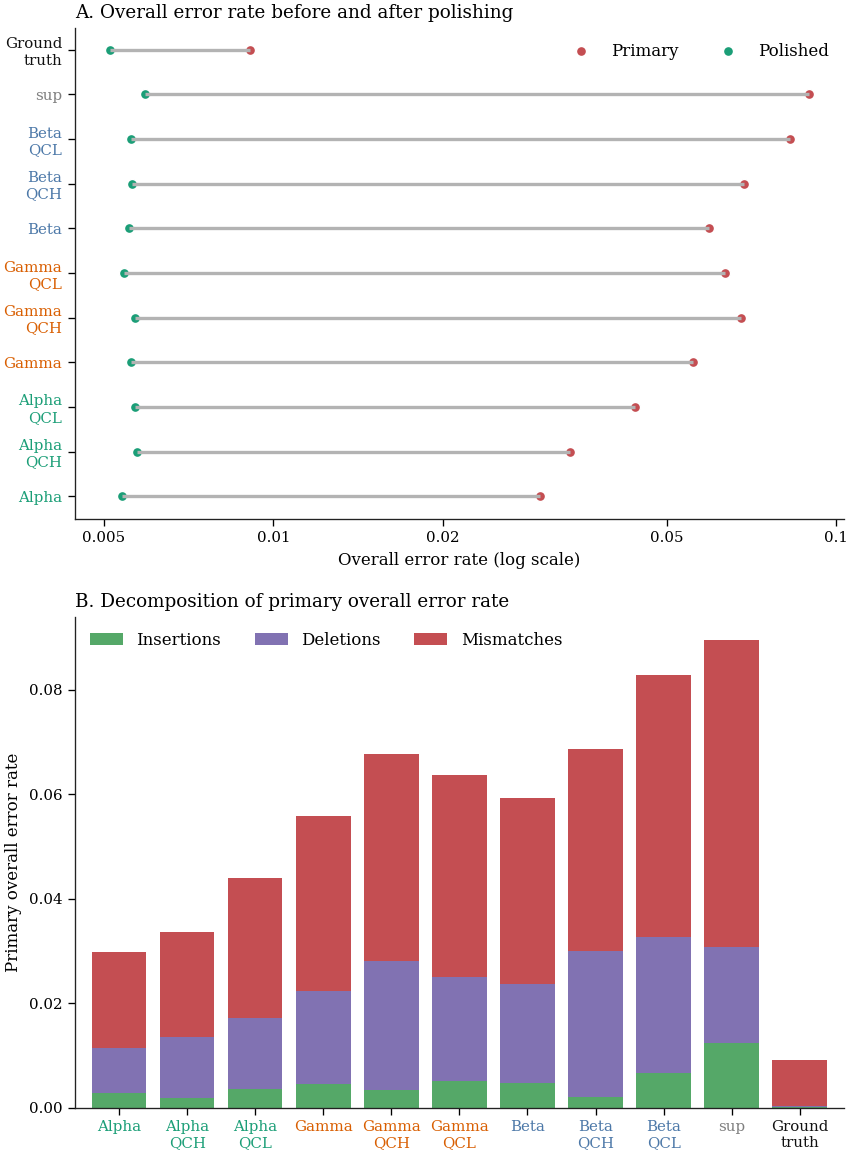

PosixPath('figures/figure_16_dataset_level_error_analysis.svg')

In [10]:
# pair the overall-error shift with the primary-error composition in one composite panel
plot_3_4_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
y_pos = np.arange(len(plot_3_4_df))
ordered = plot_3_4_df.copy()
ordered["Insertions"] = ordered["primary_inserted_bases"] / ordered["primary_bases_mapped"]
ordered["Deletions"] = ordered["primary_deleted_bases"] / ordered["primary_bases_mapped"]
ordered["Mismatches"] = ordered["primary_mismatches"] / ordered["primary_bases_mapped"]
stacked_components = ordered.set_index("display_name")[["Insertions", "Deletions", "Mismatches"]]

fig = plt.figure(figsize=(8.27, 11.69))
grid = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.0])
error_rate_ax = fig.add_subplot(grid[0, 0])
composition_ax = fig.add_subplot(grid[1, 0])

error_rate_ax.hlines(
    y_pos,
    plot_3_4_df["polished_overall_error_rate"],
    plot_3_4_df["primary_overall_error_rate"],
    color="#b3b3b3",
    lw=2,
)
error_rate_ax.scatter(
    plot_3_4_df["primary_overall_error_rate"],
    y_pos,
    color="#c44e52",
    edgecolor="white",
    linewidth=0.8,
    label="Primary",
)
error_rate_ax.scatter(
    plot_3_4_df["polished_overall_error_rate"],
    y_pos,
    color="#1b9e77",
    edgecolor="white",
    linewidth=0.8,
    label="Polished",
)
error_rate_ax.set_yticks(y_pos)
error_rate_ax.set_yticklabels(plot_3_4_df["display_name"])
color_model_ticklabels(error_rate_ax, axis="y")
error_rate_ax.set_xscale("log")
error_rate_ax.set_xticks([0.005, 0.01, 0.02, 0.05, 0.1])
error_rate_ax.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda value, pos: f"{value:.3f}" if value < 0.01 else f"{value:.2f}".rstrip("0").rstrip("."))
)
error_rate_ax.xaxis.set_minor_locator(mpl.ticker.NullLocator())
error_rate_ax.set_xlabel("Overall error rate (log scale)")
error_rate_ax.set_title("A. Overall error rate before and after polishing", loc="left")
error_rate_ax.legend(frameon=False, loc="upper right", ncol=2)

stacked_components.plot(
    kind="bar",
    stacked=True,
    color=["#55a868", "#8172b2", "#c44e52"],
    ax=composition_ax,
    width=0.8,
)
composition_ax.set_ylabel("Primary overall error rate")
composition_ax.set_xlabel("")
composition_ax.set_title("B. Decomposition of primary overall error rate", loc="left")
composition_ax.tick_params(axis="x", rotation=0)
color_model_ticklabels(composition_ax, axis="x")
composition_ax.legend(frameon=False, title="", loc="upper left", ncol=3)

#fig.subplots_adjust(top=0.97, bottom=0.07, left=0.10, right=0.98, hspace=0.35)
finalize_panel(fig, "figure_16_dataset_level_error_analysis")

## Figure 17. Read-level error analysis. 

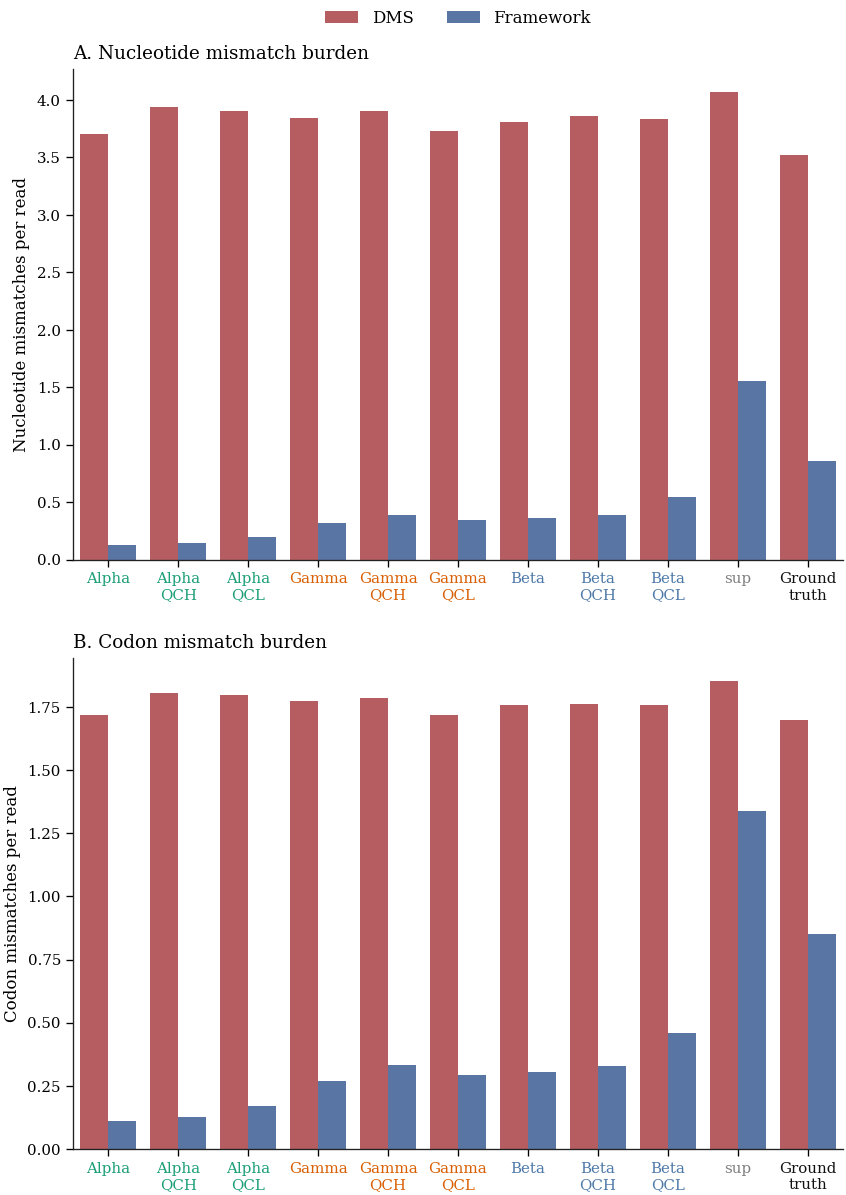

PosixPath('figures/figure_17_read_level_error_analysis.svg')

In [11]:
# combine the nucleotide and codon burden summaries into one composite figure
plot_3_4_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
burden_df = pd.concat(
    [
        plot_3_4_df[["display_name", "avg_dms_nucleotide_mismatches_per_read", "avg_framework_nucleotide_mismatches_per_read"]]
        .rename(
            columns={
                "avg_dms_nucleotide_mismatches_per_read": "DMS",
                "avg_framework_nucleotide_mismatches_per_read": "Framework",
            }
        )
        .assign(unit="Nucleotide mismatches per read"),
        plot_3_4_df[["display_name", "avg_dms_codon_mismatches_per_read", "avg_framework_codon_mismatches_per_read"]]
        .rename(
            columns={
                "avg_dms_codon_mismatches_per_read": "DMS",
                "avg_framework_codon_mismatches_per_read": "Framework",
            }
        )
        .assign(unit="Codon mismatches per read"),
    ],
    ignore_index=True,
)
burden_long = burden_df.melt(id_vars=["display_name", "unit"], value_vars=["DMS", "Framework"], var_name="region", value_name="value")
plot_3_4_order = plot_3_4_df["display_name"].tolist()

fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69))
panel_specs = [
    ("A. Nucleotide mismatch burden", "Nucleotide mismatches per read", axes[0]),
    ("B. Codon mismatch burden", "Codon mismatches per read", axes[1]),
]
for title, unit, ax in panel_specs:
    subset = burden_long[burden_long["unit"] == unit]
    sns.barplot(
        data=subset,
        x="display_name",
        y="value",
        hue="region",
        palette=REGION_COLORS,
        order=plot_3_4_order,
        ax=ax,
    )
    ax.set_title(title, loc="left")
    ax.set_xlabel("")
    ax.set_ylabel(unit)
    ax.tick_params(axis="x", rotation=0)
    color_model_ticklabels(ax, axis="x")

axes[0].legend(frameon=False, title="", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.15))
axes[1].legend().remove()
#fig.subplots_adjust(top=0.97, bottom=0.07, left=0.10, right=0.98, hspace=0.35)
finalize_panel(fig, "figure_17_read_level_error_analysis")

## Figure 18. Composition analysis at dual-site DMS library level. 

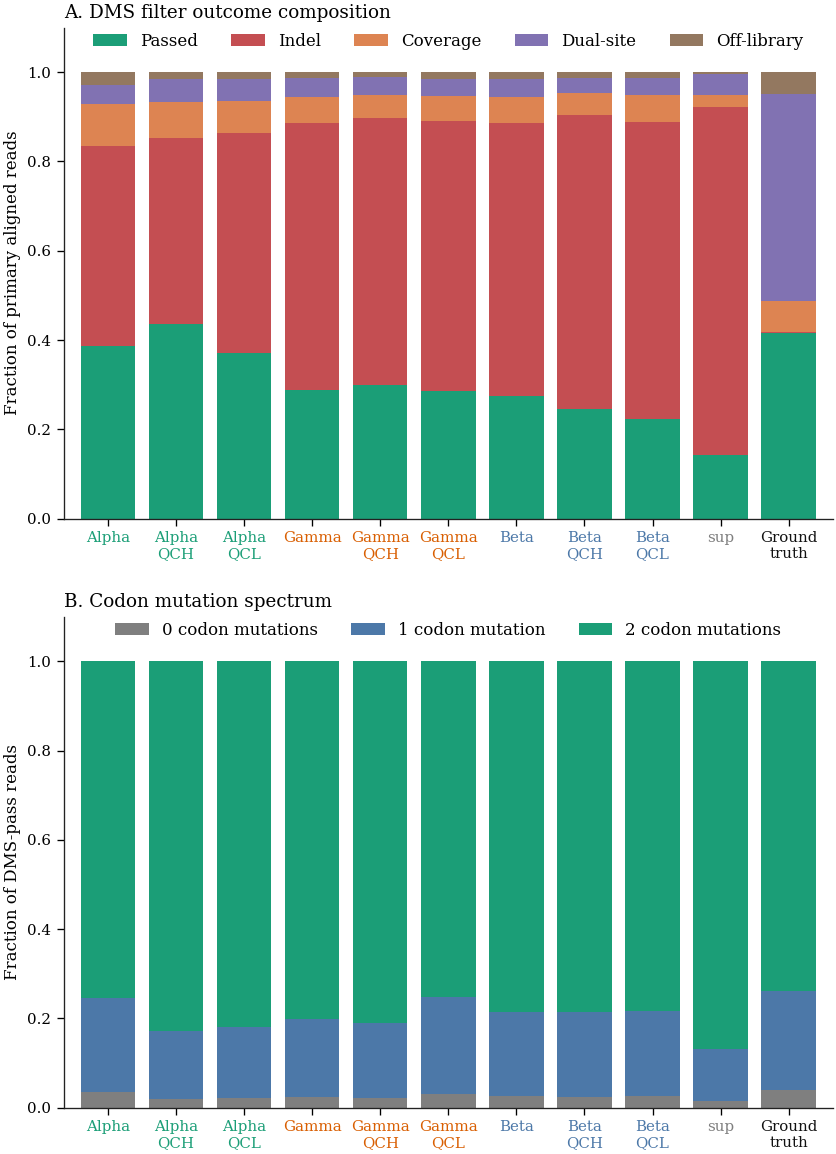

PosixPath('figures/figure_18_dms_filter_outcome_composition.svg')

In [12]:
# combine the DMS filter composition and pass-spectrum summaries into one figure
plot_3_5_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
compact_model_labels = [format_model_label(label) for label in plot_3_5_df["display_name"]]
failure_modes = plot_3_5_df.set_index("display_name")[["failed_indel", "failed_coverage", "failed_dual_site", "failed_mut_codon_library"]].div(
    plot_3_5_df.set_index("display_name")["post_alignment_filter_reads"],
    axis=0,
)
failure_modes.columns = ["Indel", "Coverage", "Dual-site", "Off-library"]
dms_filter_composition = failure_modes.copy()
dms_filter_composition.insert(
    0,
    "Passed",
    plot_3_5_df.set_index("display_name")["post_dms_filter_reads"] / plot_3_5_df.set_index("display_name")["post_alignment_filter_reads"],
)
pass_spectrum = plot_3_5_df.set_index("display_name")[["pass_reads_0_codon_mutations", "pass_reads_1_codon_mutations", "pass_reads_2_codon_mutations"]].div(
    plot_3_5_df.set_index("display_name")["post_dms_filter_reads"],
    axis=0,
)
pass_spectrum.columns = ["0 codon mutations", "1 codon mutation", "2 codon mutations"]

fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69))
dms_filter_composition.plot(
    kind="bar",
    stacked=True,
    color=["#1b9e77", "#c44e52", "#dd8452", "#8172b2", "#937860"],
    ax=axes[0],
    width=0.8,
)
axes[0].set_ylim(0.0, 1.1)
axes[0].set_title("A. DMS filter outcome composition", loc="left")
axes[0].set_ylabel("Fraction of primary aligned reads")
axes[0].set_xlabel("")
axes[0].set_xticklabels(compact_model_labels, rotation=0)
color_model_ticklabels(axes[0], axis="x")
axes[0].legend(frameon=False, title="", loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=5)

pass_spectrum.plot(
    kind="bar",
    stacked=True,
    color=["#7f7f7f", "#4c78a8", "#1b9e77"],
    ax=axes[1],
    width=0.8,
)
axes[1].set_title("B. Codon mutation spectrum", loc="left")
axes[1].set_ylim(0.0, 1.1)
axes[1].set_ylabel("Fraction of DMS-pass reads")
axes[1].set_xlabel("")
axes[1].set_xticklabels(compact_model_labels, rotation=0)
color_model_ticklabels(axes[1], axis="x")
axes[1].legend(frameon=False, title="", loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3)

#fig.subplots_adjust(top=0.96, bottom=0.07, left=0.10, right=0.98, hspace=0.40)
finalize_panel(fig, "figure_18_dms_filter_outcome_composition")

## Figure 19. Nucleotide-level & Codon-level correlation analysis. 

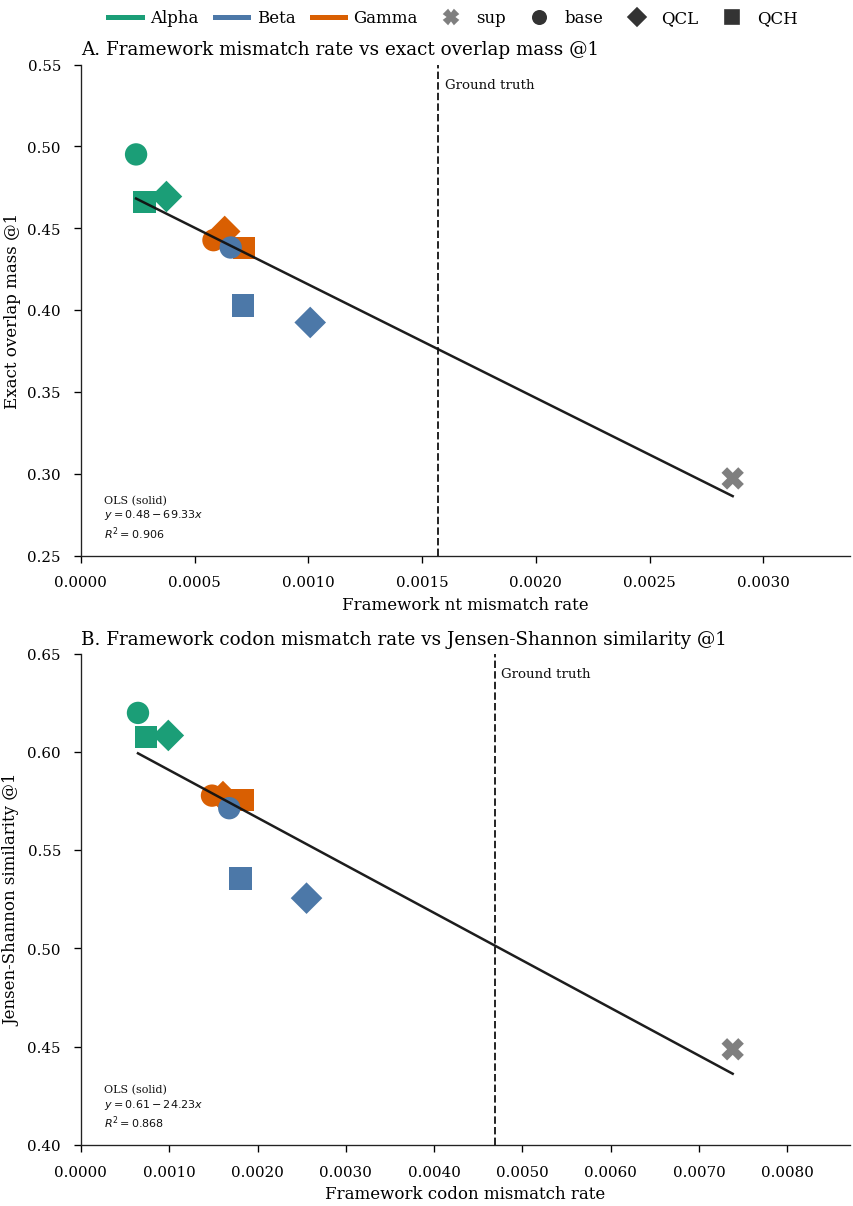

PosixPath('figures/figure_19_nucleotide_and_codon_correlation.svg')

In [13]:
# combine the framework mismatch scatter summaries into one figure
plot_3_5_df = summary_df[summary_df["display_name"].isin(DISPLAY_ORDER)].copy().sort_values("sort_order")
scatter_df = plot_3_5_df[plot_3_5_df["display_name"] != "UDP0057"].copy()
ground_truth_row = plot_3_5_df[plot_3_5_df["display_name"] == "UDP0057"].iloc[0]
family_handles, variant_handles = build_legend_handles(include_ground_truth=False, balance=False)

fig, axes = plt.subplots(2, 1, figsize=(8.27, 11.69))
scatter_specs = [
    (
        axes[0],
        "A. Framework mismatch rate vs exact overlap mass @1",
        "framework_nt_mismatch_rate_per_base",
        "exact_overlap_mass_1",
        "Framework nt mismatch rate",
        "Exact overlap mass @1",
    ),
    (
        axes[1],
        "B. Framework codon mismatch rate vs Jensen-Shannon similarity @1",
        "framework_codon_mismatch_rate_per_codon",
        "jensen_shannon_similarity_1",
        "Framework codon mismatch rate",
        "Jensen-Shannon similarity @1",
    ),
]
for ax, title, x_col, y_col, x_label, y_label in scatter_specs:
    for _, row in scatter_df.iterrows():
        ax.scatter(
            row[x_col],
            row[y_col],
            s=MODEL_MARKER_SIZE,
            color=family_color(row["family"]),
            marker=VARIANT_MARKERS[row["variant"]],
            clip_on=False,
            edgecolors="none",
        )
    x_upper = plot_3_5_df[x_col].max() * 1.18
    y_upper = scatter_df[y_col].max() * 1.03 if scatter_df[y_col].max() > 0 else 1.0
    ground_truth_x = ground_truth_row[x_col]
    add_model_ols_fit(
        ax,
        scatter_df,
        x_col=x_col,
        y_col=y_col,
        fit_color="#111111",
        text_xy=(0.03, 0.03),
        text_va="bottom",
    )
    ax.axvline(
        ground_truth_x,
        color=family_color("UDP0057"),
        linestyle="--",
        linewidth=1.2,
        alpha=0.9,
        zorder=0,
    )
    label_ha = "left" if ground_truth_x <= x_upper * 0.82 else "right"
    label_dx = 4 if label_ha == "left" else -4
    ax.annotate(
        "Ground truth",
        xy=(ground_truth_x, 0.98),
        xycoords=("data", "axes fraction"),
        xytext=(label_dx, -2),
        textcoords="offset points",
        ha=label_ha,
        va="top",
        fontsize=8,
        color=family_color("UDP0057"),
        annotation_clip=False,
    )
    ax.set_title(title, loc="left")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_xlim(0, x_upper)
    ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.4f"))
    ax.tick_params(axis="x", pad=8)
    ax.tick_params(axis="y", pad=8)
axes[0].set_ylim(0.25, 0.55) 
axes[1].set_ylim(0.4, 0.65)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=7,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.93),
    columnspacing=1.0,
    handletextpad=0.5,
)
#fig.subplots_adjust(top=0.91, bottom=0.07, left=0.11, right=0.98, hspace=0.35)
finalize_panel(fig, "figure_19_nucleotide_and_codon_correlation")


## Figure 20. Per-position level noise profiling

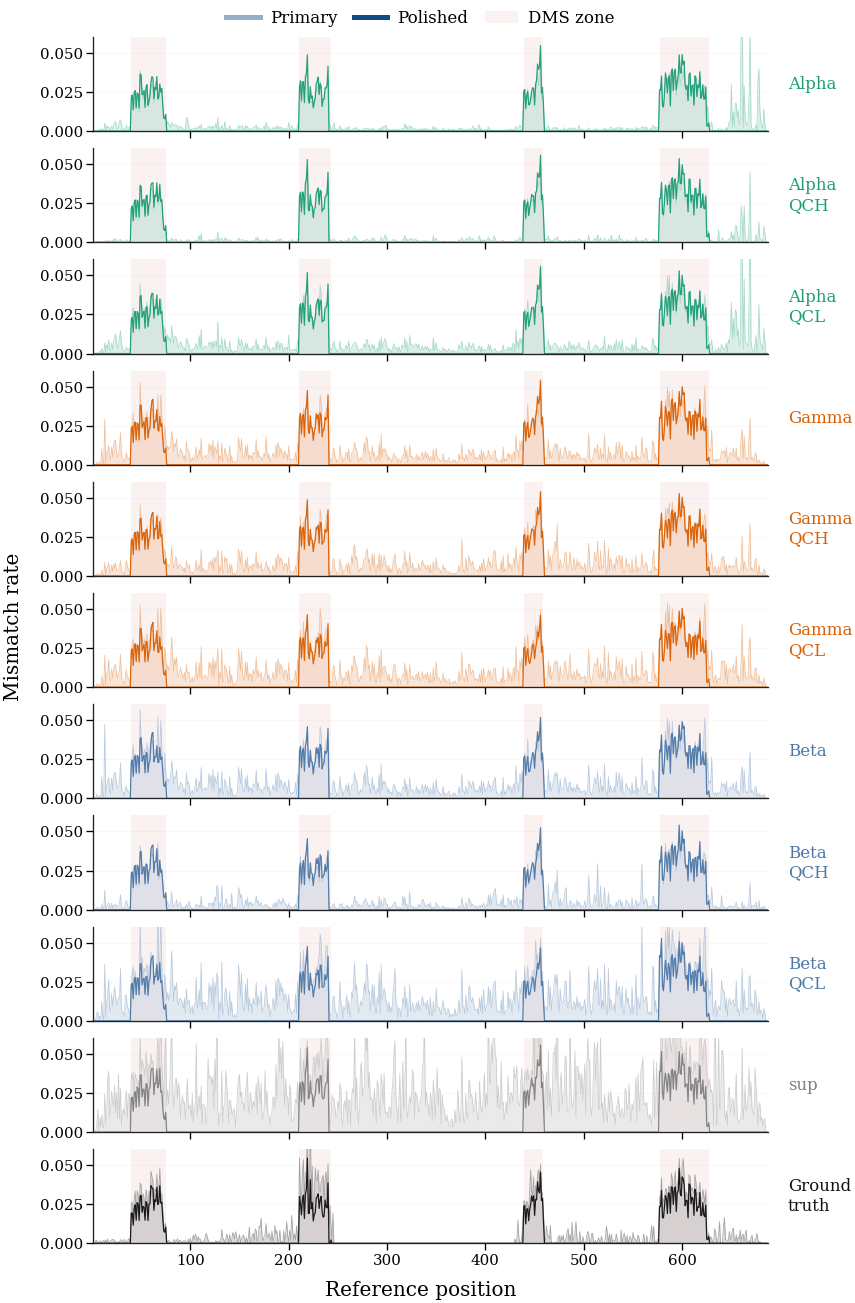

PosixPath('figures/figure_20_per_position_noise_profiles.svg')

In [14]:
# compute the primary and polished per-position mismatch profiles before drawing the stacked panel
mutation_density_models = DISPLAY_ORDER
summary_lookup = summary_df.set_index("display_name")
density_lookup = {
    (model_name, stage): compute_mutation_density(model_name, stage=stage, force=False, threads=32)
    for model_name in mutation_density_models
    for stage in ["primary", "polished"]
}
all_density_rates = pd.concat(
    [df[["mismatch_rate"]] for df in density_lookup.values() if not df.empty],
    ignore_index=True,
)
density_ymax = all_density_rates["mismatch_rate"].quantile(0.995) * 1.08 if not all_density_rates.empty else 1.0

fig, axes = plt.subplots(
    len(mutation_density_models),
    1,
    figsize=(8.27, 11.69),
    gridspec_kw={"hspace": 0.18},
    sharex=True,
    sharey=True,
)
if len(mutation_density_models) == 1:
    axes = [axes]
comparison_handles = [
    Line2D([0], [0], color=lighten_color("#0f4c81", 0.55), lw=3.0, label="Primary"),
    Line2D([0], [0], color="#0f4c81", lw=3.0, label="Polished"),
    mpl.patches.Patch(facecolor=REGION_COLORS["DMS"], alpha=0.08, label="DMS zone"),
]

for row_idx, model_name in enumerate(mutation_density_models):
    model_row = summary_lookup.loc[model_name]
    model_color = family_color(model_row["family"])
    primary_color = lighten_color(model_color, 0.55)
    ax_density = axes[row_idx]

    primary_df = density_lookup[(model_name, "primary")]
    polished_df = density_lookup[(model_name, "polished")]
    add_dms_shading(ax_density, alpha=0.08)
    ax_density.fill_between(
        primary_df["position"],
        primary_df["mismatch_rate"],
        color=primary_color,
        alpha=0.35,
        linewidth=0,
        rasterized=True,
    )
    ax_density.plot(
        primary_df["position"],
        primary_df["mismatch_rate"],
        color=primary_color,
        lw=0.45,
        alpha=0.85,
        rasterized=True,
    )
    ax_density.plot(
        polished_df["position"],
        polished_df["mismatch_rate"],
        color=model_color,
        lw=0.75,
        alpha=0.95,
        rasterized=True,
    )
    ax_density.set_xlim(1, REFERENCE_LENGTH)
    ax_density.set_ylim(0, density_ymax)
    ax_density.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax_density.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.3f"))
    ax_density.yaxis.offsetText.set_visible(False)
    ax_density.grid(True, axis="y", alpha=0.18)
    ax_density.tick_params(axis="both", pad=2)
    ax_density.text(
        1.03,
        0.5,
        format_model_label(model_name),
        transform=ax_density.transAxes,
        ha="left",
        va="center",
        color=model_color,
    )

fig.legend(
    handles=comparison_handles,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.95),
    columnspacing=1.0,
    handletextpad=0.6,
)
fig.supylabel("Mismatch rate", x=0.13)
fig.supxlabel("Reference position", x=0.55, y=0.02)
fig.subplots_adjust(top=0.92, bottom=0.06, left=0.22, right=0.90)
finalize_panel(fig, "figure_20_per_position_noise_profiles")


## Figure 21. Mutational-event level concordance. 

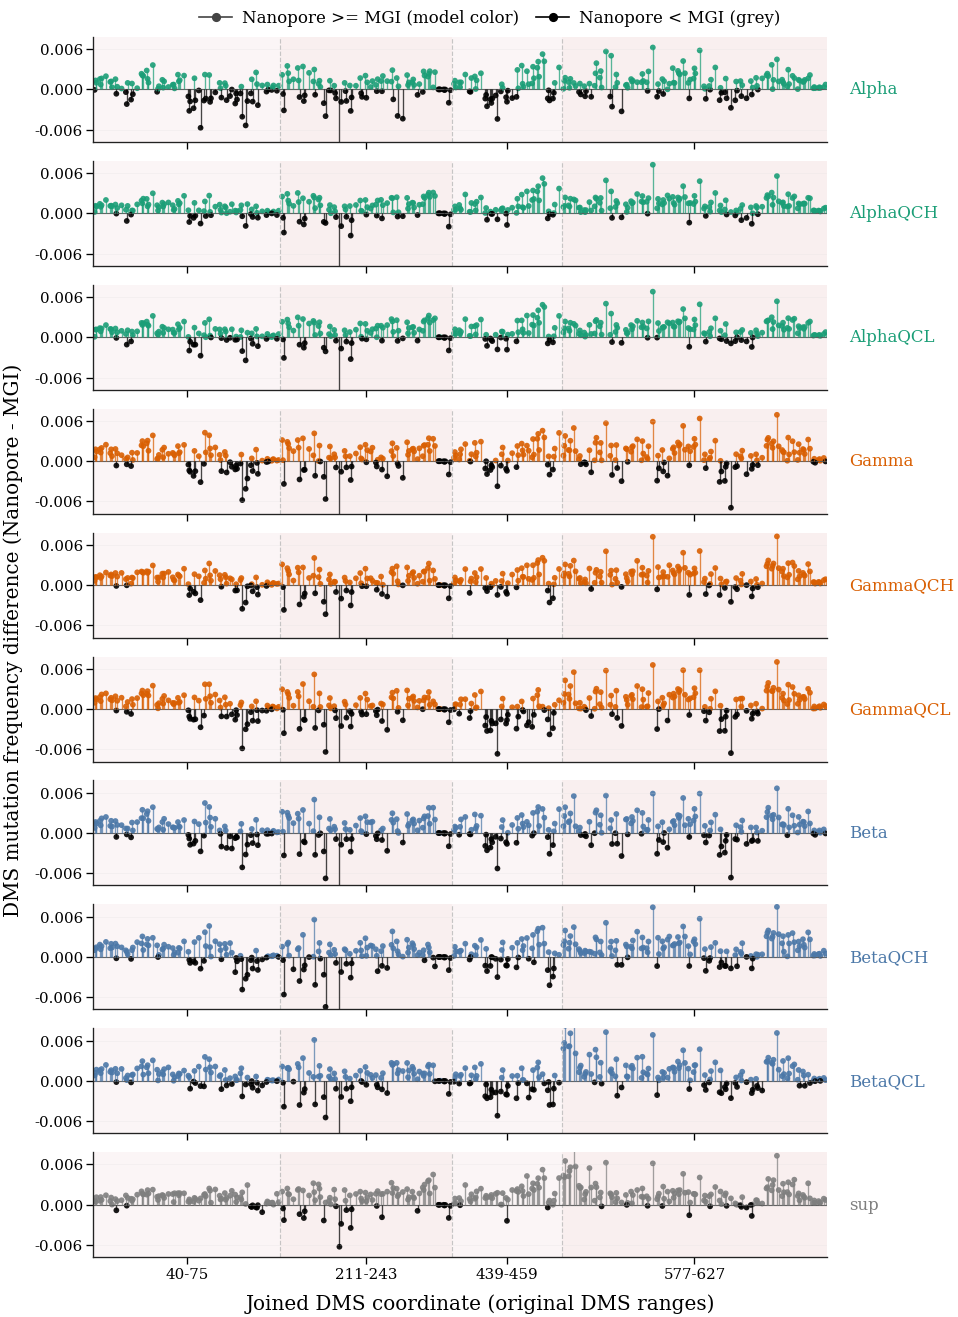

PosixPath('figures/figure_21_mutational_event_concordance.svg')

In [15]:
shared_difference_models = MODEL_ONLY_ORDER
mgi_color = "#000000"
summary_lookup = summary_df.set_index("display_name")
# build the per-mutation difference table for every Nanopore model against MGI
shared_difference_lookup = {
    model_name: build_shared_mutation_difference_data(model_name, threshold=1, dms_only=True, exclude_wt=True)
    for model_name in shared_difference_models
}
# use a shared y-limit so the rows can be compared directly across models
all_shared_differences = pd.concat(
    [df[["abs_difference"]] for df in shared_difference_lookup.values() if not df.empty],
    ignore_index=True,
)
shared_difference_ymax = all_shared_differences["abs_difference"].quantile(0.995) * 1.08 if not all_shared_differences.empty else 1.0

fig, axes = plt.subplots(
    len(shared_difference_models),
    1,
    figsize=(8.27, 11.69),
    gridspec_kw={"hspace": 0.18},
    sharex=True,
    sharey=True,
)
if len(shared_difference_models) == 1:
    axes = [axes]
difference_handles = [
    Line2D([0], [0], color="#444444", marker="o", lw=1.0, ms=4.5, label="Nanopore >= MGI (model color)"),
    Line2D([0], [0], color=mgi_color, marker="o", lw=1.0, ms=4.5, label="Nanopore < MGI (grey)"),
]

for row_idx, model_name in enumerate(shared_difference_models):
    model_row = summary_lookup.loc[model_name]
    model_color = family_color(model_row["family"])
    ax = axes[row_idx]
    diff_df = shared_difference_lookup[model_name].copy()
    # shade the three DMS blocks and draw separators between them
    for seg_idx, segment in enumerate(JOINED_DMS_SEGMENTS):
        ax.axvspan(
            segment["joined_start"] - 0.5,
            segment["joined_end"] + 0.5,
            color=REGION_COLORS["DMS"],
            alpha=0.05 if seg_idx % 2 == 0 else 0.09,
            lw=0,
        )
        if seg_idx > 0:
            ax.axvline(segment["joined_start"] - 0.5, color="#bdbdbd", ls="--", lw=0.7, alpha=0.85)
    # the zero line shows perfect agreement with MGI
    ax.axhline(0.0, color="#555555", lw=0.7, alpha=0.9)

    if not diff_df.empty:
        diff_df = diff_df.sort_values(["joined_position", "mutation_token"]).reset_index(drop=True)
        # spread mutation tokens slightly when multiple events share the same DMS coordinate
        diff_df["event_rank"] = diff_df.groupby("joined_position").cumcount()
        diff_df["event_count"] = diff_df.groupby("joined_position")["mutation_token"].transform("size")
        diff_df["plot_position"] = diff_df["joined_position"]
        multi_event_mask = diff_df["event_count"] > 1
        diff_df.loc[multi_event_mask, "plot_position"] = diff_df.loc[multi_event_mask, "joined_position"] + (
            (diff_df.loc[multi_event_mask, "event_rank"] / (diff_df.loc[multi_event_mask, "event_count"] - 1)) - 0.5
        ) * 0.34
        # use the model family color for positive differences and grey for negative differences
        diff_df["stem_color"] = np.where(diff_df["frequency_difference"] >= 0, model_color, mgi_color)
        for color, subset in diff_df.groupby("stem_color", sort=False):
            ax.vlines(
                subset["plot_position"],
                0.0,
                subset["frequency_difference"],
                color=color,
                lw=0.8,
                alpha=0.72,
                rasterized=True,
            )
            ax.scatter(
                subset["plot_position"],
                subset["frequency_difference"],
                color=color,
                s=12,
                alpha=0.9,
                edgecolors="none",
                rasterized=True,
            )

    ax.set_xlim(0.5, JOINED_DMS_LENGTH + 0.5)
    ax.set_ylim(-shared_difference_ymax, shared_difference_ymax)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.3f"))
    ax.grid(True, axis="y", alpha=0.18)
    ax.tick_params(axis="both", pad=2)
    ax.text(
        1.03,
        0.5,
        model_name,
        transform=ax.transAxes,
        ha="left",
        va="center",
        color=model_color,
    )
    if row_idx != len(shared_difference_models) - 1:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xticks([segment["joined_mid"] for segment in JOINED_DMS_SEGMENTS])
        ax.set_xticklabels([f"{segment['start']}-{segment['end']}" for segment in JOINED_DMS_SEGMENTS])

fig.legend(
    handles=difference_handles,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.56, 0.96),
    columnspacing=1.0,
    handletextpad=0.6,
)
fig.supylabel("DMS mutation frequency difference (Nanopore - MGI)", x=0.07)
fig.supxlabel("Joined DMS coordinate (original DMS ranges)", x=0.55, y=0.02)
fig.subplots_adjust(top=0.93, bottom=0.06, left=0.16, right=0.90)
finalize_panel(fig, "figure_21_mutational_event_concordance")


## Figure 22. Weighted Jaccard concordance ranking at minimum count threshold 1. 


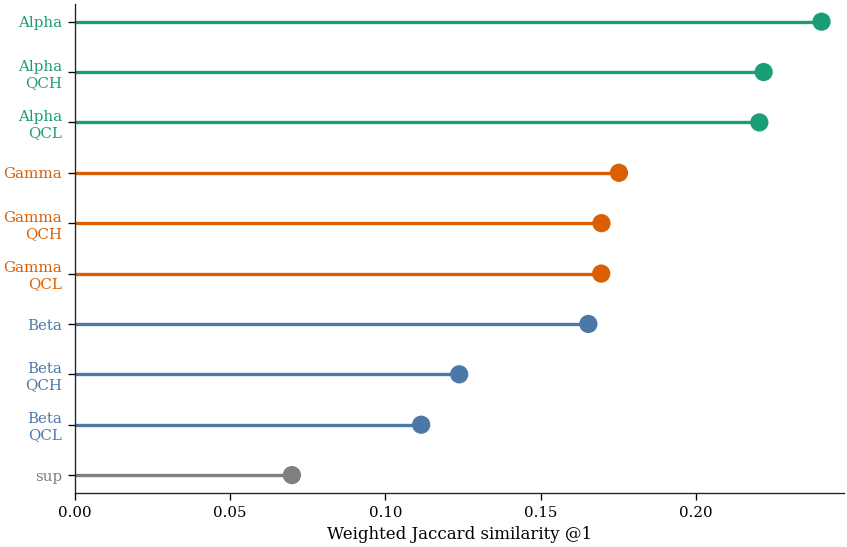

PosixPath('figures/figure_22_weighted_jaccard_ranking.svg')

In [16]:
# rank all test entries by weighted-Jaccard similarity at threshold 1
threshold_1_rank = correlation_df[correlation_df["display_name"] != "UDP0057"].copy().sort_values("weighted_jaccard_1", ascending=True)
fig, ax = plt.subplots(figsize=(8.27, 5.3))
ax.hlines(
    threshold_1_rank["display_name"],
    xmin=0,
    xmax=threshold_1_rank["weighted_jaccard_1"],
    color=[family_color(fam) for fam in threshold_1_rank["family"]],
    lw=2,
)
ax.scatter(
    threshold_1_rank["weighted_jaccard_1"],
    threshold_1_rank["display_name"],
    s=RANK_MARKER_SIZE,
    color=[family_color(fam) for fam in threshold_1_rank["family"]],
    edgecolors="none",
    rasterized=True,
)
weighted_jaccard_max = threshold_1_rank["weighted_jaccard_1"].max()
ax.set_xlim(0, weighted_jaccard_max * 1.03)
ax.set_xlabel("Weighted Jaccard similarity @1")
ax.set_ylabel("")
ax.margins(y=0.04)
color_model_ticklabels(ax, axis="y")
finalize_panel(fig, "figure_22_weighted_jaccard_ranking")


## Figure 23. Abundance concordance for intersecting variants. 

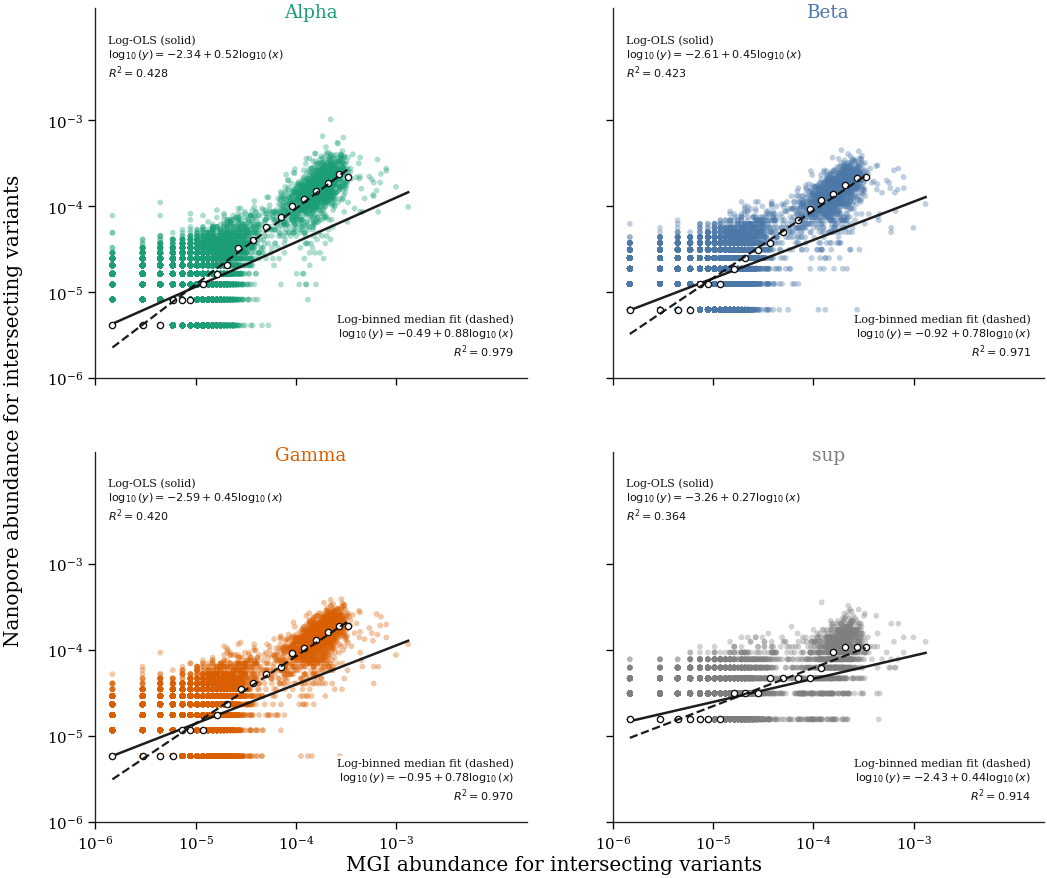

PosixPath('figures/figure_23_abundance_concordance_intersecting_variants.svg')

In [17]:
# draw the four main model-vs-MGI abundance panels on shared log-scaled axes
scatter_models = ["Alpha", "Beta", "Gamma", "sup"]
shared_variant_df = build_shared_variant_scatter(scatter_models, threshold=1, exclude_wt=True)
scatter_lower, scatter_upper, scatter_ticks = compute_shared_variant_scatter_axis(shared_variant_df)

fig, axes = plt.subplots(2, 2, figsize=(10.2, 8.8), sharex=True, sharey=True)
for plot_idx, (ax, model_name) in enumerate(zip(axes.flat, scatter_models)):
    subset = shared_variant_df[shared_variant_df["display_name"] == model_name].copy()
    draw_shared_variant_scatter_panel(
        ax,
        subset,
        model_name=model_name,
        lower=scatter_lower,
        upper=scatter_upper,
        ticks=scatter_ticks,
        title=format_model_label(model_name),
        x_label="",
        y_label="",
    )
    if plot_idx < 2:
        ax.tick_params(labelbottom=False)
    if plot_idx % 2 == 1:
        ax.tick_params(labelleft=False)
fig.supxlabel("MGI abundance for intersecting variants", y=0.06)
fig.supylabel("Nanopore abundance for intersecting variants", x=0.05)
finalize_panel(fig, "figure_23_abundance_concordance_intersecting_variants")


## Figure 24. Intersecting variants versus retained variant count


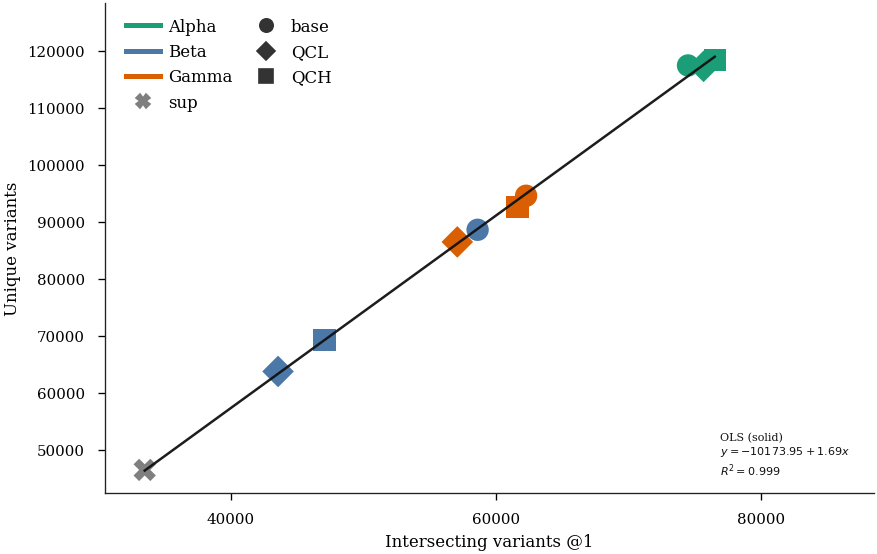

PosixPath('figures/figure_24_intersecting_vs_retained_variants.svg')

In [18]:
# compare retained variant diversity against intersecting-variant count for each model
plot_df = model_summary_df[model_summary_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
family_handles, variant_handles = build_legend_handles(include_ground_truth=False)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
for _, row in plot_df.iterrows():
    ax.scatter(
        row["intersection_variants_1"],
        row["unique_variants"],
        s=MODEL_MARKER_SIZE,
        color=family_color(row["family"]),
        marker=VARIANT_MARKERS[row["variant"]],
        edgecolors="none",
    )
add_model_ols_fit(
    ax,
    plot_df,
    x_col="intersection_variants_1",
    y_col="unique_variants",
    fit_color="#111111",
    text_xy=(0.80, 0.03),
    text_va="bottom",
)

ax.set_xlabel("Intersecting variants @1")
ax.set_ylabel("Unique variants")
ax.set_xlim(plot_df["intersection_variants_1"].min() - 3000, plot_df["intersection_variants_1"].max() + 12000)
ax.set_ylim(plot_df["unique_variants"].min() - 4000, plot_df["unique_variants"].max() + 10000)
ax.set_xticks([40000, 60000, 80000])
ax.tick_params(axis="x", pad=8)
ax.tick_params(axis="y", pad=8)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.25, 0.88),
    columnspacing=1.0,
    handletextpad=0.5,
)
finalize_panel(fig, "figure_24_intersecting_vs_retained_variants")


## Figure 25. Threshold-robustness curves across nanopore models. 

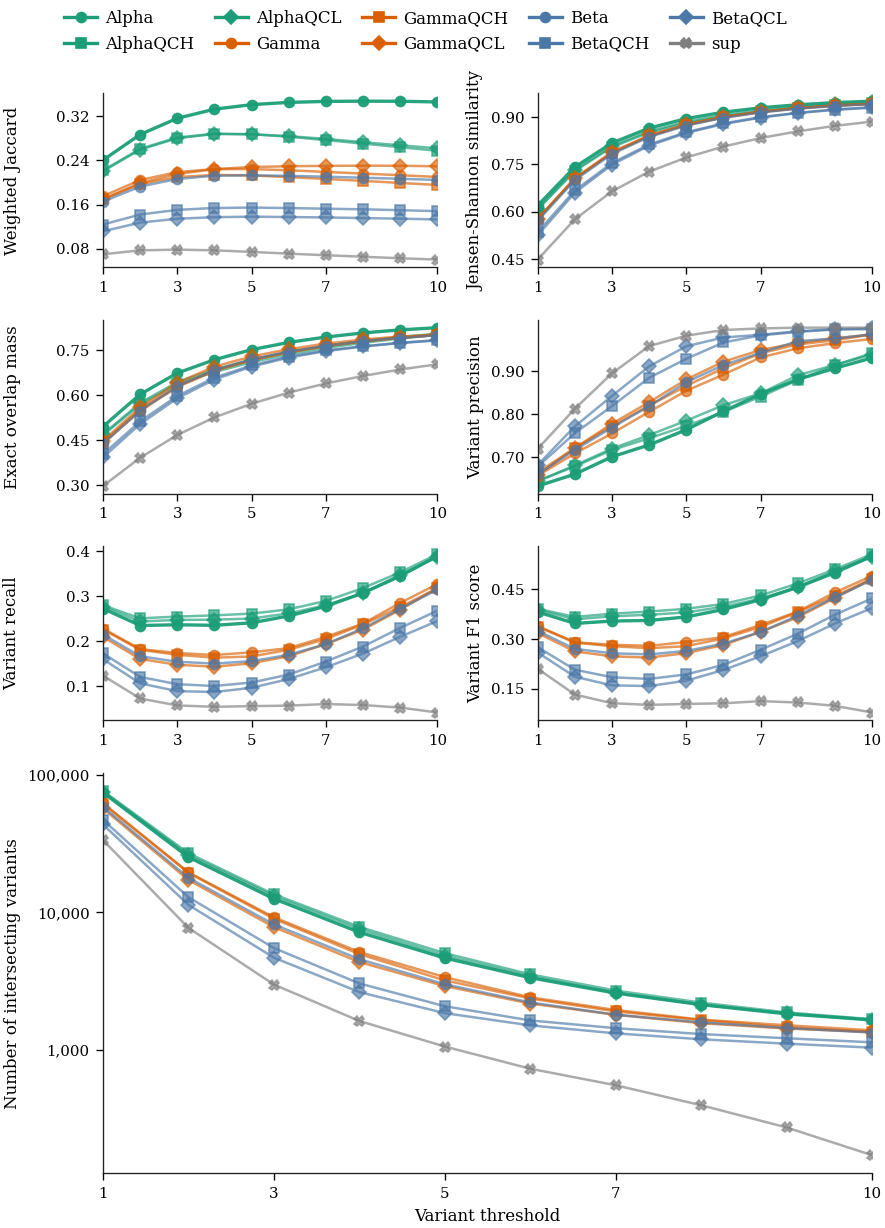

PosixPath('figures/figure_25_threshold_robustness_curves.svg')

In [19]:
# combine the threshold-sweep panels into one appendix composite figure
robustness_df = threshold_long_df[threshold_long_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
model_lookup = model_summary_df.set_index("display_name")
legend_handles = build_threshold_robustness_legend_handles(model_lookup)

panel_specs = [
    ("weighted_jaccard", "Weighted Jaccard", (0, 0)),
    ("jensen_shannon_similarity", "Jensen-Shannon similarity", (0, 1)),
    ("exact_overlap_mass", "Exact overlap mass", (1, 0)),
    ("precision", "Variant precision", (1, 1)),
    ("recall", "Variant recall", (2, 0)),
    ("f1", "Variant F1 score", (2, 1)),
]

fig = plt.figure(figsize=(8.27, 11.69))
grid = fig.add_gridspec(5, 2, wspace=0.3, hspace=0.3)
shared_threshold_ax = fig.add_subplot(grid[0, 0])
panel_axes = {"weighted_jaccard": shared_threshold_ax}

for metric, y_label, (row_idx, col_idx) in panel_specs:
    if metric != "weighted_jaccard":
        panel_axes[metric] = fig.add_subplot(grid[row_idx, col_idx], sharex=shared_threshold_ax)
    draw_threshold_robustness_panel(
        panel_axes[metric],
        robustness_df,
        model_lookup,
        metric=metric,
        label=y_label,
    )
    panel_axes[metric].set_xlabel("")
    panel_axes[metric].tick_params(labelbottom=True)

panel_axes["intersection_variants"] = fig.add_subplot(grid[3:,0:])
draw_threshold_robustness_panel(
    panel_axes["intersection_variants"],
    robustness_df,
    model_lookup,
    metric="intersection_variants",
    label="Number of intersecting variants",
)

fig.align_ylabels(
    [
        panel_axes["weighted_jaccard"],
        panel_axes["jensen_shannon_similarity"],
        panel_axes["exact_overlap_mass"],
        panel_axes["precision"],
        panel_axes["recall"],
        panel_axes["f1"],
        panel_axes["intersection_variants"],
    ]
)
fig.legend(
    handles=legend_handles,
    frameon=False,
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.45, 0.95),
    columnspacing=1.2,
    handletextpad=0.5,
)
finalize_panel(fig, "figure_25_threshold_robustness_curves")


## Figure 26 & Figure 27 & Figure 28. Component-level analysis 


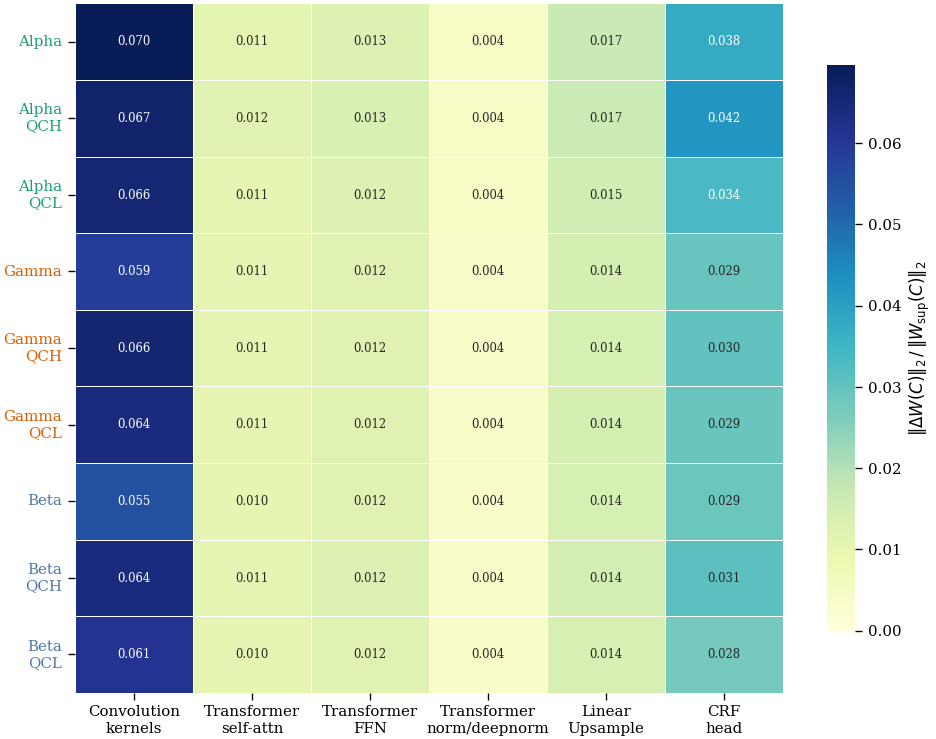

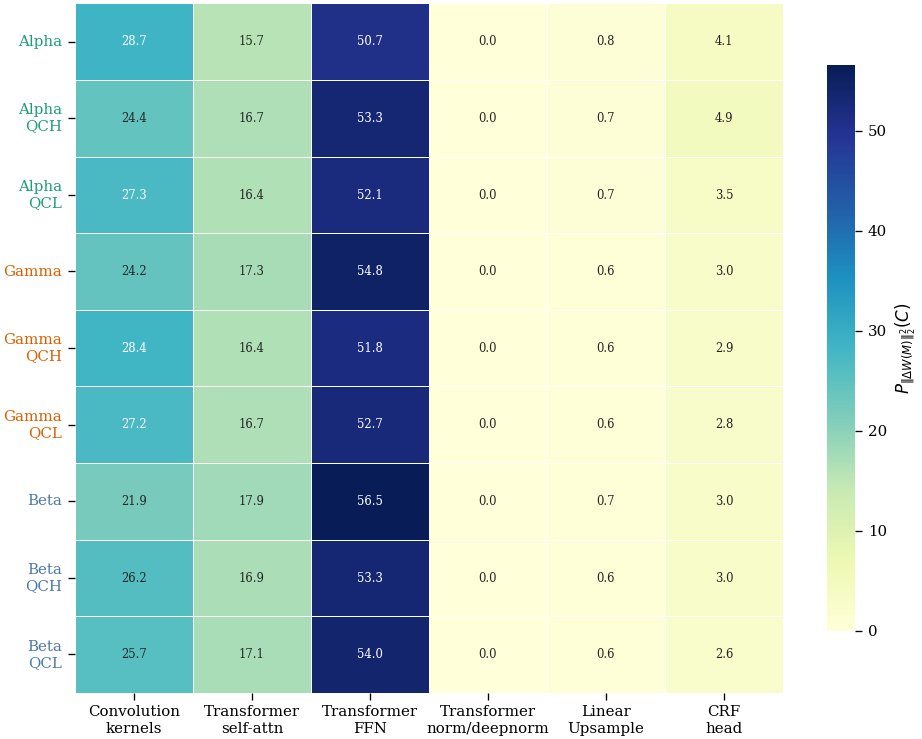

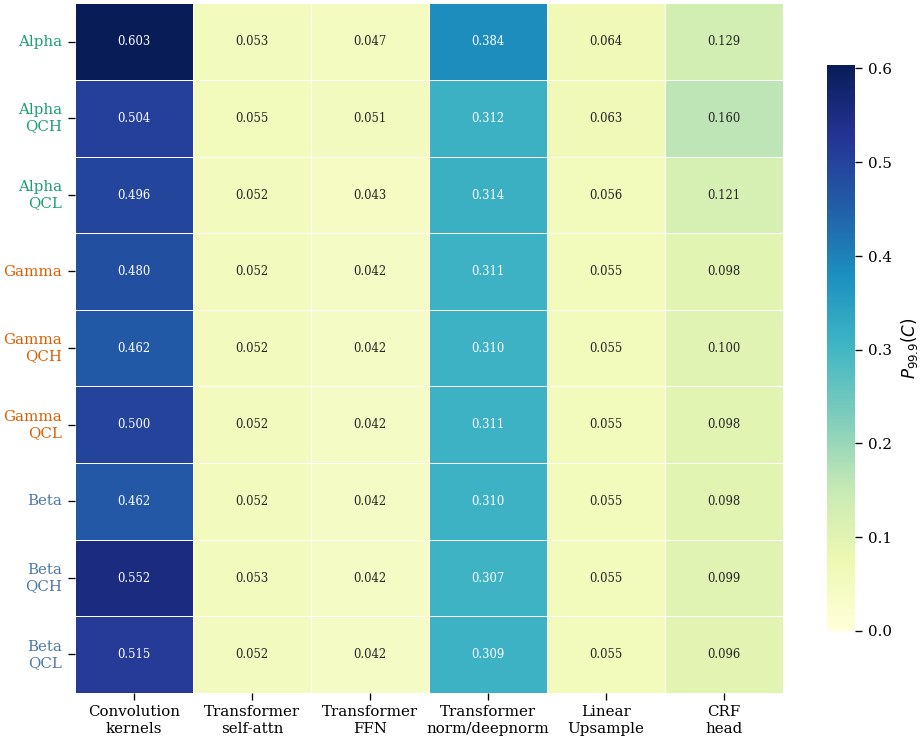

PosixPath('figures/figure_28_weight_delta_stability.svg')

In [20]:

# load compact weight-drift tables produced by src/python/weight_stats.py
WEIGHTS_DIR = TABLES_DIR / "weights"
WEIGHT_REQUIRED_TABLES = {
    "component": WEIGHTS_DIR / "weight_component_stats.csv",
    "histogram": WEIGHTS_DIR / "weight_delta_histogram.csv",
    "model_summary": WEIGHTS_DIR / "weight_model_summary.csv",
    "layer": WEIGHTS_DIR / "weight_layer_stats.csv",
}
missing_weight_tables = [path for path in WEIGHT_REQUIRED_TABLES.values() if not path.exists()]
if missing_weight_tables:
    missing_text = ", ".join(str(path.relative_to(REPO_ROOT)) for path in missing_weight_tables)
    raise FileNotFoundError(
        "Missing weight-drift tables. Run src/python/weight_stats.py before plotting: " + missing_text
    )

weight_component_df = coerce_numeric(pd.read_csv(WEIGHT_REQUIRED_TABLES["component"]))
weight_histogram_df = coerce_numeric(pd.read_csv(WEIGHT_REQUIRED_TABLES["histogram"]))
weight_model_summary_df = coerce_numeric(pd.read_csv(WEIGHT_REQUIRED_TABLES["model_summary"]))
weight_layer_df = coerce_numeric(pd.read_csv(WEIGHT_REQUIRED_TABLES["layer"]))

WEIGHT_COMPONENT_ORDER = [
    "conv",
    "transformer_self_attn",
    "transformer_ffn",
    "transformer_norm_deepnorm",
    "upsample",
    "crf",
]
WEIGHT_COMPONENT_SHORT_LABELS = {
    "conv": "Convolution\nkernels",
    "transformer_self_attn": "Transformer\nself-attn",
    "transformer_ffn": "Transformer\nFFN",
    "transformer_norm_deepnorm": "Transformer\nnorm/deepnorm",
    "upsample": "Linear\nUpsample",
    "crf": "CRF\nhead",
}
WEIGHT_REPRESENTATIVE_MODELS = ["Alpha", "AlphaQCH", "Beta", "Gamma"]
WEIGHT_TAIL_COL = "tail_abs_delta_z_gt_3p0_fraction"
WEIGHT_P999_COL = "p999_abs_delta_z_approx"


def prepare_weight_component_matrix(
    component_df: pd.DataFrame,
    *,
    value_col: str,
    model_order: list[str] | None = None,
) -> pd.DataFrame:
    selected_order = model_order or MODEL_ONLY_ORDER
    plot_df = component_df[
        component_df["name"].isin(selected_order) & component_df["component"].isin(WEIGHT_COMPONENT_ORDER)
    ].copy()
    plot_df["component_short"] = plot_df["component"].map(WEIGHT_COMPONENT_SHORT_LABELS)
    matrix = plot_df.pivot(index="name", columns="component_short", values=value_col)
    column_order = [WEIGHT_COMPONENT_SHORT_LABELS[component] for component in WEIGHT_COMPONENT_ORDER]
    return matrix.reindex(index=[name for name in selected_order if name in matrix.index], columns=column_order)


def draw_weight_component_heatmap(
    ax: plt.Axes,
    matrix: pd.DataFrame,
    *,
    cbar_label: str,
    cmap: str,
    fmt: str,
    annotation_scale: float = 1.0,
) -> None:
    annot_kws = {"fontsize": 7 * annotation_scale}
    sns.heatmap(
        matrix,
        ax=ax,
        cmap=cmap,
        annot=True,
        fmt=fmt,
        linewidths=0.6,
        vmin=0,
        cbar_kws={"label": cbar_label, "shrink": 0.82},
        annot_kws=annot_kws,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=0)
    color_model_ticklabels(ax, axis="y")


relative_l2_matrix = prepare_weight_component_matrix(weight_component_df, value_col="relative_l2")
delta_share_matrix = prepare_weight_component_matrix(weight_component_df, value_col="delta_energy_share") * 100

component_drift_panels = [
    {
        "matrix": relative_l2_matrix,
        "title": "Relative L2 drift from pretrained sup",
        "cbar_label": r"$\|\Delta W(C)\|_2 \,/\, \|W_{\mathrm{sup}}(C)\|_2$",
        "cmap": "YlGnBu",
        "fmt": ".3f",
        "output_filename": "figure_26_weight_component_relative_l2_drift",
    },
    {
        "matrix": delta_share_matrix,
        "title": "Share of total delta energy",
        "cbar_label": r"$P_{\|\Delta W(M)\|_2^2}(C)$",
        "cmap": "YlGnBu",
        "fmt": ".1f",
        "output_filename": "figure_27_weight_component_delta_energy_share",
    },
]

for panel in component_drift_panels:
    fig, ax = plt.subplots(figsize=(8.27, 6.4))
    draw_weight_component_heatmap(
        ax,
        panel["matrix"],
        cbar_label=panel["cbar_label"],
        cmap=panel["cmap"],
        fmt=panel["fmt"],
    )
    fig.tight_layout()
    finalize_panel(fig, panel["output_filename"])

# focus the main stability view on component-level tail behaviour across all current models
p999_all_matrix = prepare_weight_component_matrix(weight_component_df, value_col=WEIGHT_P999_COL)
fig, ax = plt.subplots(figsize=(8.27, 6.4))
draw_weight_component_heatmap(
    ax,
    p999_all_matrix,
    cbar_label=r"$P_{99.9}(C)$",
    cmap="YlGnBu",
    fmt=".3f",
)
fig.tight_layout()
finalize_panel(fig, "figure_28_weight_delta_stability")

## Figure 29. Transformer-depth weight drift heatmap


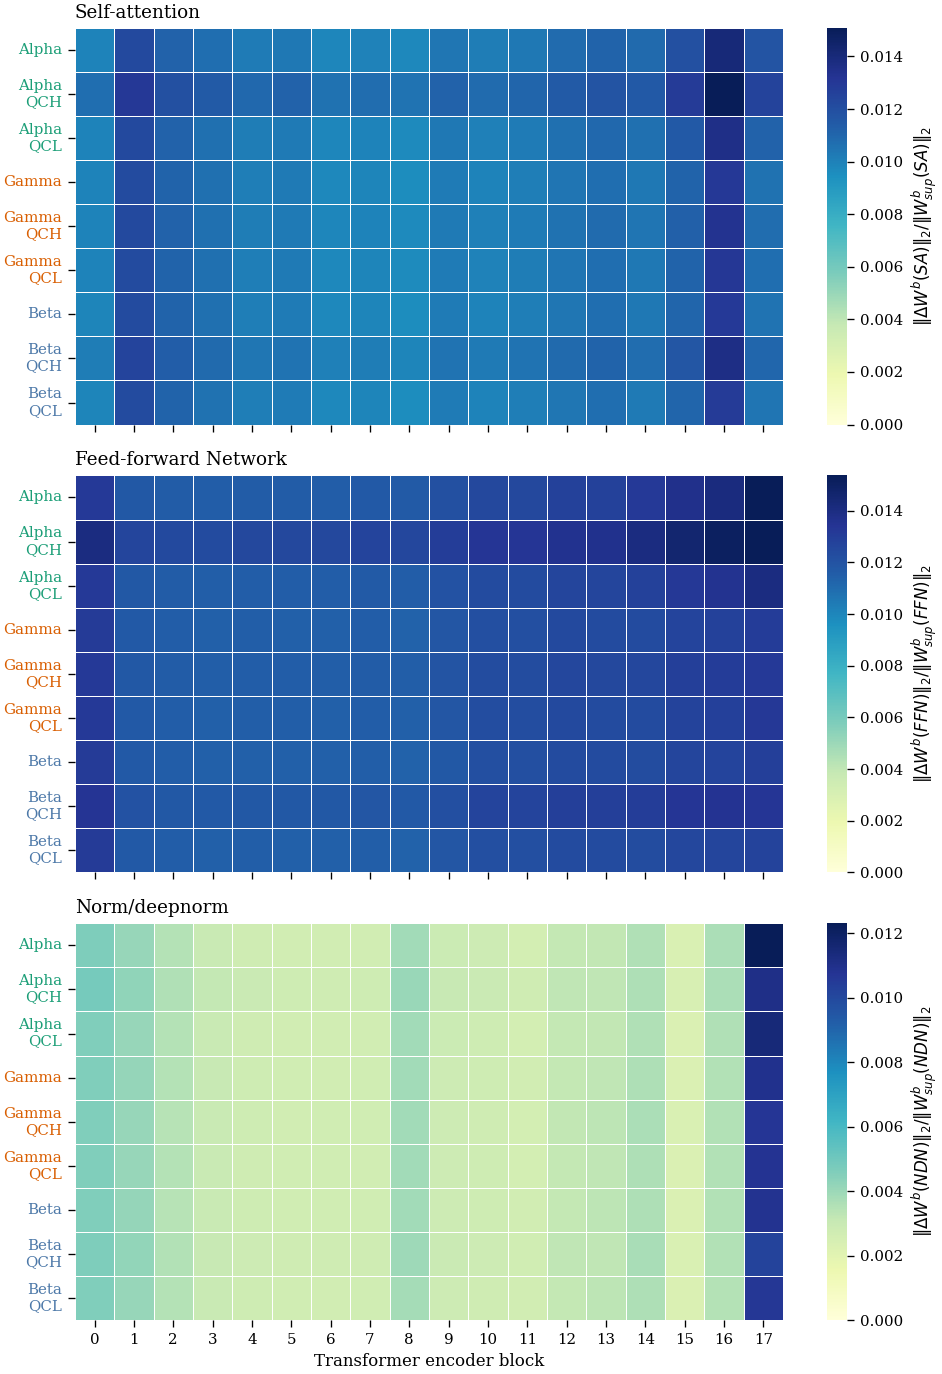

PosixPath('figures/figure_29_transformer_weight_drift_by_layer.svg')

In [21]:
# view of transformer adaptation across depth and submodule class
transformer_layer_df = weight_layer_df[
    weight_layer_df["submodule_group"].isin(["Self-attention", "Feed-forward", "Norm/deepnorm"])
    & weight_layer_df["name"].isin(MODEL_ONLY_ORDER)
].copy()
submodule_groups = ["Self-attention", "Feed-forward", "Norm/deepnorm"]
submodule_display_labels = {
    "Self-attention": "Self-attention",
    "Feed-forward": "Feed-forward Network",
    "Norm/deepnorm": "Norm/deepnorm",
}
submodule_math_labels = {
    "Self-attention": "SA",
    "Feed-forward": "FFN",
    "Norm/deepnorm": "NDN",
}
fig, axes = plt.subplots(len(submodule_groups), 1, figsize=(8.27, 11.69), sharex=True)
for ax, submodule_group in zip(axes, submodule_groups, strict=True):
    group_df = transformer_layer_df[transformer_layer_df["submodule_group"] == submodule_group].copy()
    matrix = group_df.pivot(index="name", columns="layer", values="relative_l2")
    matrix = matrix.reindex(index=[name for name in MODEL_ONLY_ORDER if name in matrix.index], columns=list(range(18)))
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="YlGnBu",
        linewidths=0.4,
        linecolor="white",
        vmin=0,
        cbar_kws={
            "label": rf"$\|\Delta W^b({submodule_math_labels[submodule_group]})\|_2 / \|W^b_{{sup}}({submodule_math_labels[submodule_group]})\|_2$"
        },
    )
    ax.set_title(submodule_display_labels[submodule_group], loc="left", pad=6)
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelrotation=0)
    color_model_ticklabels(ax, axis="y")
axes[-1].set_xlabel("Transformer encoder block")
for ax in axes[:-1]:
    ax.set_xlabel("")
fig.tight_layout(h_pad=1.1)
finalize_panel(fig, "figure_29_transformer_weight_drift_by_layer")


## Figure 30. Weight drift vs biological performance


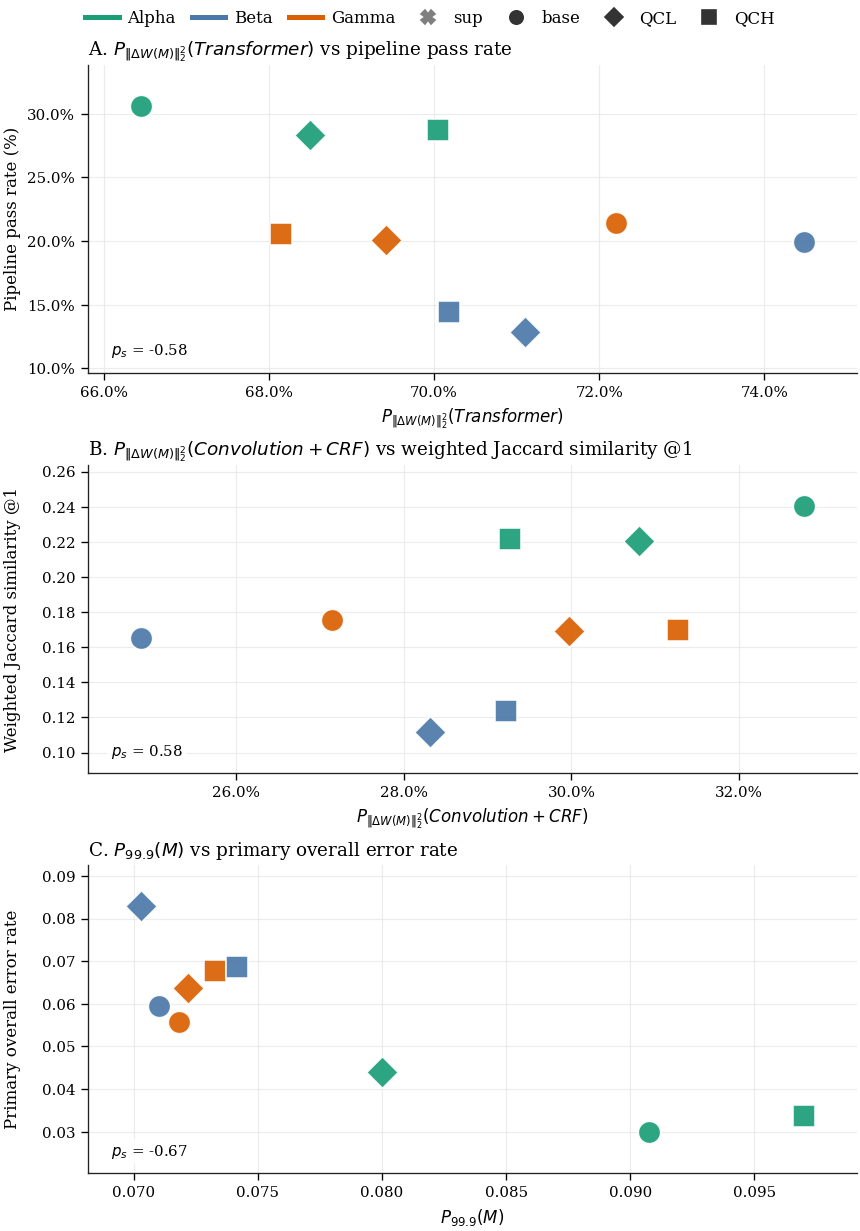

PosixPath('figures/figure_30_weight_drift_vs_performance.svg')

In [22]:

# link the exploratory weight diagnostics back to downstream biological metrics
weight_performance_df = (
    weight_model_summary_df[
        [
            "display_name",
            "family",
            "variant",
            "relative_l2",
            "transformer_self_attn_delta_energy_share",
            "transformer_ffn_delta_energy_share",
            "transformer_norm_deepnorm_delta_energy_share",
            "conv_crf_delta_energy_share",
            WEIGHT_P999_COL,
        ]
    ]
    .merge(
        summary_df[["display_name", "pipeline_pass_rate", "weighted_jaccard_1", "primary_overall_error_rate"]],
        on="display_name",
        how="left",
    )
)
weight_performance_df = weight_performance_df[weight_performance_df["display_name"].isin(MODEL_ONLY_ORDER)].copy()
weight_performance_df["transformer_delta_energy_share"] = weight_performance_df[
    [
        "transformer_self_attn_delta_energy_share",
        "transformer_ffn_delta_energy_share",
        "transformer_norm_deepnorm_delta_energy_share",
    ]
].sum(axis=1)


def spearman_rho(x: pd.Series, y: pd.Series) -> float:
    corr_df = pd.DataFrame({"x": pd.to_numeric(x, errors="coerce"), "y": pd.to_numeric(y, errors="coerce")})
    corr_df = corr_df.replace([np.inf, -np.inf], np.nan).dropna()
    if len(corr_df) < 2:
        return float("nan")
    return float(corr_df["x"].rank().corr(corr_df["y"].rank()))


def draw_weight_performance_scatter(
    ax: plt.Axes,
    plot_df: pd.DataFrame,
    *,
    x_col: str,
    y_col: str,
    title: str,
    x_label: str,
    y_label: str,
    x_formatter: mpl.ticker.Formatter | None = None,
    y_formatter: mpl.ticker.Formatter | None = None,
) -> None:
    for _, row in plot_df.iterrows():
        ax.scatter(
            row[x_col],
            row[y_col],
            s=MODEL_MARKER_SIZE,
            color=family_color(row["family"]),
            marker=VARIANT_MARKERS.get(row["variant"], "o"),
            alpha=0.92,
            edgecolor="white",
            linewidth=1.0,
            zorder=3,
        )
    rho = spearman_rho(plot_df[x_col], plot_df[y_col])
    ax.text(
        0.03,
        0.1,
        rf"$p_s$ = {rho:.2f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.84, "boxstyle": "round,pad=0.25"},
    )
    ax.set_title(title, loc="left")
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    if x_formatter is not None:
        ax.xaxis.set_major_formatter(x_formatter)
    if y_formatter is not None:
        ax.yaxis.set_major_formatter(y_formatter)
    ax.grid(axis="both", color="#e4e4e4", linewidth=0.7)
    ax.margins(x=0.08, y=0.18)


fig, axes = plt.subplots(3, 1, figsize=(8.27, 11.69))
draw_weight_performance_scatter(
    axes[0],
    weight_performance_df,
    x_col="transformer_delta_energy_share",
    y_col="pipeline_pass_rate",
    title=r"A. $P_{\|\Delta W(M)\|_2^2}(Transformer)$ vs pipeline pass rate",
    x_label=r"$P_{\|\Delta W(M)\|_2^2}(Transformer)$",
    y_label="Pipeline pass rate (%)",
    x_formatter=PercentFormatter(xmax=1.0),
    y_formatter=PercentFormatter(xmax=1.0),
)
draw_weight_performance_scatter(
    axes[1],
    weight_performance_df,
    x_col="conv_crf_delta_energy_share",
    y_col="weighted_jaccard_1",
    title=r"B. $P_{\|\Delta W(M)\|_2^2}(Convolution + CRF)$ vs weighted Jaccard similarity @1",
    x_label=r"$P_{\|\Delta W(M)\|_2^2}(Convolution + CRF)$",
    y_label="Weighted Jaccard similarity @1",
    x_formatter=PercentFormatter(xmax=1.0),
)
draw_weight_performance_scatter(
    axes[2],
    weight_performance_df,
    x_col=WEIGHT_P999_COL,
    y_col="primary_overall_error_rate",
    title=r"C. $P_{99.9}(M)$ vs primary overall error rate",
    x_label=r"$P_{99.9}(M)$",
    y_label="Primary overall error rate",
)
family_handles, variant_handles = build_legend_handles(include_sup=True, include_ground_truth=False, balance=False)
fig.legend(
    handles=family_handles + variant_handles,
    frameon=False,
    ncol=7,
    loc="upper center",
    bbox_to_anchor=(0.47, 0.95),
    columnspacing=1,
    handletextpad=0.5,
)
fig.align_ylabels(axes)
fig.subplots_adjust(top=0.90, hspace=0.30)
finalize_panel(fig, "figure_30_weight_drift_vs_performance")


## Figure 31. Composite concordance ranking

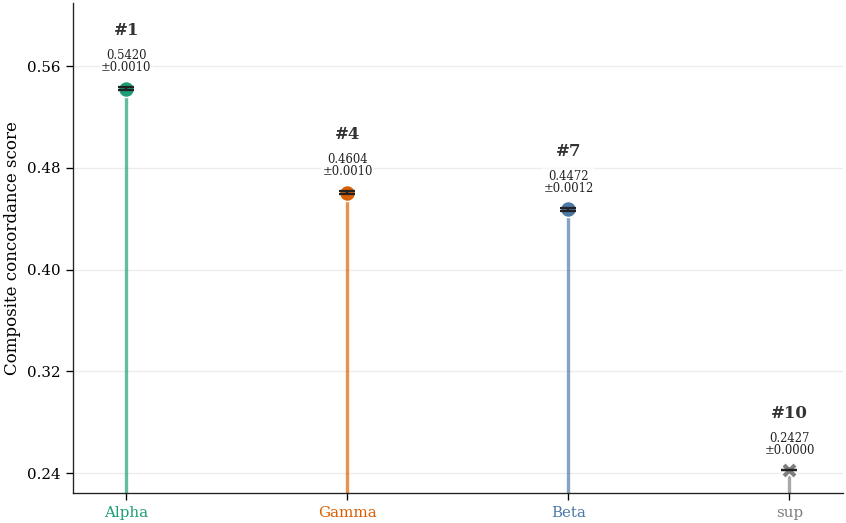

PosixPath('figures/figure_31_composite_concordance_ranking.svg')

In [23]:
# compute seeded composite AUC means and draw the main concordance ranking
plot_3_10_auc_scores = compute_plot_3_10_seeded_auc_scores(include_ground_truth=False)
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores, include_ground_truth=False)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_lollipop(ax, plot_3_10_scores)
finalize_panel(fig, "figure_31_composite_concordance_ranking")


## Figure 32. Normalised AUC components


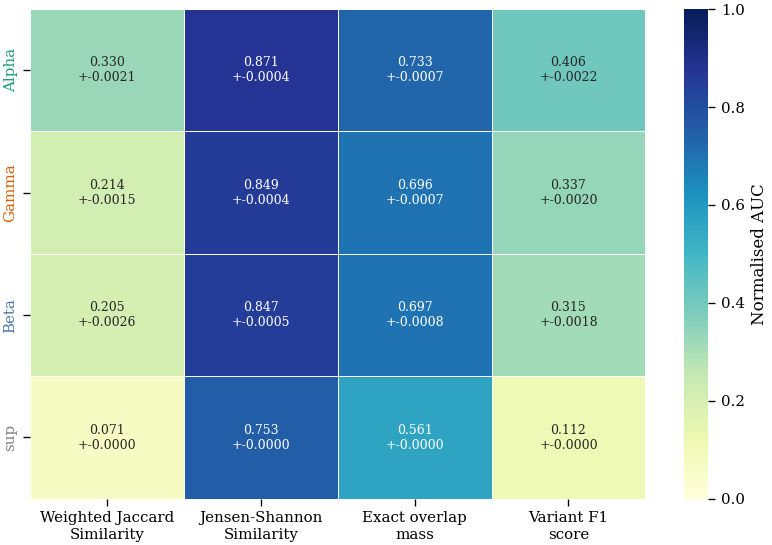

PosixPath('figures/figure_32_normalised_AUC_components.svg')

In [24]:
# turn the selected seeded AUC means into the main normalised heatmap
plot_3_10_auc_scores = compute_plot_3_10_seeded_auc_scores(include_ground_truth=False)
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores, include_ground_truth=False)
plot_3_10_heatmap_df = build_plot_3_10_heatmap_df(plot_3_10_scores)
plot_3_10_heatmap_annotation_df = build_plot_3_10_seeded_heatmap_annotation_df(plot_3_10_scores)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_heatmap(ax, plot_3_10_heatmap_df, annotation_df=plot_3_10_heatmap_annotation_df)
finalize_panel(fig, "figure_32_normalised_AUC_components")


## Figure 33. ECDF of model-assigned normalised abundance for non-WT variants retained at minimum count threshold 1. 


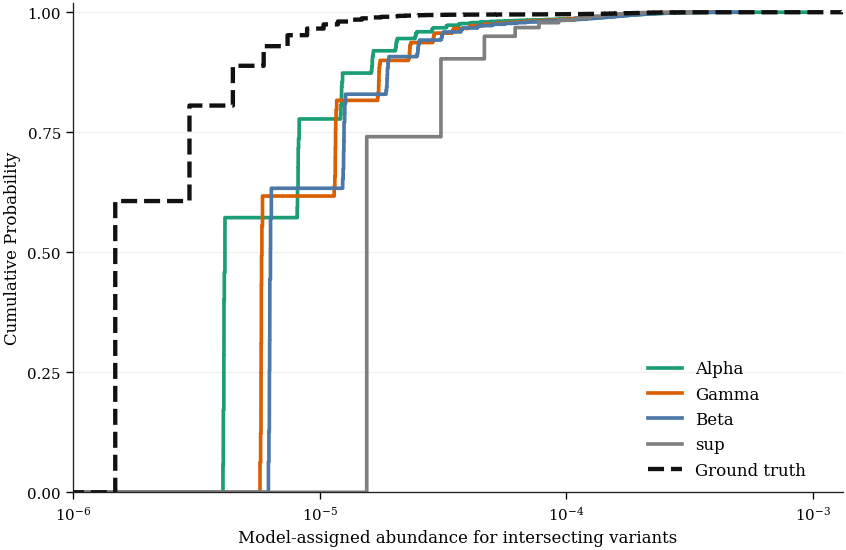

PosixPath('figures/figure_33_ECDF_model_assigned_abundance.svg')

In [25]:
# build the model-scale intersecting-variant ECDF from pooled seeded observations for the top-ranked models
plot_3_10_auc_scores = compute_plot_3_10_seeded_auc_scores()
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores)
plot_3_10_model_abundance_ecdf_df = build_plot_3_10_seeded_abundance_ecdf_df(plot_3_10_scores, abundance_source="model")
plot_3_10_model_axis_min, plot_3_10_model_axis_max, plot_3_10_model_axis_ticks = compute_plot_3_10_log_axis(
    plot_3_10_model_abundance_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_ecdf(
    ax,
    plot_3_10_scores,
    plot_3_10_model_abundance_ecdf_df,
    x_label="Model-assigned abundance for intersecting variants",
    axis_min=plot_3_10_model_axis_min,
    axis_max=plot_3_10_model_axis_max,
    axis_ticks=plot_3_10_model_axis_ticks,
    show_legend=True,
    legend_show_special_markers=False,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.85, 0.3),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "figure_33_ECDF_model_assigned_abundance")


## Figure 34. ECDF of ground-truth normalised abundance for intersecting non-WT variants retained at minimum count threshold 1. 


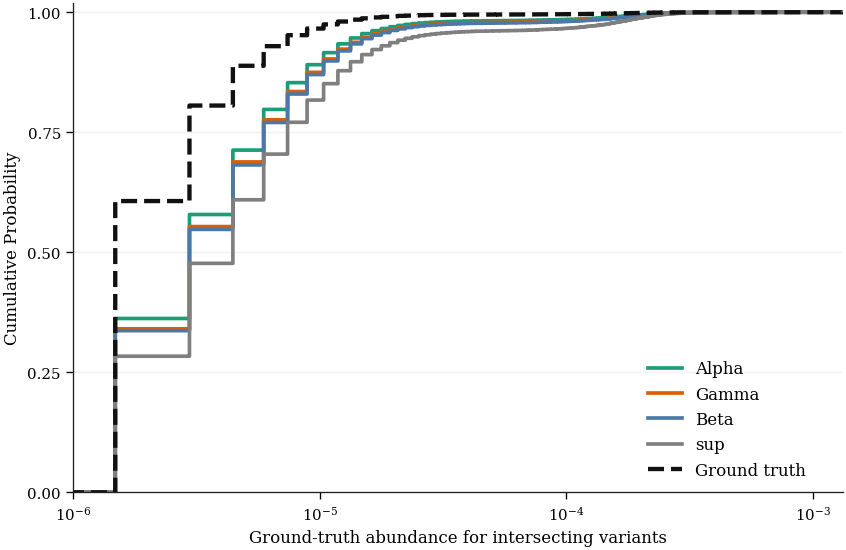

PosixPath('figures/figure_34_ECDF_ground_truth_abundance.svg')

In [26]:
# build the ground-truth-scale intersecting-variant ECDF from pooled seeded observations for the top-ranked models
plot_3_10_auc_scores = compute_plot_3_10_seeded_auc_scores()
plot_3_10_scores = select_plot_3_10_models(plot_3_10_auc_scores)
plot_3_10_truth_abundance_ecdf_df = build_plot_3_10_seeded_abundance_ecdf_df(plot_3_10_scores, abundance_source="ground_truth")
plot_3_10_truth_axis_min, plot_3_10_truth_axis_max, plot_3_10_truth_axis_ticks = compute_plot_3_10_log_axis(
    plot_3_10_truth_abundance_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 5.3))
draw_plot_3_10_ecdf(
    ax,
    plot_3_10_scores,
    plot_3_10_truth_abundance_ecdf_df,
    x_label="Ground-truth abundance for intersecting variants",
    axis_min=plot_3_10_truth_axis_min,
    axis_max=plot_3_10_truth_axis_max,
    axis_ticks=plot_3_10_truth_axis_ticks,
    show_legend=True,
    legend_show_special_markers=False,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.85, 0.3),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "figure_34_ECDF_ground_truth_abundance")


# Supplementary Figures


## Figure F1. Depth-matched DMS mutation-frequency differences across all models. 

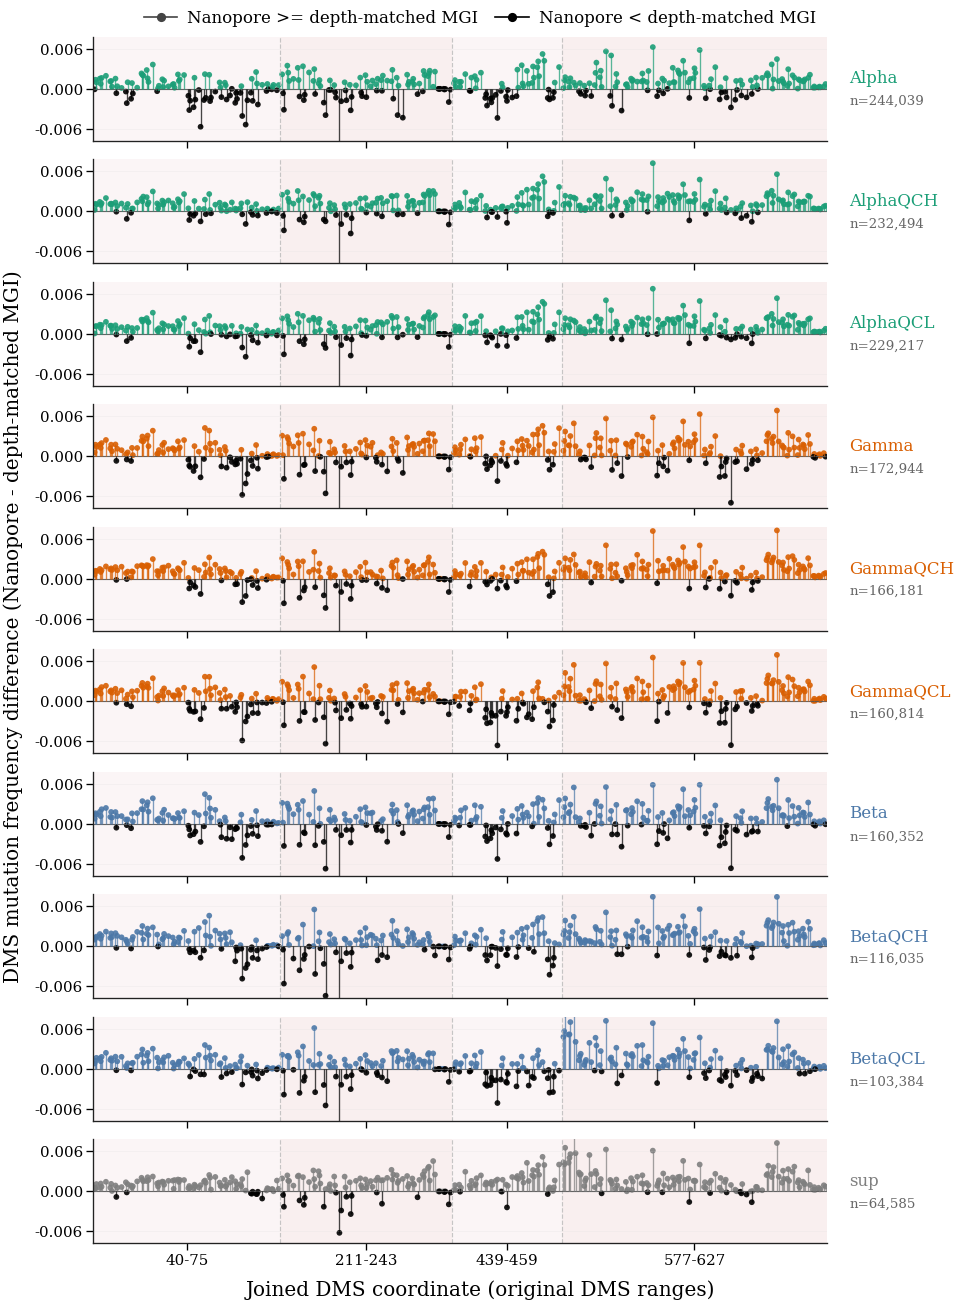

PosixPath('figures/figure_F1_depth_matched_dms_mutation_frequency.svg')

In [27]:
depth_matched_difference_models = MODEL_ONLY_ORDER
mgi_color = "#000000"
summary_lookup = summary_df.set_index("display_name")
# record the non-WT read depth used to downsample MGI for each model
depth_match_target_lookup = {
    model_name: int(load_variant_abundance(model_name, threshold=1, exclude_wt=True, normalize=False)["count"].sum())
    for model_name in depth_matched_difference_models
}
# build the depth-matched version of the DMS mutation difference table
depth_matched_difference_lookup = {
    model_name: build_depth_matched_mutation_difference_data(
        model_name,
        threshold=1,
        dms_only=True,
        exclude_wt=True,
    )
    for model_name in depth_matched_difference_models
}
# keep a shared y-limit so the rows remain comparable after downsampling
all_depth_matched_differences = pd.concat(
    [df[["abs_difference"]] for df in depth_matched_difference_lookup.values() if not df.empty],
    ignore_index=True,
)
depth_matched_difference_ymax = (
    all_depth_matched_differences["abs_difference"].quantile(0.995) * 1.08
    if not all_depth_matched_differences.empty
    else 1.0
)

fig, axes = plt.subplots(
    len(depth_matched_difference_models),
    1,
    figsize=(8.27, 11.69),
    gridspec_kw={"hspace": 0.18},
    sharex=True,
    sharey=True,
)
if len(depth_matched_difference_models) == 1:
    axes = [axes]
difference_handles = [
    Line2D([0], [0], color="#444444", marker="o", lw=1.0, ms=4.5, label="Nanopore >= depth-matched MGI"),
    Line2D([0], [0], color=mgi_color, marker="o", lw=1.0, ms=4.5, label="Nanopore < depth-matched MGI"),
]

for row_idx, model_name in enumerate(depth_matched_difference_models):
    model_row = summary_lookup.loc[model_name]
    model_color = family_color(model_row["family"])
    target_reads = depth_match_target_lookup[model_name]
    ax = axes[row_idx]
    diff_df = depth_matched_difference_lookup[model_name].copy()
    # shade the three DMS blocks and draw separators between them
    for seg_idx, segment in enumerate(JOINED_DMS_SEGMENTS):
        ax.axvspan(
            segment["joined_start"] - 0.5,
            segment["joined_end"] + 0.5,
            color=REGION_COLORS["DMS"],
            alpha=0.05 if seg_idx % 2 == 0 else 0.09,
            lw=0,
        )
        if seg_idx > 0:
            ax.axvline(segment["joined_start"] - 0.5, color="#bdbdbd", ls="--", lw=0.7, alpha=0.85)
    # the zero line shows perfect agreement with the depth-matched MGI estimate
    ax.axhline(0.0, color="#555555", lw=0.7, alpha=0.9)

    if not diff_df.empty:
        diff_df = diff_df.sort_values(["joined_position", "mutation_token"]).reset_index(drop=True)
        # spread mutation tokens slightly when multiple events share the same DMS coordinate
        diff_df["event_rank"] = diff_df.groupby("joined_position").cumcount()
        diff_df["event_count"] = diff_df.groupby("joined_position")["mutation_token"].transform("size")
        diff_df["plot_position"] = diff_df["joined_position"]
        multi_event_mask = diff_df["event_count"] > 1
        diff_df.loc[multi_event_mask, "plot_position"] = diff_df.loc[multi_event_mask, "joined_position"] + (
            (diff_df.loc[multi_event_mask, "event_rank"] / (diff_df.loc[multi_event_mask, "event_count"] - 1)) - 0.5
        ) * 0.34
        # use the model family color for positive differences and grey for negative differences
        diff_df["stem_color"] = np.where(diff_df["frequency_difference"] >= 0, model_color, mgi_color)
        for color, subset in diff_df.groupby("stem_color", sort=False):
            ax.vlines(
                subset["plot_position"],
                0.0,
                subset["frequency_difference"],
                color=color,
                lw=0.8,
                alpha=0.72,
                rasterized=True,
            )
            ax.scatter(
                subset["plot_position"],
                subset["frequency_difference"],
                color=color,
                s=12,
                alpha=0.9,
                edgecolors="none",
                rasterized=True,
            )

    ax.set_xlim(0.5, JOINED_DMS_LENGTH + 0.5)
    ax.set_ylim(-depth_matched_difference_ymax, depth_matched_difference_ymax)
    ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(3))
    ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.3f"))
    ax.grid(True, axis="y", alpha=0.18)
    ax.tick_params(axis="both", pad=2)
    ax.text(
        1.03,
        0.60,
        model_name,
        transform=ax.transAxes,
        ha="left",
        va="center",
        color=model_color,
    )
    # show the target depth used for the MGI downsampling on each row
    ax.text(
        1.03,
        0.38,
        f"n={target_reads:,}",
        transform=ax.transAxes,
        ha="left",
        va="center",
        color="#666666",
        fontsize=8,
    )
    if row_idx != len(depth_matched_difference_models) - 1:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xticks([segment["joined_mid"] for segment in JOINED_DMS_SEGMENTS])
        ax.set_xticklabels([f"{segment['start']}-{segment['end']}" for segment in JOINED_DMS_SEGMENTS])

fig.legend(
    handles=difference_handles,
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.55, 0.95),
    columnspacing=1.0,
    handletextpad=0.6,
)

fig.supylabel("DMS mutation frequency difference (Nanopore - depth-matched MGI)", x=0.07)
fig.supxlabel("Joined DMS coordinate (original DMS ranges)", x=0.55, y=0.02)
fig.subplots_adjust(top=0.92, bottom=0.06, left=0.16, right=0.90)
finalize_panel(fig, "figure_F1_depth_matched_dms_mutation_frequency")


## Figure F2. Abundance concordance for intersecting variants across all models


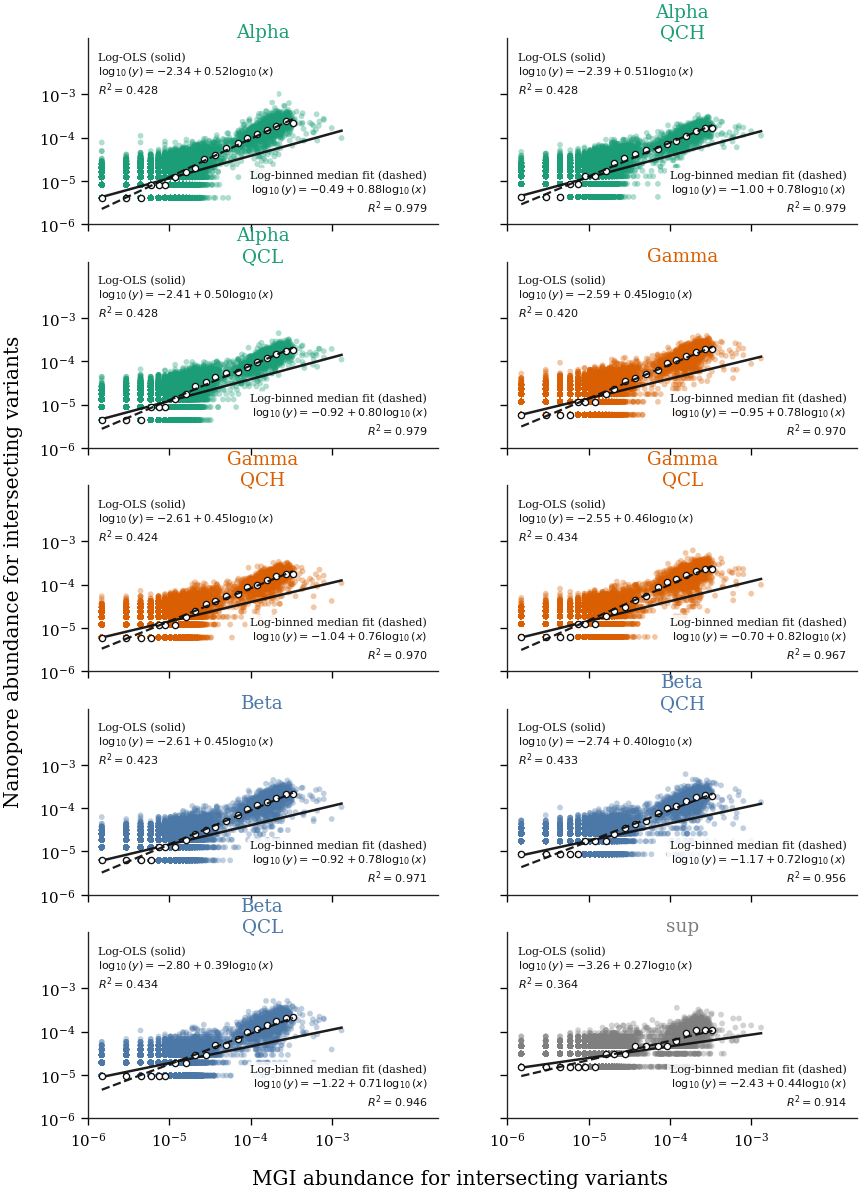

PosixPath('figures/figure_F2_abundance_concordance_all_models.svg')

In [28]:
# reuse the shared abundance table to draw all appendix scatter panels on one grid
supplementary_shared_df = build_shared_variant_scatter(MODEL_ONLY_ORDER, threshold=1, exclude_wt=True)
supplementary_lower, supplementary_upper, supplementary_ticks = compute_shared_variant_scatter_axis(supplementary_shared_df)

fig, axes = plt.subplots(5, 2, figsize=(8.27, 11.69), sharex=True, sharey=True)

for ax, model_name in zip(axes.flat, MODEL_ONLY_ORDER):
    subset = supplementary_shared_df[supplementary_shared_df["display_name"] == model_name].copy()
    draw_shared_variant_scatter_panel(
        ax,
        subset,
        model_name=model_name,
        lower=supplementary_lower,
        upper=supplementary_upper,
        ticks=supplementary_ticks,
        title=format_model_label(model_name),
        x_label="",
        y_label="",
    )

fig.supxlabel("MGI abundance for intersecting variants", y=0.06)
fig.supylabel("Nanopore abundance for intersecting variants", x=0.04)
finalize_panel(fig, "figure_F2_abundance_concordance_all_models")


## Figure F3. Composite concordance ranking for all models

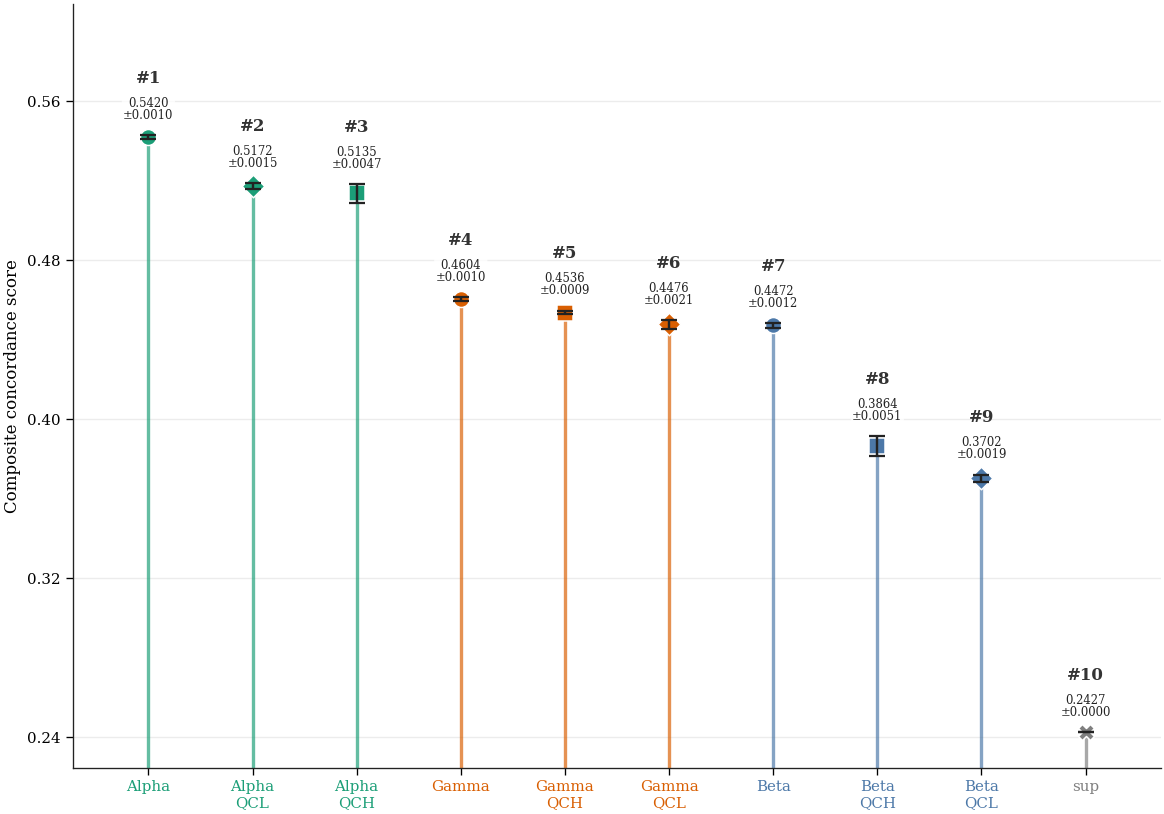

PosixPath('figures/figure_F3_composite_concordance_ranking_all_models.svg')

In [29]:
# rank all models with the all-model seeded composite AUC means
supplementary_plot_p2_auc_scores = compute_plot_3_10_seeded_auc_scores(include_ground_truth=False)
supplementary_plot_p2_scores = select_plot_3_10_all_models(supplementary_plot_p2_auc_scores, include_ground_truth=False)
fig, ax = plt.subplots(figsize=(11.69, 8.27))
draw_plot_3_10_lollipop(ax, supplementary_plot_p2_scores)
finalize_panel(fig, "figure_F3_composite_concordance_ranking_all_models")


## Figure F4. Normalised AUC component heatmap for all models

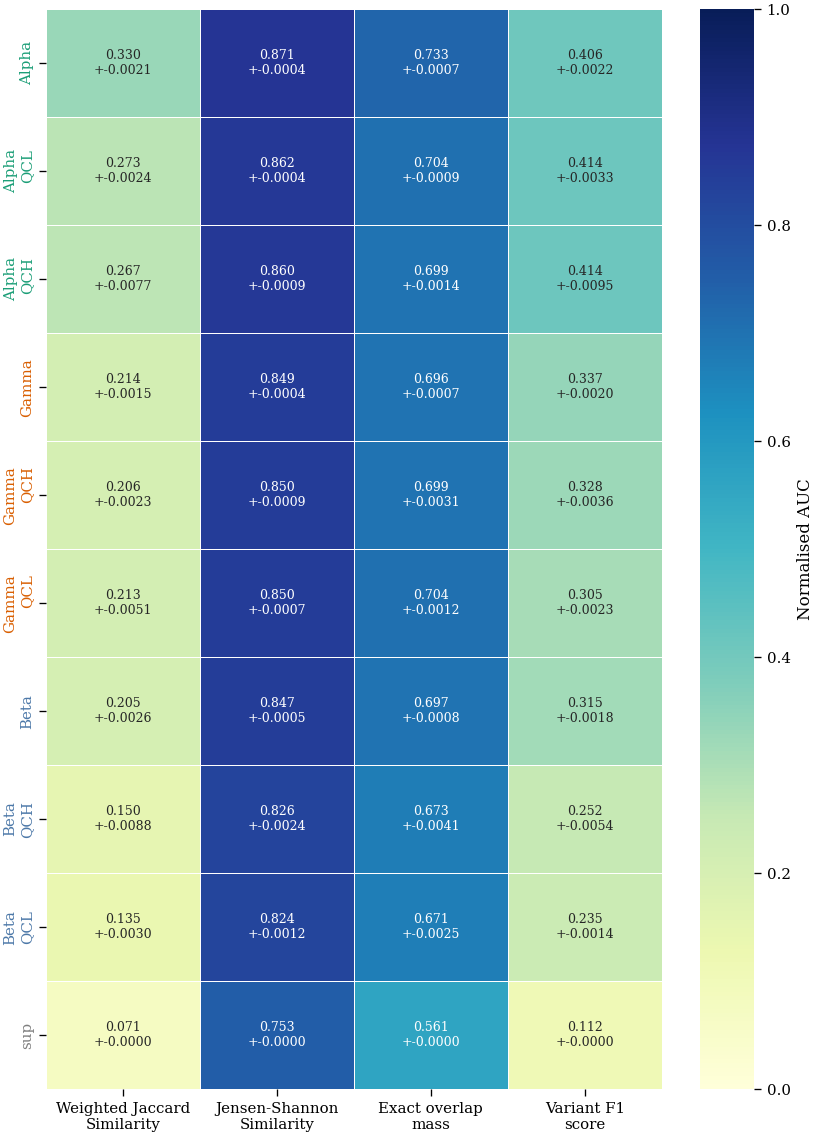

PosixPath('figures/figure_F4_normalised_AUC_components_all_models.svg')

In [30]:
# turn the all-model seeded AUC means into the appendix heatmap
supplementary_plot_p3_auc_scores = compute_plot_3_10_seeded_auc_scores(include_ground_truth=False)
supplementary_plot_p3_scores = select_plot_3_10_all_models(supplementary_plot_p3_auc_scores, include_ground_truth=False)
supplementary_plot_p3_heatmap_df = build_plot_3_10_heatmap_df(supplementary_plot_p3_scores)
supplementary_plot_p3_heatmap_annotation_df = build_plot_3_10_seeded_heatmap_annotation_df(supplementary_plot_p3_scores)

fig, ax = plt.subplots(figsize=(8.27, 11.69))
draw_plot_3_10_heatmap(ax, supplementary_plot_p3_heatmap_df, annotation_df=supplementary_plot_p3_heatmap_annotation_df)
finalize_panel(fig, "figure_F4_normalised_AUC_components_all_models")


## Figure F5. ECDF of model-assigned abundance for intersecting variants across all models

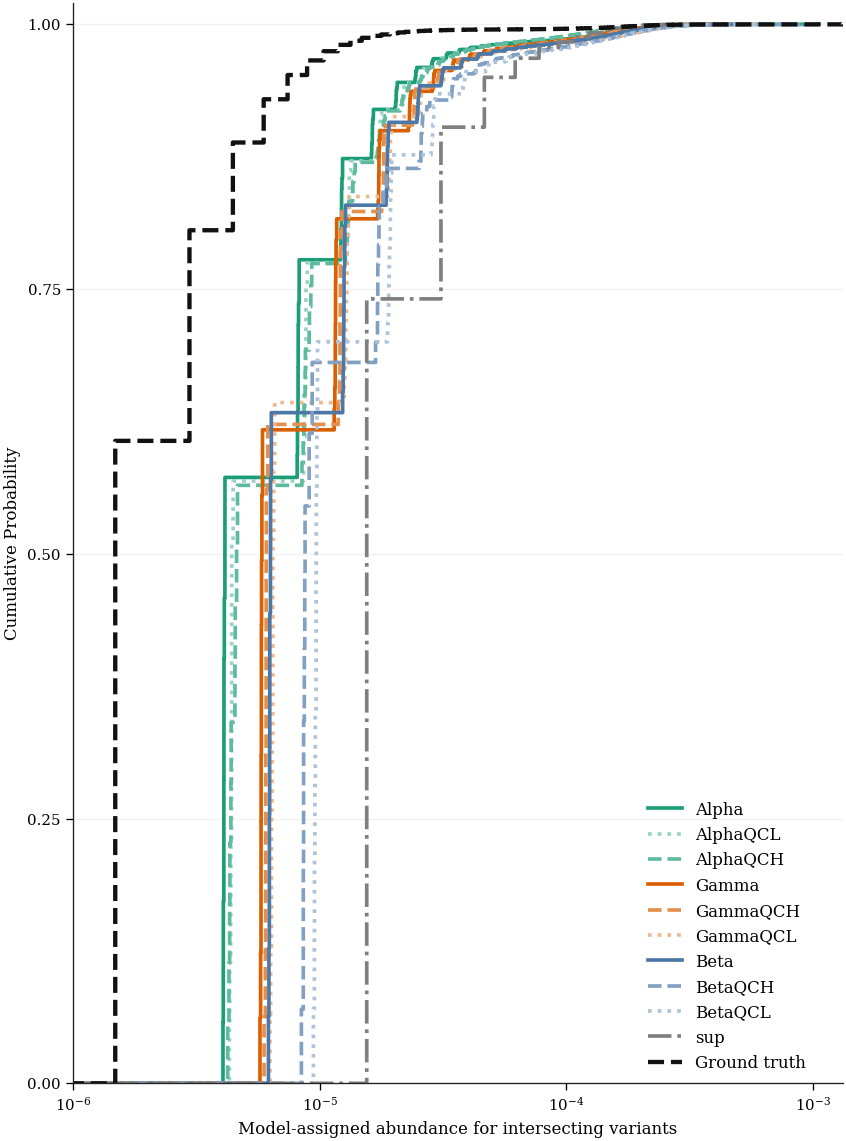

PosixPath('figures/figure_F5_ECDF_model_assigned_abundance_all_models.svg')

In [31]:
# build the all-model ECDF from pooled seeded observations on the model-assigned abundance scale
supplementary_plot_p4_scores = select_plot_3_10_all_models(compute_plot_3_10_seeded_auc_scores())
supplementary_plot_p4_ecdf_df = build_plot_3_10_seeded_abundance_ecdf_df(supplementary_plot_p4_scores, abundance_source="model")
supplementary_plot_p4_axis_min, supplementary_plot_p4_axis_max, supplementary_plot_p4_axis_ticks = compute_plot_3_10_log_axis(
    supplementary_plot_p4_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 11.69))
draw_plot_3_10_ecdf(
    ax,
    supplementary_plot_p4_scores,
    supplementary_plot_p4_ecdf_df,
    x_label="Model-assigned abundance for intersecting variants",
    axis_min=supplementary_plot_p4_axis_min,
    axis_max=supplementary_plot_p4_axis_max,
    axis_ticks=supplementary_plot_p4_axis_ticks,
    show_legend=True,
    distinguish_variants=True,
    legend_show_special_markers=False,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.85, 0.275),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "figure_F5_ECDF_model_assigned_abundance_all_models")


## Figure F6. ECDF of ground-truth abundance for intersecting variants across all models

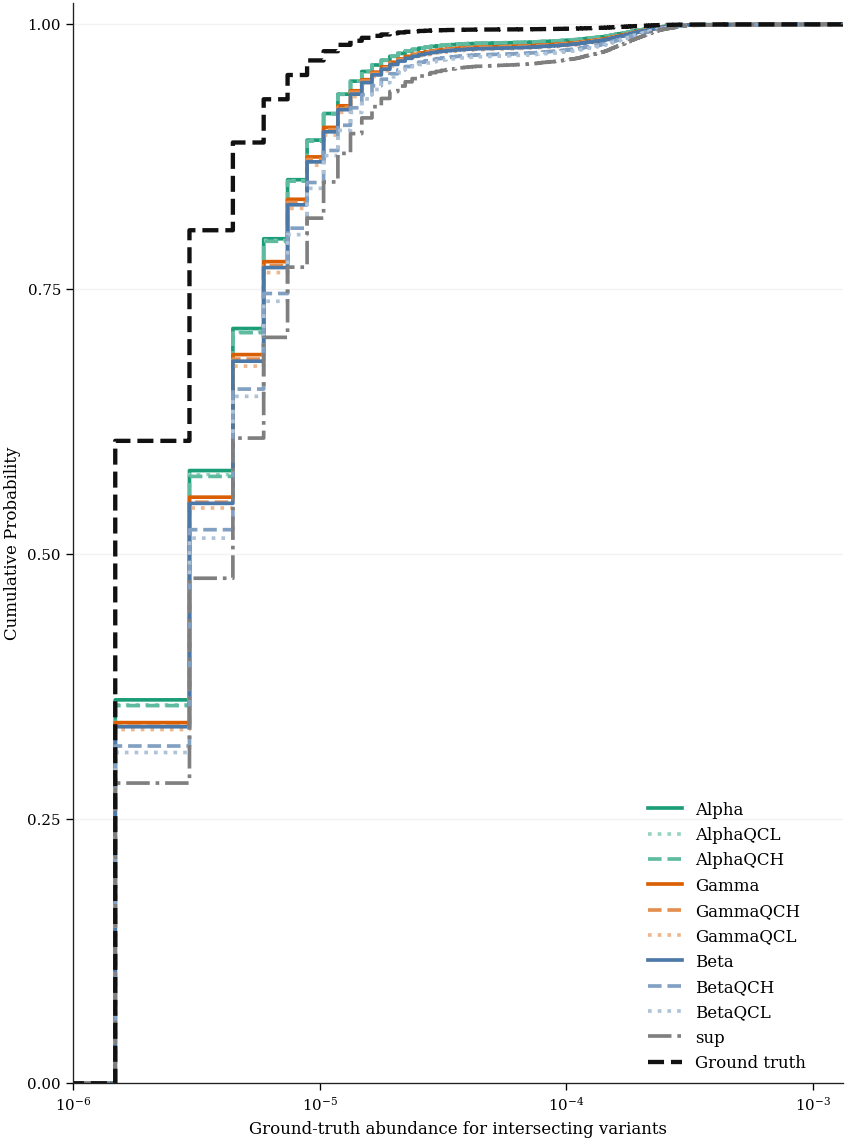

PosixPath('figures/figure_F6_ECDF_ground_truth_abundance_all_models.svg')

In [32]:
# build the all-model ECDF from pooled seeded observations on the ground-truth abundance scale
supplementary_plot_p5_scores = select_plot_3_10_all_models(compute_plot_3_10_seeded_auc_scores())
supplementary_plot_p5_ecdf_df = build_plot_3_10_seeded_abundance_ecdf_df(supplementary_plot_p5_scores, abundance_source="ground_truth")
supplementary_plot_p5_axis_min, supplementary_plot_p5_axis_max, supplementary_plot_p5_axis_ticks = compute_plot_3_10_log_axis(
    supplementary_plot_p5_ecdf_df
)

fig, ax = plt.subplots(figsize=(8.27, 11.69))
draw_plot_3_10_ecdf(
    ax,
    supplementary_plot_p5_scores,
    supplementary_plot_p5_ecdf_df,
    x_label="Ground-truth abundance for intersecting variants",
    axis_min=supplementary_plot_p5_axis_min,
    axis_max=supplementary_plot_p5_axis_max,
    axis_ticks=supplementary_plot_p5_axis_ticks,
    show_legend=True,
    distinguish_variants=True,
    legend_show_special_markers=False,
    legend_kwargs={
        "loc": "upper center",
        "bbox_to_anchor": (0.85, 0.275),
        "ncol": 1,
        "columnspacing": 1.3,
        "handlelength": 2.0,
    },
)
finalize_panel(fig, "figure_F6_ECDF_ground_truth_abundance_all_models")


# Additional Tables

## 3.1

In [33]:
table_3_1_datasets = ["A_full", "B_full", "AB_full", "2025_07_31", "UDP0057"]

# table 3.1 containing attribute for dataset before and after qc
def build_3_1_table(data_df: pd.DataFrame) -> pd.DataFrame:
    table = data_df.copy()
    table["pre_q20_fraction"] = table["pre_length_filter_q20_bases"] / table["pre_length_filter_bases"]
    table["pre_q30_fraction"] = table["pre_length_filter_q30_bases"] / table["pre_length_filter_bases"]
    table["post_q20_fraction"] = table["post_alignment_filter_q20_bases"] / table["post_alignment_filter_bases"]
    table["post_q30_fraction"] = table["post_alignment_filter_q30_bases"] / table["post_alignment_filter_bases"]
    keep = [
        "display_name",
        "pre_length_filter_reads",
        "pre_length_filter_mean_length",
        "pre_length_filter_n50_length",
        "pre_length_filter_gc_content",
        "pre_q20_fraction",
        "pre_q30_fraction",
        "post_alignment_filter_reads",
        "post_alignment_filter_mean_length",
        "post_alignment_filter_n50_length",
        "post_alignment_filter_gc_content",
        "post_q20_fraction",
        "post_q30_fraction",
        "inserted_bases",
        "deleted_bases",
        "mismatches",
        "bases_mapped",
        "error_rate",
        "overall_error_rate",
    ]
    pretty = table[keep].rename(
        columns={
            "display_name": "dataset",
            "pre_length_filter_reads": "pre_qc",
            "pre_length_filter_mean_length": "pre_mean_len",
            "pre_length_filter_n50_length": "pre_n50",
            "pre_length_filter_gc_content": "pre_gc",
            "post_alignment_filter_reads": "post_qc",
            "post_alignment_filter_mean_length": "post_mean_len",
            "post_alignment_filter_n50_length": "post_n50",
            "post_alignment_filter_gc_content": "post_gc",
            "inserted_bases": "primary_inserted_bases",
            "deleted_bases": "primary_deleted_bases",
            "mismatches": "primary_mismatches",
            "bases_mapped": "primary_bases_mapped",
            "error_rate": "primary_error_rate",
            "overall_error_rate": "primary_overall_error_rate",
        }
    )
    return pretty.sort_values("dataset").reset_index(drop=True)


table_3_1_df = build_3_1_table(data_df[data_df["display_name"].isin(table_3_1_datasets)])
export_dataframe(table_3_1_df, "3_1.csv")



Table exported to: tables/3_1.csv


## 3.2


In [34]:
# select the thesis-ready summary columns and export table 3.2
table_3_2_datasets = ["Alpha", "AlphaQCL", "AlphaQCH", "Beta", "BetaQCL", "BetaQCH", "Gamma", "GammaQCL", "GammaQCH", "sup", "UDP0057"]

def build_3_2_table(data_df: pd.DataFrame) -> pd.DataFrame:
    table = data_df.copy()
    table["pre_q20_fraction"] = table["pre_length_filter_q20_bases"] / table["pre_length_filter_bases"]
    table["pre_q30_fraction"] = table["pre_length_filter_q30_bases"] / table["pre_length_filter_bases"]
    table["post_q20_fraction"] = table["post_dms_filter_q20_bases"] / table["post_dms_filter_bases"]
    table["post_q30_fraction"] = table["post_dms_filter_q30_bases"] / table["post_dms_filter_bases"]
    keep = [
        "display_name",
        "pre_length_filter_reads",
        "pre_length_filter_mean_length",
        "pre_length_filter_n50_length",
        "pre_length_filter_gc_content",
        "pre_q20_fraction",
        "pre_q30_fraction",
        "post_alignment_filter_reads",
        "post_alignment_filter_mean_length",
        "post_alignment_filter_n50_length",
        "post_alignment_filter_gc_content",
        "post_q20_fraction",
        "post_q30_fraction",
        "primary_inserted_bases",
        "primary_deleted_bases",
        "primary_mismatches",
        "primary_bases_mapped",
        "primary_error_rate",
        "primary_overall_error_rate",
    ]
    pretty = table[keep].rename(
        columns={
            "display_name": "dataset",
            "pre_length_filter_reads": "pre_qc",
            "pre_length_filter_mean_length": "pre_mean_len",
            "pre_length_filter_n50_length": "pre_n50",
            "pre_length_filter_gc_content": "pre_gc",
            "post_alignment_filter_reads": "post_qc",
            "post_alignment_filter_mean_length": "post_mean_len",
            "post_alignment_filter_n50_length": "post_n50",
            "post_alignment_filter_gc_content": "post_gc",
        }
    )
    return pretty.sort_values("dataset").reset_index(drop=True)


table_3_2_df = build_3_2_table(summary_df[summary_df["display_name"].isin(table_3_2_datasets)])
export_dataframe(table_3_2_df, "3_2.csv")



Table exported to: tables/3_2.csv


## 3.3


In [35]:
# assemble the DMS-filter and polishing summary columns for table 3.3
table_3_3_datasets = ["Alpha", "AlphaQCL", "AlphaQCH", "Beta", "BetaQCL", "BetaQCH", "Gamma", "GammaQCL", "GammaQCH", "sup", "UDP0057"]

def build_3_3_table(data_df: pd.DataFrame) -> pd.DataFrame:
    table = data_df.copy()
    keep = [
        "display_name",
        "post_dms_filter_reads",
        "failed_indel",
        "failed_coverage",
        "failed_dual_site",
        "failed_mut_codon_library",
        "pass_reads_0_codon_mutations",
        "pass_reads_1_codon_mutations",
        "pass_reads_2_codon_mutations",
        "pass_rate",
        "unique_variants",
        "avg_dms_nucleotide_mismatches_per_read",
        "avg_framework_nucleotide_mismatches_per_read",
        "avg_net_nucleotide_mismatches_per_read",
        "avg_dms_codon_mismatches_per_read",
        "avg_framework_codon_mismatches_per_read",
        "avg_net_codon_mismatches_per_read",
        "dms_bases_compared",
        "framework_bases_compared",
        "dms_codons_compared",
        "framework_codons_compared",
        "dms_nt_mismatch_rate_per_base",
        "framework_nt_mismatch_rate_per_base",
        "net_nt_mismatch_rate_per_base",
        "dms_codon_mismatch_rate_per_codon",
        "framework_codon_mismatch_rate_per_codon",
        "net_codon_mismatch_rate_per_codon",
        "polished_mismatches",
        "polished_bases_mapped",
        "polished_error_rate",
        "polished_overall_error_rate",
        "pipeline_pass_rate",
    ]
    pretty = table[keep].rename(
        columns={
            "display_name": "dataset",
            "post_dms_filter_reads": "passed reads",
        }
    )
    return pretty.sort_values("dataset").reset_index(drop=True)

table_3_3_df = build_3_3_table(summary_df[summary_df["display_name"].isin(table_3_3_datasets)])
export_dataframe(table_3_3_df, "3_3.csv")



Table exported to: tables/3_3.csv


## 3.4

In [36]:
# summarise per-model DMS mutation-difference statistics for table 3.4
def build_3_4_table(summary_df: pd.DataFrame, threshold: int = 1, exclude_wt: bool = True) -> pd.DataFrame:
    rows = []
    model_rows = summary_df[summary_df["display_name"].isin(MODEL_ONLY_ORDER)].copy().sort_values("sort_order")
    for _, row in model_rows.iterrows():
        diff_df = build_shared_mutation_difference_data(
            row["display_name"],
            threshold=threshold,
            dms_only=True,
            exclude_wt=exclude_wt,
        ).copy()
        rows.append(
            {
                "display_name": row["display_name"],
                "family": row["family"],
                "variant": row["variant"],
                "dms_mutation_events": int(len(diff_df)),
                "mean_abs_difference": float(diff_df["abs_difference"].mean()),
                "median_abs_difference": float(diff_df["abs_difference"].median()),
                "p95_abs_difference": float(diff_df["abs_difference"].quantile(0.95)),
                "mean_signed_difference": float(diff_df["frequency_difference"].mean()),
                "positive_event_count": int((diff_df["frequency_difference"] >= 0).sum()),
                "negative_event_count": int((diff_df["frequency_difference"] < 0).sum()),
                "within_0p001_share": float((diff_df["abs_difference"] <= 0.001).mean()),
                "within_0p002_share": float((diff_df["abs_difference"] <= 0.002).mean()),
            }
        )
    return pd.DataFrame.from_records(rows).sort_values("display_name").reset_index(drop=True)


table_3_4_df = build_3_4_table(summary_df)
export_dataframe(table_3_4_df, "3_4.csv")



Table exported to: tables/3_4.csv


## 3.5

In [37]:
# count shared, false-negative, and false-positive DMS mutation events for table 3.5
def build_3_5_table(summary_df: pd.DataFrame, threshold: int = 1, exclude_wt: bool = True) -> pd.DataFrame:
    rows = []
    model_rows = summary_df[summary_df["display_name"].isin(MODEL_ONLY_ORDER)].copy().sort_values("sort_order")
    for _, row in model_rows.iterrows():
        event_df = build_mutation_event_count_data(row["display_name"], threshold=threshold, exclude_wt=exclude_wt).copy()
        event_df = event_df[event_df["position"].map(position_region) == "DMS"].copy()
        nanopore_events = {
            (int(position), mutation_token)
            for position, mutation_token in event_df.loc[event_df["dataset"] == "Nanopore", ["position", "mutation_token"]].itertuples(index=False, name=None)
        }
        mgi_events = {
            (int(position), mutation_token)
            for position, mutation_token in event_df.loc[event_df["dataset"] == "MGI", ["position", "mutation_token"]].itertuples(index=False, name=None)
        }
        rows.append(
            {
                "display_name": row["display_name"],
                "family": row["family"],
                "variant": row["variant"],
                "shared_dms_mutation_events": len(nanopore_events & mgi_events),
                "false_negative_dms_mutation_events": len(mgi_events - nanopore_events),
                "false_positive_dms_mutation_events": len(nanopore_events - mgi_events),
            }
        )
    return pd.DataFrame.from_records(rows)


table_3_5_df = build_3_5_table(summary_df)
export_dataframe(table_3_5_df, "3_5.csv")



Table exported to: tables/3_5.csv
